# Построение модели поведенческого скоринга клиента банка прогнозирующей просрочку платежа по кредиту на 3 месяца и более

- Автор: Федоров Алексей Анатольевич
- Дата: 17.08.2026

<a id='цели-и-задачи-проекта'></a>
## Цели и задачи проекта

Крупный розничный банк "Ва-банк" занимается кредитованием физических лиц. Перед одобрением кредита банк оценивает платёжеспособность и платёжную дисциплину клиента. Однако, когда кредиов в банке открыто много, ежемесячно требуется проверять и обновлять поведенческий скоринг клиентов с открытыми кредитами, чтобы точнее оценивать вероятности дефолтов клиентов в течении года от месяца оценки. Хорошая по точности оценка числа возможных дефолтов позволяет оптимизировать использование денежных средств банка исключив создание избыточного резерва на случай дефолта клиента. Слишком большой резевр средств на покрытие риска дефолта заёмщиков выводит эти средства из оборота и они перестают работать и приносить банку прибыль. Поэтому, размер резерва нужно минимизировать, чтобы освободить 5 - 10% средств и пустить их в оборот.

Для банка важно:
- выполнять требования Центробанка по резервированию 100% объёма проблемных кредитов на покрытие риска невозврата;
- исключить банкроство банка при массовом невозврате кредитов;
- высовобождать 5 - 10% средств за счёт более точного прогнозирования числа дефолтов заёмщиков на 1 год вперёд, что позволяет сократить резерв.

1. **Тип задачи** - бинарная классификация, обучение с учителем (на размеченных данных).


2. **Задача** - на основе данных о кредите, покупках, других кредитах и ипотеке, анкетных данных, кредитного рейтинга, макроэкономических показателях предсказывать 3-х месячную и более просрочку платежа с горизонтом прогноза 1 год.


3. **Цель** - знать более точную оценку вероятных дефолтов заёмщиков с горизонтом в 1 год, чтобы минимизировать размер резерва финансовых средств под обеспечение рисков по проблемным кредитам.


4. **Целевая переменная** - **`loan_default`**: наличие просрочки от 90 дней в течении последующих 365-ти дней с даты поведенческого скоринга. 0 - нет просрочки, 1 - есть просрочка.


6. **Бизнес-метрики**
$$\text{Approval rate} = \frac{\text{FN} + \text{TN}}{\text{N}}$$

FN — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0), но у них случился дефолт.

TN — количество клиентов, которых модель посчитала надёжными (присвоила им класс 0) и у которых дефолта не случилось.

N — размер всей выборки заявок или текущих заёмщиков.

Эта метрика оценивает, скольким клиентам будет присвоен класс 0 при оценке риска просрочки.


$$\text{Default rate} = \frac{\text{FN}}{\text{FN} + \text{TN}}$$

Метрика показывает, какая часть клиентов среди тех, кого модель посчитала надёжными, в итоге всё‑таки не заплатила по своим обязательствам.

$$\text{Missed defaults rate} = \frac{\text{FN}}{\text{FN} + \text{TP}}$$

Missed defaults rate можно выразить как 1 − Recall.

Метрика показывает, какую долю от всех проблемных клиентов модель не заметила — то есть посчитала этих клиентов надёжными и пропустила дальше, хотя они в итоге не заплатили.


7. **Модель** - как основные модели предпологаются LogisticRegression и RandomForest. Должен учитываться дизбаланс классов. И учитываться наличие временного ряда, чтобы не возникало утечки данных из будущего и модель учитывала только данные из прошлого относительно даты проведения кадого поведенческого скоринга.

8. **Основная метрика данных**: **BR** (base rate) - доля положительного класса. Фиксируется в начале и проверяется после обучения и подбора порога.

9. **Метрики качества модели**
При обучении и отборе модели используем **ранжирующие** метрики, при калибровке - **пороговые**. Пороговые плохо подходят для отбора лучшей модели, так как радикально меняют результат в зависимости от порога.

**Сравнение моделей:**
- **основная метрика:** ROC-AUC на CV(3) внутри Train — ранжирующая, не зависит от порога, показывает объясняющую способность.

Схема кросс-валидации — out-of-time, TimeSeriesSplit по когортам score_date:
- группа — когорта score_date, не ID;
- окно обучения расширяющееся (13 → 17 → 21 когорта);
- валидационный блок — 4 когорты, блоки не перекрываются.


- **вспомогательные:** 
 - **PR_AUC** - первая при большом дизбалансе классов TARGET хорошо ранжирует модели в дополнение к оптимистичной ROC_AUC;
 - Accuracy мало полезна при дизбалансе. Отвергаем;
 - **std ROC_AUC** по фолдам CV, чтобы проверить статистическую значимость разницы ROC_AUC у моделей в разрезе стабильности. При этом, желательно число фолдов 5-10.

**Подбор гиперпараметров:**
- **основная**: **MDR** (missed defaults rate) - надо минимизировать. Однако, метрика пороговая, поэтому, внутри оптимизации надо каждый раз использовать predict_proba на Validation Set и подбирать порог Approval rate = 65%. Вычислять MDR при пороге.

- **вспомогательные:** **AR** (appruval rate) и **DR** (default rate) - логировать в user_attr, чтобы показать, что требования к метрикам соблюдены. 

**Калибровка вероятностей лучшей модели:**
- **основная**: **Brier score** и **ECE** (expected calibration error) и проверка Calibration curve. Подбираем DR <=2%;

- **вспомогательные:** **ROC_AUC** - надо проверить, чтобы сильно не упал после калибровки. Иначе упадёт объясняющая способность модели.

**Подбор порога:**
- **основная**: **AR, DR, MDR** как ограничения. Максимизировать AR при DR <= 2% и MDR <= 4%.

**Финальная оценка лушей модели**:
- **основная**: **AR, DR, MDR** с порогом пересчитываем на Test Set. Отклонение 10 - 15%;

- **вспомогательные**: 
    - **матрица ошибок**;
    - **ROC_AUC** и **PR_AUC** на тесте (если DR скакнул, а AUC хороший, то нужна перекалибровка);
    - **BR** - проверить долю положительного класса.
    

10. **Требования к модели**:
- AR >= 65%;
- DR < 2%;
- MDR <= 4%.

<a id='описание-данных'></a>
## Описание данных

### Таблица 1. Данные о просрочке платежа

Содержит столбцы:

- **ID** — идентификатор клиента.
- **дата_начала_периода** — дата начала периода просрочки.
- **просрочка_дней** — длительность просрочки в днях.

Скачать данные: [ds_15_loan_payment_credit.csv](https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv)

---

### Таблица 2. Месячные транзакции клиента

Таблица содержит информацию о тратах клиента по MCC-кодам.

- **ID** — идентификатор клиента.
- **date** — календарная дата по месяцам.
- **MCC_5300** — помесячные траты клиента по коду 5300.
- **MCC_5814** — помесячные траты клиента по коду 5814.
- **MCC_5812** — помесячные траты клиента по коду 5812.
- **MCC_5411** — помесячные траты клиента по коду 5411.
- **MCC_3990** — помесячные траты клиента по коду 3990.
- **MCC_5722** — помесячные траты клиента по коду 5722.
- **MCC_4900** — помесячные траты клиента по коду 4900.
- **MCC_другое** — помесячные траты клиента по остальным кодам.

Скачать данные: [ds_15_transactions.csv](https://code.s3.yandex.net/datasets/ds_15_transactions.csv)

| MCC-код | Категория | Расшифровка и примеры |
|---------|-----------|----------------------|
| 5300 | Оптовики | Маркетплейсы: Ozon, Lamoda, Wildberries и другие. |
| 5814 | Фастфуд | Рестораны быстрого питания: «Вкусно — и точка», «Бургер Кинг» и другие. |
| 5812 | Места общественного питания, рестораны | Столовые и кафе: «Якитория», «Хлеб Насущный» и другие. |
| 5411 | Бакалейные магазины, супермаркеты | Большинство продуктовых магазинов: «Пятёрочка», «Магнит» и другие. |
| 3990 | Экосистема Яндекса | Яндекс Афиша, Яндекс Такси, Яндекс Книги и другие сервисы. |
| 5722 | Бытовое оборудование | Магазины, продающие технику для дома: «М.Видео», «Ситилинк» и другие. |
| 4900 | Жилищно-коммунальные услуги | Точки, оказывающие услуги по передаче или распределению электроэнергии, газа, установке и обслуживанию систем водоснабжения, сбору и утилизации отходов. |
| MCC_другое | Остальные категории | — |

---

### Таблица 3. Описание клиента на момент регистрации в банке

Содержит столбцы:

- **ID** — идентификатор клиента.
- **возраст** — возраст клиента.
- **семейное_положение** — семейное положение клиента. Три состояния: разведённые, есть семья, нет семьи.
- **наличие_иждивенцев** — есть ли у клиента лица на финансовом попечении: 1 — да, 0 — нет.
- **дата_регистрации** — календарная дата начала взаимоотношений банка и клиента.

Скачать данные: [ds_15_client_description.csv](https://code.s3.yandex.net/datasets/ds_15_client_description.csv)

---

### Таблица 4. Описание кредита

Содержит столбцы:

- **ID** — идентификатор клиента.
- **доход** — месячный доход клиента на момент взятия кредита в рублях.
- **сумма_кредита** — сумма кредита, выданного клиенту, в рублях.

Скачать данные: [ds_15_credit_description.csv](https://code.s3.yandex.net/datasets/ds_15_credit_description.csv)

---

### Таблица 5. Данные о наличии ипотеки

Содержит столбцы:

- **ID** — идентификатор клиента.
- **дата_открытия** — календарная дата, когда клиент оформил ипотеку.
- **наличие_ипотеки** — есть ли у клиента ипотека: 1 — да, 0 — нет.

Скачать данные: [ds_15_mortgage_presence.csv](https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv)

---

### Таблица 6. Данные о кредитном рейтинге клиента

Содержит столбцы:

- **ID** — идентификатор клиента.
- **date** — календарная дата получения рейтинга из внешнего источника.
- **кредитный_рейтинг** — значение рейтинга клиента на конкретную дату.

Скачать данные: [ds_15_credit_rating.csv](https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv)

---

### Таблица 7. Данные о макроэкономических показателях России

Содержит столбцы:

- **date** — месяц и год, на которые актуальны указанные показатели.
- **учетная_ставка** — учётная ставка в процентах.
- **уровень_безработицы** — уровень безработицы в процентах.
- **инфляция** — инфляция в процентах.

Скачать данные: [ds_15_macro_data.csv](https://code.s3.yandex.net/datasets/ds_15_macro_data.csv)

---

### Таблица 8. Данные о дате проведения поведенческого скоринга

Содержит столбцы:

- **ID** — идентификатор клиента.
- **score_date** — дата скоринга.

Скачать данные: [ds_15_cohort_grid.csv](https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv)

<a id='подготовка-среды-и-библиотек'></a>
## Подготовка среды и библиотек
### Зависимости
Самый правильный и 100% надёжный безпроблемный вариант - использовать venv + kernel. Это даёт полную изоляцию окружения для тетради, кроме того, собственную изолированную версию Python для venv, которую умеет ставить Conda:
```
conda create -y -n "${ENV_NAME}" python="${PYTHON_VERSION}"
```
Однако, ревьюверы почему-то не любят переключать ядра Jupyter, поэтому, будем использовать установку библиотек в домашнюю папку под Python 3.9. При этом не исключены конфликты версий.

#### **1.** Обновляем pip, чтобы работал --dry-run.

In [1]:
%pip install --upgrade --user --disable-pip-version-check -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple pip

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


In [2]:
# .local/lib/python3.9/site-packages должен стоять до глобального окружения
import sys
for p in sys.path:
    print(p)

/home/jovyan/work
/opt/conda/lib/python39.zip
/opt/conda/lib/python3.9
/opt/conda/lib/python3.9/lib-dynload

/home/jovyan/.local/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages/IPython/extensions
/home/jovyan/.ipython


In [3]:
%pip -V

pip 26.0.1 from /home/jovyan/.local/lib/python3.9/site-packages/pip (python 3.9)
Note: you may need to restart the kernel to use updated packages.


#### **2.** Проверяем наличие scikit-learn нужной версии через --dry-run.

In [4]:
%pip install --dry-run --only-binary=:all: --disable-pip-version-check scikit-learn==1.5.2 \
        -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
Note: you may need to restart the kernel to use updated packages.


Тут ставим зависимости. --user - ставит в домашнюю папку пользователя /home/xxx_user_name/.local/lib, а не в /opt/conda/lib. В sys.path прописана сначала папка пользователя, поэтому модули возьмутся оттуда.

--only-binary - не используется компиляция, а только Wheels - готовые бинарники.

In [5]:
%pip install --user --only-binary=:all: --disable-pip-version-check --no-warn-script-location \
    numpy==1.26.4 \
    scipy==1.13.1 \
    pandas==2.1.4 \
    scikit-learn==1.5.2 \
    imbalanced-learn==0.12.4 \
    matplotlib==3.8.2 \
    seaborn==0.13.0 \
    statsmodels==0.14.1 \
    phik==0.12.5 \
    jinja2==3.1.4 \
    numba==0.58.1 \
    llvmlite==0.41.1 \
    patsy==0.5.6 \
    joblib==1.4.2 \
    threadpoolctl==3.5.0 \
    optuna==3.6.1 \
    dill==0.3.8 \
    packaging==24.2 \
    mlxtend==0.23.1 \
    ipywidgets==8.1.5 \
    -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


#### Проверяем, что встало

In [6]:
# Тест на ложную тревогу в логе pip по ipykernel 
import importlib.util, sys
spec = importlib.util.find_spec("ipykernel")
print("ipykernel найден:", spec is not None)
if spec:
    print("путь:", spec.origin)
import ipykernel
print("версия:", ipykernel.__version__)

ipykernel найден: True
путь: /opt/conda/lib/python3.9/site-packages/ipykernel/__init__.py
версия: 6.0.1


In [7]:
import sys, os
print(sys.version, '\n')
print(f"python      : {sys.version.split()[0]}\n")

import numpy, scipy, pandas, sklearn, imblearn, optuna, dill, phik, numba, matplotlib, seaborn, statsmodels

for m in (numpy, scipy, pandas, sklearn, imblearn, optuna, dill, phik, numba, matplotlib, seaborn, statsmodels):
    print(f"{m.__name__:18s} {m.__version__:12s} <- {m.__file__.split('site-packages')[0]}site-packages")

3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0] 

python      : 3.9.5

numpy              1.26.4       <- /home/jovyan/.local/lib/python3.9/site-packages
scipy              1.13.1       <- /home/jovyan/.local/lib/python3.9/site-packages
pandas             2.1.4        <- /home/jovyan/.local/lib/python3.9/site-packages
sklearn            1.5.2        <- /home/jovyan/.local/lib/python3.9/site-packages
imblearn           0.12.4       <- /home/jovyan/.local/lib/python3.9/site-packages
optuna             3.6.1        <- /home/jovyan/.local/lib/python3.9/site-packages
dill               0.3.8        <- /home/jovyan/.local/lib/python3.9/site-packages
phik               0.12.5       <- /home/jovyan/.local/lib/python3.9/site-packages
numba              0.58.1       <- /home/jovyan/.local/lib/python3.9/site-packages
matplotlib         3.8.2        <- /home/jovyan/.local/lib/python3.9/site-packages
seaborn            0.13.0       <- /home/jovyan/.local/lib/python3.

👉 Если тут ошибка, то **Нужен Restart Kernel !!!**

#### **4.** Удаление (очистка) установленных модулей.
Этот код нужно раскомментить и выполнить после проверки работы или в случае проблем с установкой, если был непустой `/home/xxx_user_name/.local/lib/python3.9/site-packages/`

In [8]:
"""
import site, shutil, os, sys

user_site = site.getusersitepackages()
print("USER_SITE:", user_site)
print("Существует:", os.path.isdir(user_site))

if os.path.isdir(user_site):
    print("Содержимое (первые 40):")
    for name in sorted(os.listdir(user_site))[:40]:
        print("  ", name)
""";

In [9]:
"""
shutil.rmtree(user_site, ignore_errors=True)
print("Удалено. Перезапустите ядро: Kernel → Restart Kernel")
""";

### Импорты библиотек

In [10]:
# ============================== Standard ==============================
import contextlib
import gc
import inspect
import os
import sys
import time
import warnings
from dataclasses import dataclass, field, fields
from datetime import datetime
from functools import reduce
from itertools import combinations
from pprint import pprint
from typing import Callable, Iterable, Protocol, Sequence, Optional

# ============================== Third-party ==================================
import dill
import joblib
import numpy as np
import pandas as pd
from joblib import Memory

from scipy.stats import normaltest, chi2_contingency

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from IPython.display import HTML, Markdown, display, display_html

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from tqdm.notebook import tqdm

# ============================== scikit-learn =================================
import sklearn
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    # ранжирующие — основные при сравнении моделей
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    # пороговые — для бизнес-метрик и матрицы ошибок
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    # калибровка
    brier_score_loss,
    log_loss,
    # обёртка для custom-скореров в cross_validate
    make_scorer,
)

from sklearn.model_selection import (
    cross_validate,
    cross_val_predict,
    train_test_split,
    StratifiedKFold,
    TimeSeriesSplit,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    KBinsDiscretizer,
)

# ============================== imbalanced-learn =============================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# ============================== mlxtend =============================
from mlxtend.evaluate import GroupTimeSeriesSplit as MlxGroupTimeSeriesSplit

<a id='общие-функции'></a>
### Общие функции
<a id='базовые'></a>
#### Базовые

In [11]:
def to_snake_case_columns(dataframe: pd.DataFrame) -> None:
    """Приводит названия колонок к snake_case прямо в исходном датафрейме."""
    dataframe.columns = (
        dataframe.columns
        .str.replace(r'[\s/()\-%,.]+', '_', regex=True)  # Замена спецсимволов и пробелов на _
        .str.replace(r'^_+|_+$', '', regex=True)         # Удаление подчеркиваний на концах
        .str.lower()                                     # Перевод в нижний регистр
    )
    
    
def get_integer_features_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Находит признаки, содержащие только целые числа (игнорируя NaN/пропуски),
    и возвращает DataFrame с их именами и кардинальностью.
    """
    integer_features = []
    cardinalities = []
    
    for col in dataframe.columns:
        # Удаляем пропуски для корректной проверки значений
        clean_col = dataframe[col].dropna()
        
        # Если колонка стала пустой после удаления NaN, пропускаем её
        if clean_col.empty:
            continue
            
        # Проверяем, является ли колонка числовой
        if pd.api.types.is_numeric_dtype(clean_col):
            # Проверяем, что все значения являются целыми (остаток от деления на 1 равен 0)
            if (clean_col % 1 == 0).all():
                integer_features.append(col)
                cardinalities.append(clean_col.nunique())
        else:
            # Если тип object/string, пробуем привести к числу
            try:
                converted = pd.to_numeric(clean_col)
                if (converted % 1 == 0).all():
                    integer_features.append(col)
                    cardinalities.append(converted.nunique())
            except (ValueError, TypeError):
                continue
                
    # Формируем итоговый DataFrame
    result_df = pd.DataFrame({
        'feature_name': integer_features,
        'cardinality': cardinalities
    })
    
    return result_df
    
def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = (
        set(ints) if ints is not None
        else set(data_frame.select_dtypes(include="integer").columns)
    )
        
    floats_actual = (
        set(floats) if floats is not None
        else set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual    
    
    cats_actual = (
        set(cats) if cats is not None
        else set(data_frame.select_dtypes(include=["object", "string"]).columns)
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame

<a id='базовый-eda'></a>
#### Базовый EDA

In [12]:
def get_missings(df, hide_zeros = False):
    missing_df = df.isna().sum().to_frame(name='missing_count')
    missing_df['missing_percent'] = (df.isna().mean() * 100).round(2)
    if hide_zeros:
        missing_df = missing_df.query('missing_percent > 0')
    
    return missing_df.sort_values(by='missing_percent', ascending=False)

def get_missing_rows_info(dataframe: pd.DataFrame) -> dict:
    """Возвращает количество и процент строк, содержащих хотя бы один пропуск."""
    missing_mask = dataframe.isna().any(axis=1)
    
    total_missing = missing_mask.sum()
    percent_missing = (missing_mask.mean() * 100).round(2)
    
    return {
        'missing_rows_count': total_missing,
        'missing_rows_percent': percent_missing
    }
            
def get_whiskers(values, coeff=1.5, left=None, right=None):
    """
        Возвращает усы ящика для серии values.
    """
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    w_left = Q1 - coeff * IQR
    w_right = Q3 + coeff * IQR
    
    if left is not None:
        w_left = max(left, w_left)
    if right is not None:
        w_right = min(right, w_right)
        
    return w_left, w_right            
            
def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def get_quasi_consts_numeric(df, names, threshold=0.1):
    vs_quasi = VarianceThreshold(threshold=threshold)     
    numerical_data = df[list(names)]
    vs_quasi.fit(numerical_data)
    return [col for col, keep in zip(names, vs_quasi.get_support()) if not keep]

def get_quasi_consts_categories(df, names):
    return [col for col in list(names)
                      if df[col].value_counts(normalize=True).iloc[0] > 0.90]

def drop_columns_inplace_safe(df, cols):
    existing_cols = df.columns.intersection(cols)
    df.drop(columns=existing_cols, inplace=True)   
    
def str_to_binary(dataframe: pd.DataFrame, column: str, mapping: dict) -> None:
    """
    Преобразует бинарный текстовый признак в число на месте (inplace).
    mapping: {'holiday': 1, 'no holiday': 0}
    Значения вне mapping и пропуски -> NaN.
    dtype: int8, если пропусков нет, иначе float32 (совместимо с sklearn).
    """
    s = dataframe[column].map(mapping)
    dataframe[column] = s.astype('int8') if s.notna().all() else s.astype('float32')
    
def var_summary(df, target, col):
    agg = df.groupby(col)[target].agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        # доля нулевых TARGET в группе
        zero_share=lambda s: (s == 0).mean()
    )
    # длоя строк в группе
    agg['share_%'] = (agg['count'] / len(df) * 100).round(1)
    return agg.round(4)

def describe_date_column(series: pd.Series) -> pd.Series:
    return pd.Series({
        'count': series.count(),
        'missing': series.isna().sum(),
        'min': series.min(),
        'max': series.max(),
        'range_days': (series.max() - series.min()).days,
        'unique_periods': series.nunique(),
        'most_common': series.mode().iloc[0] if not series.mode().empty else None,
    })

#### Статистический анализ

In [13]:
def check_vif(df, fields, top=10):
    """Расчет фактора инфляции дисперсии (VIF) для проверки мультиколлинеарности.

    Интерпретация значений VIF:
    - VIF = 1: коллинеарность отсутствует.
    - 1 < VIF <= 5: умеренная коллинеарность (допустимо).
    - VIF > 10: критический уровень, признак рекомендуется удалить.

    Важно: функция удаляет строки с пропусками (dropna).
    """
    df_vif = df[list(fields)].astype(float).dropna()

    df_with_const = add_constant(df_vif)

    vif_data = pd.DataFrame()
    vif_data["Feature"] = df_vif.columns

    vif_data["VIF"] = [
        variance_inflation_factor(
            df_with_const.values, df_with_const.columns.get_loc(col)
        )
        for col in df_vif.columns
    ]

    return vif_data.sort_values(by="VIF", ascending=False).head(top)

def print_high_corr_phik_pairs(phik_corr, threshold=0.7, sig_matrix=None, sig_threshold=3):
    """
    Выводит пары признаков с сильной связью по Phik (phik >= threshold).
    
    Параметры
    ----------
    phik_corr : pd.DataFrame
        Матрица Phik-корреляций (квадратная, симметричная).
    threshold : float
        Порог силы связи (Phik всегда в [0, 1], без знака).
    sig_matrix : pd.DataFrame, optional
        Матрица значимости (Z-score). Если передана — отфильтровывает
        ненадёжные пары (Z <= sig_threshold) и помечает их в выводе.
    sig_threshold : float
        Порог значимости (по умолчанию 3, что соответствует ~3 std).
    """
    print(f"\nСИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Phik >= {threshold}):")
    print("-" * 75)

    pairs = phik_corr.unstack().reset_index()
    pairs.columns = ["Feature 1", "Feature 2", "Phik"]

    # Убираем диагональ и дублирующиеся пары (Phik симметричен, порядок не важен)
    pairs = pairs[pairs["Feature 1"] < pairs["Feature 2"]]

    high_corr_pairs = pairs[pairs["Phik"] >= threshold].sort_values(
        by="Phik", ascending=False
    ).reset_index(drop=True)

    # Добавляем значимость, если матрица передана
    if sig_matrix is not None:
        high_corr_pairs["Significance_Z"] = high_corr_pairs.apply(
            lambda row: sig_matrix.loc[row["Feature 1"], row["Feature 2"]], axis=1
        )
        high_corr_pairs["Reliable"] = high_corr_pairs["Significance_Z"] > sig_threshold

    if not high_corr_pairs.empty:
        for _, row in high_corr_pairs.iterrows():
            line = f"{row['Feature 1']:22} <---> {row['Feature 2']:22} | Phik: {row['Phik']:.4f}"
            if sig_matrix is not None:
                mark = "✅" if row["Reliable"] else "⚠️ не значимо"
                line += f" | Z: {row['Significance_Z']:.1f} {mark}"
            print(line)
    else:
        print(f"✅ Сильно скоррелированных пар с Phik >= {threshold} не обнаружено.")

    print("-" * 75)

    return high_corr_pairs

#### Графики

In [14]:
def plot_continuous_distributions(data_df, vars_list, kind="boxen", log_scale=False, bins="auto"):
    """
    Распределение непрерывных признаков: одна строка — одна переменная.
    Слева гистограмма с KDE, справа boxen/box на той же шкале X.

    kind      : 'boxen' (тяжёлые хвосты) | 'box' | 'violin'
    log_scale : True -> лог-шкала X (для правоскошенных величин)
    """
    nrows = len(vars_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4.8 * nrows), squeeze=False,
                             gridspec_kw={"width_ratios": [1.6, 1]})

    for i, var in enumerate(vars_list):
        s = data_df[var].dropna()
        ax_l, ax_r = axes[i, 0], axes[i, 1]

        sns.histplot(x=s, bins=bins, kde=True, color="#4C72B0",
                     edgecolor="white", linewidth=0.3, ax=ax_l)
        ax_l.axvline(s.mean(), color="#C44E52", ls="--", lw=1.5, label=f"mean {s.mean():.1f}")
        ax_l.axvline(s.median(), color="#55A868", ls="-", lw=1.5, label=f"median {s.median():.1f}")
        ax_l.legend(fontsize=9)
        ax_l.set_title(f"Распределение: {var}", fontsize=13, pad=10, fontweight='bold')
        ax_l.set_ylabel("Count", fontsize=11)

        plot = {"boxen": sns.boxenplot, "box": sns.boxplot, "violin": sns.violinplot}[kind]
        plot(x=s, color="#4C72B0", ax=ax_r, **({"width": 0.4} if kind != "boxen" else {}))
        ax_r.scatter(s.mean(), 0, marker="D", s=45, color="#C44E52", zorder=10, label="mean")
        ax_r.legend(fontsize=9, loc="upper right")

        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        ax_r.set_title(f"{kind}: {var} | выбросов по IQR: {n_out} ({n_out / len(s):.1%})",
                       fontsize=13, pad=10, fontweight='bold')
        ax_r.set_xlabel(var, fontsize=11)

        if log_scale:
            for ax in (ax_l, ax_r):
                ax.set_xscale("symlog")   # symlog, а не log: переносит нули

        stats = (f"n={len(s)}  zeros={(s == 0).sum()}  "
                 f"std={s.std():.1f}  skew={s.skew():.2f}  kurt={s.kurtosis():.2f}  "
                 f"min={s.min():.1f}  max={s.max():.1f}")
        ax_l.annotate(stats, xy=(0.5, -0.3), xycoords="axes fraction",
                      ha="center", fontsize=12, color="#555")

    plt.tight_layout()
    plt.show()
    

def plot_feature_analysis(df, target, feature, labels=None):
    """
    Визуализирует распределение целевой переменной по категориям признака.
    Поддерживает:
      - категориальные признаки (dtype='category') — порядок берётся из .cat.categories;
      - бинарные признаки (0/1, int8/bool и т.п.) — порядок [0, 1] по умолчанию,
        либо задаётся явными подписями через `labels`.

    Параметры
    ----------
    labels : dict, optional
        Подписи для значений бинарного признака, например {0: 'No', 1: 'Yes'}.
        Если не задан — используются исходные значения (0/1).
    """
    is_categorical = pd.api.types.is_categorical_dtype(df[feature])

    if is_categorical:
        feature_order = list(df[feature].cat.categories)
        plot_col = feature
    else:
        # Бинарный / некатегориальный признак — приводим к категории вручную
        unique_vals = sorted(df[feature].dropna().unique())
        feature_order = unique_vals if labels is None else [labels[v] for v in unique_vals]

        plot_col = f'_{feature}_label'
        if labels is not None:
            df = df.copy()
            df[plot_col] = df[feature].map(labels)
        else:
            df = df.copy()
            df[plot_col] = df[feature]

        df[plot_col] = pd.Categorical(df[plot_col], categories=feature_order, ordered=True)

    num_categories = len(feature_order)

    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.3, 1], hspace=0.3, wspace=0.3)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, :])

    # 1. Boxenplot
    sns.boxenplot(data=df, x=plot_col, y=target, order=feature_order,
                  palette="Set2", ax=ax0)
    means = df.groupby(plot_col, observed=True)[target].mean().reindex(feature_order)
    ax0.scatter(range(num_categories), means, marker="D", s=60, color="#C44E52", zorder=10, label="mean")
    ax0.legend()
    ax0.set_title(f"Распределение спроса по {feature}", fontweight='bold', pad=15)

    # 2. KDE
    sns.kdeplot(data=df, x=target, hue=plot_col, hue_order=feature_order,
                common_norm=False, fill=True, alpha=0.25, palette="Set2", ax=ax1)
    ax1.set_title(f"KDE по {feature} (common_norm=False)", fontweight='bold', pad=15)

    # 3. ECDF
    sns.ecdfplot(data=df, x=target, hue=plot_col, hue_order=feature_order,
                 palette="Set2", lw=2, ax=ax2)
    ax2.set_title("ECDF: доля часов со спросом ≤ X", fontweight='bold', pad=10)
    ax2.grid(True, linestyle='--', alpha=0.3)

    fig.suptitle(f"Анализ {target} по {feature}", fontsize=16, fontweight='bold', y=1.0)
    plt.subplots_adjust(top=0.92)

    plt.show()
    
def plot_binary_feature_analysis(df, target, feature, labels=None,
                                 palette="Set2", degenerate_std_eps=1e-9):
    """
    Визуализирует влияние БИНАРНОГО (или малокатегориального) признака
    на целевую переменную.
    """
    df = df.copy()

    # --- Подготовка подписей и порядка ---
    unique_vals = sorted(df[feature].dropna().unique())
    plot_col = f'_{feature}_label'

    if labels is not None:
        df[plot_col] = df[feature].map(labels)
        feature_order = [labels[v] for v in unique_vals]
    else:
        df[plot_col] = df[feature].astype(str)
        feature_order = [str(v) for v in unique_vals]

    df[plot_col] = pd.Categorical(df[plot_col], categories=feature_order, ordered=True)

    # --- Вырожденные группы ---
    grp_std = df.groupby(plot_col, observed=True)[target].std().reindex(feature_order)
    degenerate = {cat for cat in feature_order
                  if pd.isna(grp_std[cat]) or grp_std[cat] <= degenerate_std_eps}
    kde_order = [c for c in feature_order if c not in degenerate]

    # --- Сводная статистика + оценка верхней границы 95% CI ---
    summary = (df.groupby(plot_col, observed=True)[target]
                 .agg(count='count', mean='mean', median='median', std='std',
                      zero_share=lambda s: (s == 0).mean())
                 .reindex(feature_order)
                 .round(2))
    # верхняя граница CI ≈ mean + 1.96 * std / sqrt(n)
    ci_upper = (summary['mean']
                + 1.96 * summary['std'].fillna(0) / np.sqrt(summary['count'])).fillna(summary['mean'])

    # --- Фигура ---
    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 0.4],
                          hspace=0.55, wspace=0.25)

    ax_bar   = fig.add_subplot(gs[0, 0])
    ax_count = fig.add_subplot(gs[0, 1])
    ax_kde   = fig.add_subplot(gs[1, 0])
    ax_ecdf  = fig.add_subplot(gs[1, 1])
    ax_tab   = fig.add_subplot(gs[2, :])

    # 1. Barplot средних + 95% CI
    sns.barplot(data=df, x=plot_col, y=target, order=feature_order,
                errorbar=('ci', 95), palette=palette, ax=ax_bar,
                edgecolor='black', linewidth=0.7, capsize=0.15)
    ax_bar.set_title(f"Средний спрос по {feature} (95% CI)",
                     fontweight='bold', pad=12)
    ax_bar.set_xlabel('')
    means = summary['mean']
    top_ref = ci_upper.max()                         # ориентир по верхнему CI
    ax_bar.set_ylim(0, top_ref * 1.20)               # запас под подписи
    for i, cat in enumerate(feature_order):
        # подпись НАД верхней границей CI, а не над средним
        y_pos = ci_upper[cat] + top_ref * 0.04
        ax_bar.text(i, y_pos, f"{means[cat]:.0f}",
                    ha='center', va='bottom', fontweight='bold', fontsize=12)

    # 2. Countplot
    sns.countplot(data=df, x=plot_col, order=feature_order,
                  palette=palette, ax=ax_count,
                  edgecolor='black', linewidth=0.7)
    ax_count.set_title(f"Количество записей по {feature}",
                       fontweight='bold', pad=12)
    ax_count.set_xlabel('')
    total = len(df)
    counts = summary['count']
    ax_count.set_ylim(0, counts.max() * 1.22)
    for i, cat in enumerate(feature_order):
        n = counts[cat]
        ax_count.text(i, n + counts.max() * 0.02, f"{n:.0f}\n({100*n/total:.1f}%)",
                      ha='center', va='bottom', fontsize=9)

    # 3. KDE
    if kde_order:
        sns.kdeplot(data=df[df[plot_col].isin(kde_order)],
                    x=target, hue=plot_col, hue_order=kde_order,
                    common_norm=False, fill=True, alpha=0.25,
                    palette=palette, ax=ax_kde)
        title = f"KDE по {feature} (common_norm=False)"
        if degenerate:
            title += f"\n(исключены вырожденные группы: {', '.join(sorted(degenerate))} — константа)"
        ax_kde.set_title(title, fontweight='bold', pad=12, fontsize=11)
    else:
        ax_kde.text(0.5, 0.5, "Все группы вырождены (константный таргет)\nKDE неприменим",
                    ha='center', va='center', transform=ax_kde.transAxes)
        ax_kde.set_title(f"KDE по {feature}", fontweight='bold', pad=12)

    # 4. ECDF
    sns.ecdfplot(data=df, x=target, hue=plot_col, hue_order=feature_order,
                 palette=palette, lw=2, ax=ax_ecdf)
    ax_ecdf.set_title("ECDF: доля часов со спросом ≤ X",
                      fontweight='bold', pad=12)
    ax_ecdf.grid(True, linestyle='--', alpha=0.3)

    # 5. Таблица
    ax_tab.axis('off')
    tbl = ax_tab.table(cellText=summary.values,
                       colLabels=summary.columns,
                       rowLabels=summary.index,
                       cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.6)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_text_props(fontweight='bold')
            cell.set_facecolor('#e8e8e8')

    # --- Заголовок: ТОЛЬКО одна ручка отступа, без явного y ---
    fig.suptitle(f"Анализ бинарного признака: {feature}",
                 fontsize=16, fontweight='bold')      # без y!
    fig.subplots_adjust(top=0.92)                     # единственный регулятор отступа
    plt.show()

#### Обучение

In [15]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Совместимый с новыми joblib патч через print_progress."""
    original_print_progress = joblib.parallel.Parallel.print_progress

    def patched_print_progress(self):
        # n_completed_tasks обновляется joblib'ом
        tqdm_object.n = self.n_completed_tasks
        tqdm_object.refresh()
        return original_print_progress(self)

    joblib.parallel.Parallel.print_progress = patched_print_progress
    try:
        yield tqdm_object
    finally:
        joblib.parallel.Parallel.print_progress = original_print_progress
        tqdm_object.close()
        
def sigmoid(x):
    return 1 / (1  + np.exp(-x))

#### Настройки библиотек

In [16]:
memory = Memory(location='./cache_pipeline', verbose=0)

sns.set_theme(style="whitegrid") # светлосерая сетка
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [17]:
LOCAL_DATA_PATH = '/datasets/'
S3_DATA_PATH = 'https://code.s3.yandex.net/datasets/'
SEED = 42
TARGET = 'loan_default'

# целевые пороги бизнес-метрик
TARGET_APPROVAL_RATE = 0.65  # не менее
MAX_DEFAULT_RATE = 0.02      # не более
MAX_MISSED_DEFAULTS = 0.04   # не более

np.random.seed(SEED)

#### Бизнес-метрики

In [18]:
def business_metrics(y_true, proba, threshold: float) -> dict:
    """
    Метрики по ТЗ. Одобрение = предсказанный класс 0 = proba < threshold.

        AR  = (FN + TN) / N        доля одобренных
        DR  = FN / (FN + TN)       дефолты среди одобренных
        MDR = FN / (FN + TP)       пропущенные дефолты = 1 - Recall
    """
    y = np.asarray(y_true).astype(bool)
    approved = np.asarray(proba) < threshold

    fn = int((approved & y).sum())
    tn = int((approved & ~y).sum())
    tp = int((~approved & y).sum())
    fp = int((~approved & ~y).sum())
    n = fn + tn + tp + fp

    return {
        'threshold': float(threshold),
        'AR': (fn + tn) / n,
        'DR': fn / (fn + tn) if (fn + tn) else np.nan,
        'MDR': fn / (fn + tp) if (fn + tp) else np.nan,
        'BR': (fn + tp) / n,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn, 'N': n,
    }

def threshold_grid(y_true, y_proba, grid=None) -> pd.DataFrame:
    """Таблица бизнес-метрик по сетке порогов — основа для выбора рабочей точки."""
    if grid is None:
        grid = np.round(np.arange(0.001, 1.000, 0.001), 3)
    return pd.DataFrame([business_metrics(y_true, y_proba, t) for t in grid])

## Загрузка данных, ознакомление и начальная обработка
### Общий код

In [19]:
class VaBankFileProto(Protocol):
    name: str
    description: str
    df: Optional[pd.DataFrame]    


class VaBankFilesProto(Protocol):
    loan_payment_credit: VaBankFileProto
    transactions: VaBankFileProto
    client_description: VaBankFileProto
    credit_description: VaBankFileProto
    mortgage_presence: VaBankFileProto
    credit_rating: VaBankFileProto
    macro_data: VaBankFileProto
    cohort_grid: VaBankFileProto


@dataclass
class VaBankFile(VaBankFileProto):
    name: str
    description: str
    df: Optional[pd.DataFrame] = None


@dataclass
class VaBankFiles(VaBankFilesProto):
    loan_payment_credit: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_loan_payment_credit.csv",
            description="Данные о просрочке платежа",
        )
    )

    transactions: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_transactions.csv",
            description="Месячные транзакции клиента",
        )
    )

    client_description: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_client_description.csv",
            description="Описание клиента на момент регистрации в банке",
        )
    )

    credit_description: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_credit_description.csv",
            description="Описание кредита",
        )
    )

    mortgage_presence: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_mortgage_presence.csv",
            description="Данные о наличии ипотеки",
        )
    )

    credit_rating: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_credit_rating.csv",
            description="Данные о кредитном рейтинге клиента",
        )
    )

    macro_data: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_macro_data.csv",
            description="Данные о макроэкономических показателях России",
        )
    )

    cohort_grid: VaBankFile = field(
        default_factory=lambda: VaBankFile(
            name="ds_15_cohort_grid.csv",
            description="Данные о дате проведения поведенческого скоринга",
        )
    )


### Загрузка

Данные сильно раздроблены, будем, если возможно по объёму, загружать все части разом, чтобы было легче сравнивать и выполнять общие операции обработки.

In [20]:
RAW_DATE_COLUMNS = {'дата_начала_периода', 'date', 'дата_регистрации', 'дата_открытия', 'score_date'}

def load_df(file_name):
    """
    1. Проверит есть ли CSV локально, и загрузит либо из локальной папки либо из S3.
    2. При загрузке сразу оптимизиует типы для дат и ID. ID будет преобразован в int32.
    """
    local_path = LOCAL_DATA_PATH + file_name
    s3_path = S3_DATA_PATH + file_name
    
    data_path = local_path if os.path.exists(local_path) else s3_path
    
    # проверяем какие колонки перечислены в заголовке CSV, чтобы знать есть ли колонки с датами
    header_cols = pd.read_csv(data_path, nrows=0).columns
    date_cols_present = [c for c in header_cols if c in RAW_DATE_COLUMNS]
    
    df = pd.read_csv(
        data_path, 
        decimal='.', 
        sep=',', 
        skipinitialspace=True,
        dtype={'ID': 'str'},
        parse_dates=date_cols_present if date_cols_present else None,
    )
    # помечаем датасет
    df.attrs['name'] = file_name
    # оптимизируем ID по памяти, чтобы избавиться от строки
    if 'ID' in df.columns:
        df['ID'] = df['ID'].str.replace('IDF', '', regex=False).astype('int64')            
    
    df_shape = df.shape
    print(f'✅ Датасет загружен с "{data_path}" содержит: {df_shape[0]} строк')    
    
    return df

def pre_analyze_ds(df):  
    has_id = 'ID' in df.columns
    if has_id:
        print(f'ID уникален: {df["ID"].is_unique}')
    display(df.dtypes.to_frame(name='type'))
    display(df.head())
    
    print('Явные полные дубликаты:', df.duplicated().sum())
    if has_id:
        print('Дубликаты тела без ID:', df.duplicated(subset=[col for col in df.columns if col != 'ID']).sum())
        
    display(get_missings(df))

In [21]:
data = VaBankFiles()

for f in fields(data):
    file_object = getattr(data, f.name)     
    file_object.df = load_df(file_object.name)
    
empty_sum = sum(1 for f in fields(data) if getattr(data, f.name).df is None)
print('Загружены все файлы' if not empty_sum else f'Не загружено {empty_sum} файлов')

✅ Датасет загружен с "/datasets/ds_15_loan_payment_credit.csv" содержит: 5500 строк
✅ Датасет загружен с "/datasets/ds_15_transactions.csv" содержит: 577494 строк
✅ Датасет загружен с "/datasets/ds_15_client_description.csv" содержит: 13500 строк
✅ Датасет загружен с "/datasets/ds_15_credit_description.csv" содержит: 13500 строк
✅ Датасет загружен с "/datasets/ds_15_mortgage_presence.csv" содержит: 6609 строк
✅ Датасет загружен с "/datasets/ds_15_credit_rating.csv" содержит: 577494 строк
✅ Датасет загружен с "/datasets/ds_15_macro_data.csv" содержит: 84 строк
✅ Датасет загружен с "/datasets/ds_15_cohort_grid.csv" содержит: 577494 строк
Загружены все файлы


In [22]:
acc = {}
for f in fields(data):
    file_obj = getattr(data, f.name)
    acc[f.name] = file_obj.df.shape[0]
    
display(pd.Series(acc).sort_values(ascending=False).to_frame('Число строк'))
del acc

,Число строк
transactions,577494
credit_rating,577494
cohort_grid,577494
client_description,13500
credit_description,13500
mortgage_presence,6609
loan_payment_credit,5500
macro_data,84


In [23]:
all_ids = set()

for f in fields(data):
    file_obj = getattr(data, f.name)
    if 'ID' in file_obj.df.columns:
        all_ids.update(file_obj.df['ID'].unique())
        

print(f"Всего уникальных ID: {len(all_ids)}")

Всего уникальных ID: 13500


In [24]:
print('Число клиентов без транзакций:', len(all_ids - set(data.transactions.df['ID'].unique())))
print('Число клиентов без рейтинга:', len(all_ids - set(data.credit_rating.df['ID'].unique())))
print('Число клиентов без скорингов:',len(all_ids - set(data.cohort_grid.df['ID'].unique())))

del all_ids

Число клиентов без транзакций: 0
Число клиентов без рейтинга: 0
Число клиентов без скорингов: 0


👉 Имеются данные о 13500 клиентах все из которых с кредитом. Это видим по совпадению числа строк в client и credit. И 5500 имеют просрочку. Транзакции, ретинги и скоринги есть у всех клиентов. Данные помесячные, всего 84 месяца. Но, вероятно у некоторых клиентов есть пропуски по месяцам: 13500 * 84 = 1134000. Ratio = 0.51. Времянные ряды проверим ниже. Например: кредит у клиента мог завершиться, поэтому данные заканчиваются.

👉 Конвертацию дат и ID надо добавить в pre-пайплайн.

### Предварительная подготовка данных и начальный EDA

#### Данные о просрочке платежа (loan_payment_credit)

In [25]:
pre_analyze_ds(data.loan_payment_credit.df)

ID уникален: True


,type
ID,int64
дата_начала_периода,datetime64[ns]
просрочка_дней,int64


,ID,дата_начала_периода,просрочка_дней
0,55109846,2014-12-01,120
1,54995533,2015-06-01,121
2,54964538,2018-03-01,87
3,55079777,2019-09-01,109
4,55093915,2017-02-01,84


Явные полные дубликаты: 0
Дубликаты тела без ID: 2283


,missing_count,missing_percent
ID,0,0.0
дата_начала_периода,0,0.0
просрочка_дней,0,0.0


In [26]:
downcast_columns_for_ml(
    data.loan_payment_credit.df, 
    ints=('просрочка_дней',),     
);
data.loan_payment_credit.df.dtypes

ID                              int64
дата_начала_периода    datetime64[ns]
просрочка_дней                  int16
dtype: object

✅ Выполнена подгонка типа для "просрочка_дней".

👉 Добавить в pre-пайплайн.

In [27]:
data.loan_payment_credit.df[['просрочка_дней']].describe().T

,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0


In [28]:
describe_date_column(data.loan_payment_credit.df['дата_начала_периода']).to_frame('дата_начала_периода')

,дата_начала_периода
count,5500
missing,0
min,2013-11-01 00:00:00
max,2019-12-01 00:00:00
range_days,2221
unique_periods,73
most_common,2018-12-01 00:00:00


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-11 - 2029-12.

####  Месячные транзакции клиента (transactions)

In [29]:
pre_analyze_ds(data.transactions.df)

ID уникален: False


,type
ID,int64
date,datetime64[ns]
MCC_5300,float64
MCC_5814,float64
MCC_5812,float64
MCC_5411,float64
MCC_3990,float64
MCC_5722,float64
MCC_4900,float64
MCC_другое,float64


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


Явные полные дубликаты: 0
Дубликаты тела без ID: 0


,missing_count,missing_percent
ID,0,0.0
date,0,0.0
MCC_5300,0,0.0
MCC_5814,0,0.0
MCC_5812,0,0.0
MCC_5411,0,0.0
MCC_3990,0,0.0
MCC_5722,0,0.0
MCC_4900,0,0.0
MCC_другое,0,0.0


In [30]:
describe_date_column(data.transactions.df['date']).to_frame('date')

,date
count,577494
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2019-12-01 00:00:00


In [31]:
data.transactions.df.describe(include='float64').T

,count,mean,std,min,25%,50%,75%,max
MCC_5300,577494.0,6177.123479,8835.871514,162.91,1360.8800,2659.590,6561.4675,86939.40
MCC_5814,577494.0,3507.682295,5710.755226,62.18,583.4800,1233.110,3642.3925,55720.69
MCC_5812,577494.0,2993.862550,4541.119582,67.06,611.5400,1224.530,3201.6125,47969.57
MCC_5411,577494.0,9263.099506,12299.732992,286.11,2139.4800,4115.385,9287.5450,101301.95
MCC_3990,577494.0,1128.116742,1557.157475,31.90,245.0600,476.890,1159.5200,14261.49
MCC_5722,577494.0,3604.437043,5005.896972,108.40,824.9425,1590.120,3866.0500,54630.19
MCC_4900,577494.0,3682.487182,5567.979383,81.29,700.6325,1397.065,3872.4125,52987.53
MCC_другое,577494.0,5414.896895,7190.882383,166.26,1250.8500,2398.330,5413.5300,60033.55


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12.

#### Описание клиента на момент регистрации в банке (client_description)

In [32]:
pre_analyze_ds(data.client_description.df)

ID уникален: True


,type
ID,int64
возраст,int64
семейное_положение,object
наличие_иждивенцев,int64
дата_регистрации,datetime64[ns]


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,55109846,41,разведённые,1,2013-05-01
1,54900291,45,разведённые,1,2017-12-01
2,54995533,34,разведённые,1,2013-11-01
3,55065581,40,нет семьи,1,2018-08-01
4,55057353,66,разведённые,0,2018-05-01


Явные полные дубликаты: 0
Дубликаты тела без ID: 2999


,missing_count,missing_percent
ID,0,0.0
возраст,0,0.0
семейное_положение,0,0.0
наличие_иждивенцев,0,0.0
дата_регистрации,0,0.0


In [33]:
downcast_columns_for_ml(
    data.client_description.df, 
    ints=('возраст', 'наличие_иждивенцев',),
    cats=('семейное_положение',)
);
data.client_description.df.dtypes

ID                             int64
возраст                         int8
семейное_положение          category
наличие_иждивенцев              int8
дата_регистрации      datetime64[ns]
dtype: object

✅ Выполнена подгонка типа для 'возраст', 'наличие_иждивенцев', 'семейное_положение'.

👉 Добавить в pre-пайплайн.

In [34]:
data.client_description.df[['возраст', 'наличие_иждивенцев']].describe().T

,count,mean,std,min,25%,50%,75%,max
возраст,13500.0,41.304815,15.096673,18.0,28.0,40.0,54.0,69.0
наличие_иждивенцев,13500.0,0.484741,0.499786,0.0,0.0,0.0,1.0,1.0


In [35]:
describe_date_column(data.client_description.df['дата_регистрации']).to_frame('дата_регистрации')

,дата_регистрации
count,13500
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2014-03-01 00:00:00


In [36]:
get_reference_info(data.client_description.df, 'семейное_положение')

**семейное_положение:** `['есть семья', 'нет семьи', 'разведённые']` = **3**



,count,%
семейное_положение,,
нет семьи,4584,33.96
разведённые,4519,33.47
есть семья,4397,32.57



Пропущено: 0




👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12.

#### Описание кредита (credit_description)

In [37]:
pre_analyze_ds(data.credit_description.df)

ID уникален: True


,type
ID,int64
доход,int64
сумма_кредита,int64


,ID,доход,сумма_кредита
0,55109846,27035,1960785
1,54900291,64502,3375810
2,54995533,90477,401700
3,55065581,133475,1952655
4,55057353,51324,1107870


Явные полные дубликаты: 0
Дубликаты тела без ID: 0


,missing_count,missing_percent
ID,0,0.0
доход,0,0.0
сумма_кредита,0,0.0


In [38]:
data.credit_description.df[['доход', 'сумма_кредита']].describe().T

,count,mean,std,min,25%,50%,75%,max
доход,13500.0,7.908927e+04,4.004555e+04,15010.0,43347.00,77991.5,113615.50,149988.0
сумма_кредита,13500.0,1.993383e+06,1.061381e+06,75000.0,1079328.75,2032732.5,2919236.25,3749400.0


👉 Выбросов, пропусков, дубликатов и аномальных значений нет.

#### Данные о наличии ипотеки (mortgage_presence)

In [39]:
pre_analyze_ds(data.mortgage_presence.df)

ID уникален: True


,type
ID,int64
дата_открытия,datetime64[ns]
наличие_ипотеки,int64


,ID,дата_открытия,наличие_ипотеки
0,54896351,2013-03-01,1
1,54896367,2018-01-01,1
2,54896414,2018-02-01,1
3,54896494,2019-02-01,1
4,54896615,2018-12-01,1


Явные полные дубликаты: 0
Дубликаты тела без ID: 6525


,missing_count,missing_percent
ID,0,0.0
дата_открытия,0,0.0
наличие_ипотеки,0,0.0


In [40]:
downcast_columns_for_ml(
    data.mortgage_presence.df, 
    ints=('наличие_ипотеки',),    
);
data.mortgage_presence.df.dtypes

ID                          int64
дата_открытия      datetime64[ns]
наличие_ипотеки              int8
dtype: object

✅ Выполнена подгонка типа для 'наличие_ипотеки'.

👉 Добавить в pre-пайплайн.

In [41]:
data.mortgage_presence.df[['наличие_ипотеки']].describe().T

,count,mean,std,min,25%,50%,75%,max
наличие_ипотеки,6609.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [42]:
describe_date_column(data.mortgage_presence.df['дата_открытия']).to_frame('дата_открытия')

,дата_открытия
count,6609
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2018-12-01 00:00:00


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12. Данные только для тех, у кого есть ипотека: значения 0 опущены.

#### Данные о кредитном рейтинге клиента (credit_rating)


In [43]:
pre_analyze_ds(data.credit_rating.df)

ID уникален: False


,type
ID,int64
date,datetime64[ns]
кредитный_рейтинг,int64


,ID,date,кредитный_рейтинг
0,55109846,2013-05-01,692
1,55109846,2013-06-01,688
2,55109846,2013-07-01,666
3,55109846,2013-08-01,692
4,55109846,2013-09-01,688


Явные полные дубликаты: 0
Дубликаты тела без ID: 548979


,missing_count,missing_percent
ID,0,0.0
date,0,0.0
кредитный_рейтинг,0,0.0


In [44]:
downcast_columns_for_ml(
    data.credit_rating.df, 
    ints=('кредитный_рейтинг',),    
);
data.credit_rating.df.dtypes

ID                            int64
date                 datetime64[ns]
кредитный_рейтинг             int16
dtype: object

✅ Выполнена подгонка типа для 'кредитный_рейтинг'.

👉 Добавить в pre-пайплайн.

In [45]:
data.credit_rating.df[['кредитный_рейтинг']].describe().T

,count,mean,std,min,25%,50%,75%,max
кредитный_рейтинг,577494.0,603.190961,64.358896,343.0,558.0,600.0,646.0,900.0


In [46]:
describe_date_column(data.credit_rating.df['date']).to_frame('date')

,date
count,577494
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2019-12-01 00:00:00


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12. 

#### Данные о макроэкономических показателях России (macro_data)

In [47]:
pre_analyze_ds(data.macro_data.df)

,type
date,datetime64[ns]
учетная_ставка,float64
уровень_безработицы,float64
инфляция,float64


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


Явные полные дубликаты: 0


,missing_count,missing_percent
date,0,0.0
учетная_ставка,0,0.0
уровень_безработицы,0,0.0
инфляция,0,0.0


In [48]:
downcast_columns_for_ml(
    data.macro_data.df, 
    floats=('учетная_ставка', 'уровень_безработицы', 'инфляция'),    
);
data.macro_data.df.dtypes

date                   datetime64[ns]
учетная_ставка                float32
уровень_безработицы           float32
инфляция                      float32
dtype: object

✅ Выполнена подгонка типа для 'учетная_ставка', 'уровень_безработицы', 'инфляция'.

👉 Добавить в pre-пайплайн.

In [49]:
describe_date_column(data.macro_data.df['date']).to_frame('date')

,date
count,84
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2013-01-01 00:00:00


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12.

#### Данные о дате проведения поведенческого скоринга (cohort_grid)

In [50]:
pre_analyze_ds(data.cohort_grid.df)

ID уникален: False


,type
ID,int64
score_date,datetime64[ns]


,ID,score_date
0,55109846,2013-05-01
1,55109846,2013-06-01
2,55109846,2013-07-01
3,55109846,2013-08-01
4,55109846,2013-09-01


Явные полные дубликаты: 0
Дубликаты тела без ID: 577410


,missing_count,missing_percent
ID,0,0.0
score_date,0,0.0


In [51]:
describe_date_column(data.cohort_grid.df['score_date']).to_frame('score_date')

,score_date
count,577494
missing,0
min,2013-01-01 00:00:00
max,2019-12-01 00:00:00
range_days,2525
unique_periods,84
most_common,2019-12-01 00:00:00


In [52]:
def analyze_id_duplicates(df: pd.DataFrame, id_col: str = 'ID') -> None:
    n_total = len(df)
    n_unique = df[id_col].nunique()
    id_counts = df[id_col].value_counts()
    
    print(f'Всего строк: {n_total}')
    print(f'Уникальных {id_col}: {n_unique}')
    print(f'Дубликатов ID (записей больше 1 раза): {(id_counts > 1).sum()} клиентов')
    print(f'Среднее число записей на клиента: {id_counts.mean():.2f}')
    print(f'Медиана: {id_counts.median()}')
    print(f'Максимум записей у одного клиента: {id_counts.max()}')
    print()
    print('Распределение количества записей на клиента:')
    print(id_counts.describe())    

analyze_id_duplicates(data.cohort_grid.df, 'ID')

Всего строк: 577494
Уникальных ID: 13500
Дубликатов ID (записей больше 1 раза): 13337 клиентов
Среднее число записей на клиента: 42.78
Медиана: 43.0
Максимум записей у одного клиента: 84

Распределение количества записей на клиента:
count    13500.000000
mean        42.777333
std         24.238448
min          1.000000
25%         22.000000
50%         43.000000
75%         64.000000
max         84.000000
Name: count, dtype: float64


👉 Выбросов, пропусков, дубликатов и аномальных значений нет. Период времени 2013-01 - 2019-12. Заёмщик в среднем имеет 43 поведенческого скоринга, минимум 1, максимум 84. Последнее соотвествует числу месяцев (84), которое фигурирует в большинстве таблиц.

#### Промежуточный вывод

Данные соотвествуют описанию, колонки в Snake case, есть категорийные, бинарные и числовые непрерывные типы данных. Типы были приведены к оптимальным по памяти. 

Дубликатов, пропусков и некорретных значений нет. Но между таблицами есть пропуски строк по ID клиента. Например: не у всех заёмщиков есть ипотека и такие заёмщики не указаны в таблице mortgage_presence. Это надо учесть при объединении и заполнить пропуски поля.

loan_payment_credit начинается с 2013-11-01, но при этом все остальные таблицы, где есть время, с 2013-01-01. Разница в 10 месяцев. То есть, просрочки начинаются с конца 2013 года.

Имеются данные о 13500 клиентах все из которых с кредитом из которых 5500 имеют хотя бы одну просрочку. Периодичность сбора данных 1 месяц и всего данных за 84 периода. Таблица loan_payment_credit имеет пропуски по строкам, поэтому там 73 периода. Таблица credit_description не привязана к временному ряду и имеет ровно 1 строку на каждый ID клиента, всего 13500 строк.

| dataset | unique_periods |
|---------|---------------|
| transactions | 84 |
| credit_rating | 84 |
| cohort_grid | 84 |
| client_description | 84 |
| mortgage_presence | 84 |
| macro_data | 84 |
| loan_payment_credit | 73 |
| credit_description | 0 |

### Объединение датасета

Основа для сборки датасета, которая будет стоять слева, это **cohort_grid**. Проверим совпадение ключа ID, date. Временной ряд задаёт она.

Различные лаговые признаки будем получать не за счёт shift, а за счёт **merge_asof(direction='backward', allow_exact_matches=False)**. Сдвиг на один период рассчёта (1 мес) будет уже встроен в join. Это заменяет shift(1).

In [53]:
def get_pairs(df, id_col, date_col):
    return set(zip(df[id_col], df[date_col]))

p1 = get_pairs(data.credit_rating.df, 'ID', 'date')
p2 = get_pairs(data.transactions.df, 'ID', 'date')
p3 = get_pairs(data.cohort_grid.df, 'ID', 'score_date')

print(f"credit_rating: {len(p1)} пар")
print(f"transactions: {len(p2)} пар")
print(f"cohort_grid: {len(p3)} пар")
print(f"Общих во всех трёх: {len(p1 & p2 & p3)}")
print(f"Совпадают полностью: {p1 == p2 == p3}")

credit_rating: 577494 пар
transactions: 577494 пар
cohort_grid: 577494 пар
Общих во всех трёх: 577494
Совпадают полностью: True


✅ Данные совпадают. Пропусков нет, можно использовать merge, но merge_asof надёжнее.

In [54]:
DEFAULT_DPD_THRESHOLD = 90       # дней просрочки для признания дефолта
SOFT_DPD_THRESHOLD = 30          # мягкая просрочка -> идёт в признаки
HORIZON_DAYS = 365               # горизонт прогноза
ROLLING_WINDOWS = (3, 12)        # окна для агрегатов

MIN_HISTORY_MONTHS = 1           # отбрасываем месяц регистрации: истории ещё нет

SORT_KIND = 'mergesort' 

In [55]:
@dataclass
class BuildReport:
    """Журнал сборки: фиксируем размер витрины после каждого шага."""

    steps: list[tuple[str, int, int]] = field(default_factory=list)

    def log(self, name: str, df: pd.DataFrame) -> pd.DataFrame:
        self.steps.append((name, df.shape[0], df.shape[1]))
        return df

    def to_frame(self) -> pd.DataFrame:
        return pd.DataFrame(self.steps, columns=['step', 'rows', 'cols'])


def _sorted_by_time(df: pd.DataFrame, time_col: str) -> pd.DataFrame:
    """merge_asof требует глобальной сортировки по ключу времени."""
    return df.sort_values(time_col, kind=SORT_KIND).reset_index(drop=True)


def _months_between(later: pd.Series, earlier: pd.Series) -> pd.Series:
    """Разница в календарных месяцах (устойчивее, чем деление дней на 30.44)."""
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

In [56]:
def asof_pit_join(
    left: pd.DataFrame,
    right: pd.DataFrame,
    right_time_col: str,
    by: Optional[str]  = 'ID',
    suffix: Optional[str] = None,
) -> pd.DataFrame:
    """
    Point-in-time присоединение панельной таблицы к каркасу.

    Берёт последнюю запись правой таблицы, у которой
    `right_time_col` СТРОГО меньше `score_date`.

    allow_exact_matches=False — предохранитель от утечки:
    без него в строку со score_date=2024-01-01 попадут данные января 2024.
    """
    right = right.copy()
    if suffix:
        rename = {
            c: f'{c}{suffix}'
            for c in right.columns
            if c not in {by, right_time_col}
        }
        right = right.rename(columns=rename)

    merged = pd.merge_asof(
        _sorted_by_time(left, 'score_date'),
        _sorted_by_time(right, right_time_col),
        left_on='score_date',
        right_on=right_time_col,
        by=by,
        direction='backward',
        allow_exact_matches=False,
    )
    return merged.drop(columns=[right_time_col])

#### Целевая переменная

In [57]:
def extract_default_events(
    loan_payment_credit: pd.DataFrame,
    dpd_threshold: int = DEFAULT_DPD_THRESHOLD,
) -> pd.DataFrame:
    """
    Первый по времени эпизод просрочки >= dpd_threshold для каждого клиента.

    Учитывается именно первый эпизод: последующие уже не влияют
    ни на таргет, ни на фильтрацию.
    """
    events = (
        loan_payment_credit
        .loc[loan_payment_credit['просрочка_дней'] >= dpd_threshold,
             ['ID', 'дата_начала_периода']]
        .sort_values(['ID', 'дата_начала_периода'], kind=SORT_KIND)
        .groupby('ID', as_index=False)
        .first()
        .rename(columns={'дата_начала_периода': 'default_date'})
    )
    return events


def build_target(
    cohort_grid: pd.DataFrame,
    default_events: pd.DataFrame,
    horizon_days: int = HORIZON_DAYS,
) -> pd.DataFrame:
    """
    Каркас общего датасета с таргетом.

    Порядок операций строгий:
      1) считаем таргет по горизонту [score_date, score_date + 365);
      2) ТОЛЬКО ПОТОМ удаляем наблюдения, где дефолт уже случился.
    Обратный порядок исказит разметку.
    """
    df = cohort_grid[['ID', 'score_date']].merge(default_events, on='ID', how='left')

    horizon_end = df['score_date'] + pd.Timedelta(days=horizon_days)
    in_horizon = (
        df['default_date'].notna()
        & df['default_date'].between(df['score_date'], horizon_end, inclusive='left')
    )
    df[TARGET] = in_horizon.astype('int8')

    already_defaulted = df['default_date'].notna() & (df['default_date'] < df['score_date'])
    df = df.loc[~already_defaulted].drop(columns='default_date')

    return df.reset_index(drop=True)

#### Статические атрибуты

In [58]:
def add_client_static(
    df: pd.DataFrame,
    client_description: pd.DataFrame,
    credit_description: pd.DataFrame,
) -> pd.DataFrame:
    """Анкета заёмщика и параметры кредита. Ключ ID уникален -> размножения строк нет."""
    df = df.merge(client_description, on='ID', how='left', validate='m:1')
    df = df.merge(credit_description, on='ID', how='left', validate='m:1')

    # стаж отношений с банком на момент скоринга
    df['стаж_клиента_мес'] = _months_between(df['score_date'], df['дата_регистрации']).astype('int16')
    df = df.drop(columns='дата_регистрации')

    # долговая нагрузка: сколько месячных доходов составляет кредит
    df['кредит_к_доходу'] = (df['сумма_кредита'] / df['доход']).astype('float32')

    return df

#### Наличие ипотеки

In [59]:
def add_mortgage(df: pd.DataFrame, mortgage_presence: pd.DataFrame) -> pd.DataFrame:
    """
    Таблица содержит только клиентов с ипотекой (все значения = 1),
    поэтому отсутствие строки означает 0.

    Флаг восстанавливаем от даты открытия.
    """
    df = df.merge(mortgage_presence[['ID', 'дата_открытия']], on='ID', how='left', validate='m:1')

    has_mortgage = df['дата_открытия'].notna() & (df['дата_открытия'] < df['score_date'])
    df['наличие_ипотеки'] = has_mortgage.astype('int8')
    df['мес_с_ипотеки'] = np.where(
        has_mortgage,
        _months_between(df['score_date'], df['дата_открытия']),
        -1,                                  # категория «нет ипотеки»
    ).astype('int16')

    return df.drop(columns='дата_открытия')

#### Добавление признакаов о мягких просрочках

In [60]:
def add_soft_delinquency(
    df: pd.DataFrame,
    loan_payment_credit: pd.DataFrame,
    soft_threshold: int = SOFT_DPD_THRESHOLD,
    hard_threshold: int = DEFAULT_DPD_THRESHOLD,
) -> pd.DataFrame:
    """
    Просрочки 30-89 дней ДО скоринга 
    и при этом не утечка: эпизоды 90+ уже удалены на шаге build_target
    (наблюдения после первого дефолта выброшены).

    Считаем накопительно средствами merge_asof по кумулятивным счётчикам.
    """
    soft = (
        loan_payment_credit
        .loc[loan_payment_credit['просрочка_дней'].between(soft_threshold, hard_threshold - 1),
             ['ID', 'дата_начала_периода', 'просрочка_дней']]
        .sort_values(['ID', 'дата_начала_периода'], kind=SORT_KIND)
        .rename(columns={'дата_начала_периода': 'event_date'})
    )

    grp = soft.groupby('ID', sort=False)
    soft['мягких_просрочек_всего'] = grp.cumcount() + 1
    soft['макс_dpd_в_прошлом'] = grp['просрочка_дней'].cummax()
    soft = soft.drop(columns='просрочка_дней')

    df = asof_pit_join(df, soft, right_time_col='event_date')

    df['мягких_просрочек_всего'] = df['мягких_просрочек_всего'].fillna(0).astype('int8')
    df['макс_dpd_в_прошлом'] = df['макс_dpd_в_прошлом'].fillna(0).astype('int16')

    return df

#### Транзакции

In [61]:
MCC_PREFIX = 'MCC_'

def build_transaction_features(
    transactions: pd.DataFrame,
    windows: Iterable[int] = ROLLING_WINDOWS,
) -> pd.DataFrame:
    """
    Набор транзакционных признаков.

    Абсолютные MCC не отдаём: они почти линейно зависят от `траты_всего`
    и мешают логистической регрессии. Вместо них — доли по укрупнённым
    группам.

    Динамику выражаем отношением к скользящему среднему, а не через
    pct_change: отношение с min_periods=1 не порождает NaN на коротких
    историях, а смысл тот же — отклонение от собственной нормы клиента.
    """
    mcc_cols = [c for c in transactions.columns if c.startswith(MCC_PREFIX)]

    tr = transactions.sort_values(['ID', 'date'], kind=SORT_KIND).reset_index(drop=True)
    tr['траты_всего'] = tr[mcc_cols].sum(axis=1).astype('float32')

    grp = tr.groupby('ID', sort=False)['траты_всего']
    for w in windows:
        mean_w = grp.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
        tr[f'траты_к_среднему_{w}м'] = tr['траты_всего'] / mean_w

    # волатильность потребления: нестабильные траты — признак нестабильных доходов
    std_12 = grp.transform(lambda s: s.rolling(12, min_periods=2).std())
    mean_12 = grp.transform(lambda s: s.rolling(12, min_periods=1).mean())
    tr['траты_волатильность'] = (std_12 / mean_12).fillna(0)

    # структура корзины: закон Энгеля — рост доли базовых нужд = падение достатка
    tr['доля_обязательных'] = (
        tr[f'{MCC_PREFIX}5411'] + tr[f'{MCC_PREFIX}4900']
    ) / tr['траты_всего']
    tr['доля_дискреционных'] = (
        tr[f'{MCC_PREFIX}5814'] + tr[f'{MCC_PREFIX}5812'] + tr[f'{MCC_PREFIX}5722']
    ) / tr['траты_всего']
    tr['доля_маркетплейсы'] = tr[f'{MCC_PREFIX}5300'] / tr['траты_всего']

    keep = ['ID', 'date', 'траты_всего', 'траты_волатильность',
            'доля_обязательных', 'доля_дискреционных', 'доля_маркетплейсы']
    keep += [f'траты_к_среднему_{w}м' for w in windows]

    tr = tr[keep]
    float_cols = tr.select_dtypes('float64').columns
    tr[float_cols] = tr[float_cols].astype('float32')
    
    return tr

def add_transactions(df: pd.DataFrame, tr_features: pd.DataFrame) -> pd.DataFrame:
    return asof_pit_join(df, tr_features, right_time_col='date')

#### Кредитный рейтинг

In [62]:
def build_rating_features(
    credit_rating: pd.DataFrame,
    windows: Iterable[int] = ROLLING_WINDOWS,
) -> pd.DataFrame:
    """
    Уровень рейтинга + моментум на двух горизонтах.

    Моментум считаем как отклонение от скользящего среднего, а не через
    diff(w): diff(12) обнулял 36% строк, отношение с min_periods=1 — ни одной.
    """
    cr = credit_rating.sort_values(['ID', 'date'], kind=SORT_KIND).reset_index(drop=True)
    grp = cr.groupby('ID', sort=False)['кредитный_рейтинг']

    for w in windows:
        mean_w = grp.transform(lambda s, w=w: s.rolling(w, min_periods=1).mean())
        cr[f'рейтинг_моментум_{w}м'] = cr['кредитный_рейтинг'] - mean_w

    # худшая точка за год: восстановившийся после провала != стабильно хороший
    cr['рейтинг_мин_12м'] = grp.transform(lambda s: s.rolling(12, min_periods=1).min())

    # нестабильность рейтинга
    cr['рейтинг_std_6м'] = grp.transform(
        lambda s: s.rolling(6, min_periods=2).std()
    ).fillna(0)

    keep = ['ID', 'date', 'кредитный_рейтинг', 'рейтинг_мин_12м', 'рейтинг_std_6м']
    keep += [f'рейтинг_моментум_{w}м' for w in windows]

    cr = cr[keep]
    float_cols = cr.select_dtypes('float64').columns
    cr[float_cols] = cr[float_cols].astype('float32')
    
    return cr

def add_credit_rating(df: pd.DataFrame, rating_features: pd.DataFrame) -> pd.DataFrame:
    return asof_pit_join(df, rating_features, right_time_col='date')

#### Макроэкономические показатели

In [63]:
def build_macro_features(macro_data: pd.DataFrame) -> pd.DataFrame:
    """    
    Уровни макро одинаковы для всех клиентов на дату, то есть кодируют
    календарное время.     
    """
    mc = macro_data.sort_values('date', kind=SORT_KIND).reset_index(drop=True)

    mc['инфляция_год'] = mc['инфляция'].rolling(12, min_periods=1).sum()
    mc['ставка_изм_12м'] = mc['учетная_ставка'].diff(12)

    keep = ['date', 'учетная_ставка', 'уровень_безработицы', 'инфляция_год', 'ставка_изм_12м']
    mc = mc[keep]
    float_cols = mc.select_dtypes('float64').columns
    mc[float_cols] = mc[float_cols].astype('float32')
    
    return mc

def add_macro(df: pd.DataFrame, macro_features: pd.DataFrame) -> pd.DataFrame:
    """`by=None`: макро не привязано к клиенту."""
    return asof_pit_join(df, macro_features, right_time_col='date', by=None)

#### Дополнительные признаки и сезонность

In [64]:
def add_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Кросс-признаки между источниками.    
    """
    # потребление относительно дохода: главный кросс-сигнал витрины
    df['траты_к_доходу'] = (df['траты_всего'] / df['доход']).astype('float32')

    # возраст в анкете зафиксирован при регистрации, а скоринг уходит
    # на годы вперёд — пересчитываем на дату наблюдения
    df['возраст'] = (df['возраст'] + df['стаж_клиента_мес'] / 12).astype('float32')

    df['месяц_скоринга'] = df['score_date'].dt.month.astype('int8')

    return df

#### Сборка датасета

In [65]:
def build_dataset(
    cohort_grid: pd.DataFrame,
    loan_payment_credit: pd.DataFrame,
    client_description: pd.DataFrame,
    credit_description: pd.DataFrame,
    mortgage_presence: pd.DataFrame,
    transactions: pd.DataFrame,
    credit_rating: pd.DataFrame,
    macro_data: pd.DataFrame,
    drop_incomplete_history: int = 0,
) -> tuple[pd.DataFrame, BuildReport]:
    """
    Собирает витрину поведенческого скоринга.

    Parameters
    ----------
    drop_incomplete_history
        Удалить наблюдения, где у клиента накоплено меньше N месяцев истории.
        0 — оставить всё (пропуски в лагах обработает импьютер в пайплайне).

    Returns
    -------
    (df, report) — витрина и журнал изменения размерности по шагам.
    """
    report = BuildReport()

    events = extract_default_events(loan_payment_credit)
    df = report.log('target', build_target(cohort_grid, events))

    df = report.log('static', add_client_static(df, client_description, credit_description))
    df = report.log('mortgage', add_mortgage(df, mortgage_presence))
    df = report.log('soft_dpd', add_soft_delinquency(df, loan_payment_credit))
    df = report.log('transactions', add_transactions(df, build_transaction_features(transactions)))
    df = report.log('rating', add_credit_rating(df, build_rating_features(credit_rating)))
    df = report.log('macro', add_macro(df, build_macro_features(macro_data)))
    df = report.log('derived', add_derived_features(df))

    if drop_incomplete_history:
        df = df.loc[df['стаж_клиента_мес'] >= drop_incomplete_history]
        report.log(f'history>={drop_incomplete_history}m', df)

    # inf возникает из pct_change и делений при нулевом знаменателе
    df = df.replace([np.inf, -np.inf], np.nan)

    # меняем порядок для GroupTimeSeriesSplit: сначала время, внутри — клиент
    df = df.sort_values(['score_date', 'ID'], kind=SORT_KIND).reset_index(drop=True)

    return df, report

In [66]:
merged_df, report = build_dataset(
    cohort_grid=data.cohort_grid.df,
    loan_payment_credit=data.loan_payment_credit.df,
    client_description=data.client_description.df,
    credit_description=data.credit_description.df,
    mortgage_presence=data.mortgage_presence.df,
    transactions=data.transactions.df,
    credit_rating=data.credit_rating.df,
    macro_data=data.macro_data.df,
    drop_incomplete_history=MIN_HISTORY_MONTHS,
)

display(report.to_frame())
print(f'Витрина: {merged_df.shape[0]:,} × {merged_df.shape[1]}')
BASE_RATE = merged_df[TARGET].mean()
print(f'Base rate (BR): {BASE_RATE:.4%}')
describe_date_column(merged_df['score_date'])

,step,rows,cols
0,target,438379,3
1,static,438379,10
2,mortgage,438379,12
3,soft_dpd,438379,14
4,transactions,438379,21
5,rating,438379,26
6,macro,438379,30
7,derived,438379,32
8,history>=1m,424879,32


Витрина: 424,879 × 32
Base rate (BR): 11.1361%


count                          424879
missing                             0
min               2013-02-01 00:00:00
max               2019-12-01 00:00:00
range_days                       2494
unique_periods                     83
most_common       2019-12-01 00:00:00
dtype: object

In [67]:
# z = merged_df['стаж_клиента_мес'] == 0
# print(f'стаж=0: {z.sum():,} строк ({z.mean():.2%}), BR={merged_df.loc[z, TARGET].mean():.2%}')
# print(f'стаж≥1: BR={merged_df.loc[~z, TARGET].mean():.2%}')

👉 После проверки drop_incomplete_history=MIN_HISTORY_MONTHS при MIN_HISTORY_MONTHS = 0, стало ясно, что Base Rate дефолта в группе клиентов 'стаж_клиента_мес' == 0 15.8% против 11.14% при стаже >= 1 месяца. При этом, истории нет. Для этой категории доступны только анкета. Скоринг для новичков будет только анкетный, а не поведенческий. Поэтому, решено **отфильтровать датасет по порогу 'стаж_клиента_мес' >= 1**. Иначе модель запомнит флаг пропуска по поведенческим признакам add_indicator=True, который добавит Imputer и будет предсказывать риск по нему.

In [68]:
def validate_dataset(
    dataset: pd.DataFrame,
    cohort_grid: pd.DataFrame,
    loan_payment_credit: pd.DataFrame,
    credit_rating: pd.DataFrame,
    transactions: pd.DataFrame,
    sample_size: int = 300,
    random_state: int = 42,
) -> pd.DataFrame:
    """Набор проверок на утечку и корректность разметки."""
    checks: list[tuple[str, bool, str]] = []

    def check(name: str, ok: bool, detail: str = '') -> None:
        checks.append((name, bool(ok), detail))

    # 1. Строки не размножились
    check(
        'Нет размножения строк',
        len(dataset) <= len(cohort_grid),
        f'{len(dataset):,} <= {len(cohort_grid):,}',
    )

    # 2. Ключ (ID, score_date) уникален
    dup = dataset.duplicated(['ID', 'score_date']).sum()
    check('Ключ (ID, score_date) уникален', dup == 0, f'дублей: {dup}')

    # 3. Таргет строго бинарный
    vals = set(dataset[TARGET].unique())
    check('Таргет бинарный', vals <= {0, 1}, f'значения: {sorted(vals)}')

    # 4. Прошлые дефолты удалены
    first_def = extract_default_events(loan_payment_credit)
    merged = dataset[['ID', 'score_date', TARGET]].merge(first_def, on='ID', how='left')
    past = (merged['default_date'].notna() & (merged['default_date'] < merged['score_date'])).sum()
    check('Прошлых дефолтов нет', past == 0, f'найдено: {past}')

    # 5. Разметка совпадает с пересчётом «в лоб»
    expected = (
        merged['default_date'].notna()
        & merged['default_date'].between(
            merged['score_date'],
            merged['score_date'] + pd.Timedelta(days=HORIZON_DAYS),
            inclusive='left',
        )
    ).astype('int8')
    mismatch = (expected != merged[TARGET]).sum()
    check('Таргет пересчитывается', mismatch == 0, f'расхождений: {mismatch}')

    # 6. Утечка по рейтингу: на сэмпле сверяем присоединённое значение
    sample = dataset.sample(min(sample_size, len(dataset)), random_state=random_state)
    cr = credit_rating.sort_values(['ID', 'date'], kind=SORT_KIND)
    leak = 0
    for _, row in sample.iterrows():
        hist = cr[(cr['ID'] == row['ID']) & (cr['date'] < row['score_date'])]
        if hist.empty:
            if pd.notna(row['кредитный_рейтинг']):
                leak += 1
        elif row['кредитный_рейтинг'] != hist['кредитный_рейтинг'].iloc[-1]:
            leak += 1
    check('Рейтинг без утечки', leak == 0, f'нарушений на сэмпле {len(sample)}: {leak}')

    # 7. То же для транзакций
    tr = transactions.sort_values(['ID', 'date'], kind=SORT_KIND)
    mcc_cols = [c for c in transactions.columns if c.startswith(MCC_PREFIX)]
    leak_tr = 0
    for _, row in sample.iterrows():
        hist = tr[(tr['ID'] == row['ID']) & (tr['date'] < row['score_date'])]
        if hist.empty:
            if pd.notna(row['траты_всего']):
                leak_tr += 1
        else:
            expected_sum = hist[mcc_cols].iloc[-1].sum()
            if not np.isclose(row['траты_всего'], expected_sum, rtol=1e-3):
                leak_tr += 1
    check('Транзакции без утечки', leak_tr == 0, f'нарушений на сэмпле {len(sample)}: {leak_tr}')

    # 8. Ипотека не проставлена до оформления
    check(
        'Ипотека',
        (dataset.loc[dataset['наличие_ипотеки'] == 1, 'мес_с_ипотеки'] > 0).all(),
        '',
    )

    result = pd.DataFrame(checks, columns=['проверка', 'пройдена', 'детали'])
    return result


report_checks = validate_dataset(
    merged_df,
    data.cohort_grid.df,
    data.loan_payment_credit.df,
    data.credit_rating.df,
    data.transactions.df,
)
display(report_checks)
assert report_checks['пройдена'].all(), 'Витрина не прошла валидацию'

,проверка,пройдена,детали
0,Нет размножения строк,True,"424,879 <= 577,494"
1,"Ключ (ID, score_date) уникален",True,дублей: 0
2,Таргет бинарный,True,"значения: [0, 1]"
3,Прошлых дефолтов нет,True,найдено: 0
4,Таргет пересчитывается,True,расхождений: 0
5,Рейтинг без утечки,True,нарушений на сэмпле 300: 0
6,Транзакции без утечки,True,нарушений на сэмпле 300: 0
7,Ипотека,True,


In [69]:
def assert_dataset_sorted(df: pd.DataFrame, time_col: str = 'score_date') -> None:
    """
    Витрина обязана быть отсортирована по времени.

    mlxtend.GroupTimeSeriesSplit требует непрерывных возрастающих групп,
    поэтому нарушение порядка ломает нарезку. Проверка ставится в конец
    build_dataset, чтобы ошибка всплывала при сборке, а не при обучении.
    """
    assert df[time_col].is_monotonic_increasing, (
        f'{time_col} не монотонен — '
        f"добавьте .sort_values(['{time_col}', 'ID']) в конец сборки"
    )


assert_dataset_sorted(merged_df)

In [70]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424879 entries, 0 to 424878
Data columns (total 32 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ID                      424879 non-null  int64         
 1   score_date              424879 non-null  datetime64[ns]
 2   loan_default            424879 non-null  int8          
 3   возраст                 424879 non-null  float32       
 4   семейное_положение      424879 non-null  category      
 5   наличие_иждивенцев      424879 non-null  int8          
 6   доход                   424879 non-null  int64         
 7   сумма_кредита           424879 non-null  int64         
 8   стаж_клиента_мес        424879 non-null  int16         
 9   кредит_к_доходу         424879 non-null  float32       
 10  наличие_ипотеки         424879 non-null  int8          
 11  мес_с_ипотеки           424879 non-null  int16         
 12  мягких_просрочек_всего  424879

In [71]:
get_missing_rows_info(merged_df)

{'missing_rows_count': 12436, 'missing_rows_percent': 2.93}

In [72]:
with pd.option_context('display.max_rows', None):
    display(get_missings(merged_df, True))

,missing_count,missing_percent
ставка_изм_12м,12436,2.93


✅ Датасет с TARGET получен. Всего 2.9% пропусков MAR. Например, в лаговых признаках на греницах интервала. Для уменьшения пропусков сделано drop_incomplete_history = 1 (1 месяц).

#### Признаки датасета

**Служебные**

| Колонка | Тип | Источник / формула | Роль |
|---------|-----|-------------------|------|
| ID | int64 | ключ клиента | группа для GroupTimeSeriesSplit |
| score_date | datetime64 | каркас cohort_grid | ось времени для сплита |
| loan_default | int8 | ∃ dpd ≥ 90 в [t, t+365) | таргет, BR ≈ 11.3% |

**Анкета и кредит**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| возраст | float32 | возраст_анкеты + стаж_мес / 12 | актуален на дату скоринга |
| семейное_положение | category(3) | из анкеты | «есть семья» / «нет семьи» / «разведённые» |
| наличие_иждивенцев | int8 {0,1} | из анкеты | финансовая нагрузка |
| доход | int64 | из credit_description | месячный, зафиксирован при выдаче |
| сумма_кредита | int64 | из credit_description | тело кредита |
| стаж_клиента_мес | int16 | months(score_date − дата_регистрации) | длительность отношений с банком |
| кредит_к_доходу | float32 | сумма_кредита / доход | DTI-прокси, долговая нагрузка |

**Ипотека**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| наличие_ипотеки | int8 {0,1} | дата_открытия < score_date | флаг восстановлен от даты |
| мес_с_ипотеки | int16 | months(...), иначе −1 | «возраст» ипотеки; −1 = отдельная категория |


**Платёжная дисциплина**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| мягких_просрочек_всего | int8 | cumcount эпизодов 30–89 dpd до score_date | накопленная история |
| макс_dpd_в_прошлом | int16 | cummax(dpd) по эпизодам 30–89 | глубина худшей просрочки; 0 = не было |


**Транзакции**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| траты_всего | float32 | Σ MCC_* за последний закрытый месяц | оборот |
| траты_к_среднему_3м | float32 | траты_всего / rolling(3).mean() | краткосрочное отклонение от нормы |
| траты_к_среднему_12м | float32 | траты_всего / rolling(12).mean() | годовое отклонение |
| траты_волатильность | float32 | rolling(12).std() / rolling(12).mean() | коэффициент вариации; нестабильность доходов |
| доля_обязательных | float32 | (MCC_5411 + MCC_4900) / траты_всего | еда + ЖКХ; закон Энгеля |
| доля_дискреционных | float32 | (MCC_5814 + 5812 + 5722) / траты_всего | «жирок», срезается первым |
| доля_маркетплейсы | float32 | MCC_5300 / траты_всего | онлайн-потребление |


**Кредитный рейтинг**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| кредитный_рейтинг | float64 | последнее значение до score_date | текущий уровень |
| рейтинг_моментум_3м | float32 | рейтинг − rolling(3).mean() | краткосрочный тренд |
| рейтинг_моментум_12м | float32 | рейтинг − rolling(12).mean() | долгосрочный тренд |
| рейтинг_мин_12м | float32 | rolling(12).min() | худшая точка за год |
| рейтинг_std_6м | float32 | rolling(6).std(), NaN→0 | нестабильность |


**Макроэкономика**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| учетная_ставка | float32 | последнее значение до score_date | стоимость денег |
| уровень_безработицы | float32 | последнее значение | состояние рынка труда |
| инфляция_год | float32 | rolling(12).sum() | годовая инфляция |
| ставка_изм_12м | float32 | diff(12) | шок ДКП; единственный NaN (2.93%) |

**Кросс и календарь**

| Признак | Тип | Формула | Смысл |
|---------|-----|---------|-------|
| `траты_к_доходу` | float32 | траты_всего / доход | потребление к доходу |
| месяц_скоринга | int8 {1..12} | score_date.month | сезонность, циклический |

#### Признаки по классам

In [73]:
ID_COL = 'ID'                      # группа для GroupTimeSeriesSplit
TIME_COL = 'score_date'            # ось времени для сплита
# TARGET = 'loan_default' - уже определён в начале
SCORE_DATE='score_date'

SERVICE_VARS = (ID_COL, TIME_COL)

BIN_VARS = (
    'наличие_иждивенцев',
    'наличие_ипотеки',
)

CAT_VARS = (
    'семейное_положение',
)

CYCLIC_VARS = (
    'месяц_скоринга',              # 12 -> 1 «рядом»: нужен sin/cos или OHE
)

# счётные величины: целые, шкала осмысленна, но распределение дискретное
COUNT_VARS = (
    'мягких_просрочек_всего',      # 0..n эпизодов
    'макс_dpd_в_прошлом',          # 0 или 30..89
    'стаж_клиента_мес',
    'мес_с_ипотеки',               # -1 = «нет ипотеки», иначе 0..n
)

# непрерывные, номинированные в рублях: сильная правая скошенность
CONTINUOUS_MONEY_VARS = (
    'доход',
    'сумма_кредита',
    'траты_всего',
)

# непрерывные безразмерные: отношения, доли, z-подобные величины
CONTINUOUS_RATIO_VARS = (
    'возраст',
    'кредит_к_доходу',
    'траты_к_доходу',
    'траты_к_среднему_3м',
    'траты_к_среднему_12м',
    'траты_волатильность',
    'доля_обязательных',
    'доля_дискреционных',
    'доля_маркетплейсы',
)

# кредитный рейтинг и его производные
CONTINUOUS_RATING_VARS = (
    'кредитный_рейтинг',
    'рейтинг_мин_12м',
    'рейтинг_std_6м',
    'рейтинг_моментум_3м',
    'рейтинг_моментум_12м',
)

# макро: одинаковы для всех клиентов на дату
MACRO_VARS = (
    'учетная_ставка',
    'уровень_безработицы',
    'инфляция_год',
    'ставка_изм_12м',              # единственная колонка с NaN
)

In [74]:
NUMERIC_VARS = (
    COUNT_VARS
    + CONTINUOUS_MONEY_VARS
    + CONTINUOUS_RATIO_VARS
    + CONTINUOUS_RATING_VARS
    + MACRO_VARS
)

FEATURE_VARS = BIN_VARS + CAT_VARS + CYCLIC_VARS + NUMERIC_VARS

# !!! исправить по результатам второй части EDA, которая ниже

# правая скошенность -> log1p перед скейлером для линейной модели
SKEWED_VARS = CONTINUOUS_MONEY_VARS + (
    'кредит_к_доходу',
    'траты_к_доходу',
    'траты_волатильность',
)

# кандидаты на клиппинг: отношения с малым знаменателем дают выбросы
CLIP_VARS = (
    'траты_к_среднему_3м',
    'траты_к_среднему_12м',
    'траты_волатильность',
    'кредит_к_доходу',
    'траты_к_доходу',
)

In [75]:
def check_var_groups(df: pd.DataFrame) -> None:
    """Все колонки распределены по группам ровно один раз."""
    declared = set(SERVICE_VARS) | {TARGET} | set(FEATURE_VARS)
    actual = set(df.columns)

    assert not (missing := declared - actual), f'Объявлены, но отсутствуют: {missing}'
    assert not (extra := actual - declared), f'Есть в данных, но не объявлены: {extra}'

    all_groups = (BIN_VARS + CAT_VARS + CYCLIC_VARS + COUNT_VARS
                  + CONTINUOUS_MONEY_VARS + CONTINUOUS_RATIO_VARS
                  + CONTINUOUS_RATING_VARS + MACRO_VARS)
    assert len(all_groups) == len(set(all_groups)), 'Признак попал в две группы'

    print(f'✅ Признаков: {len(FEATURE_VARS)}, служебных: {len(SERVICE_VARS)}')

# проверяем признаки, чтобы не было путаницы
check_var_groups(merged_df)

✅ Признаков: 29, служебных: 2


#### Промежуточный вывод

Каркасом взят **cohort_grid** — он задаёт сетку наблюдений «клиент × месяц скоринга». Проверено, что ключи (ID, date) в cohort_grid, transactions и credit_rating совпадают полностью (577 494 пары во всех трёх таблицах), поэтому  пропусков по стыковке нет.


Целевая переменная **loan_default** построена как наличие просрочки от 90 дней в окне `[score_date, score_date + 365)` по первому эпизоду дефолта клиента. Порядок операций соблюдён: сначала разметка, затем удаление наблюдений, где дефолт уже наступил к дате скоринга — это убрало 139 115 строк.


Все лаговые признаки присоединены через merge_asof(direction='backward', allow_exact_matches=False), а не через shift. Сдвиг на один расчётный период встроен в сам join: строка со score_date = 2024-01-01 получает данные декабря 2023 и раньше, январь 2024 недоступен по построению. Оконные агрегаты (rolling, diff) посчитаны внутри исходных панелей до присоединения — это на два порядка дешевле, чем считать их на витрине.


Ипотека восстановлена от дата_открытия, а не взята флагом из таблицы: наивный merge по ID проставил бы её за годы до оформления. Возраст пересчитан на дату скоринга — в анкете он зафиксирован при регистрации, а наблюдения уходят на годы вперёд.


Витрина. 424 879 строк × 32 колонки, 13 337 клиентов, 83 когорты (2013-02 … 2019-12), 29 признаков. **Base rate 11.14%**. Память 50 МБ после приведения типов.


Фильтр по стажу. Отброшены наблюдения с стаж_клиента_мес = 0 (13 500 строк, по одному на клиента). Причина не в объёме, а в сути: в месяц регистрации поведенческой истории физически нет, доступна только анкета. Base rate в этой группе 15.8% против 11.14% у остальных, и при add_indicator=True импьютер выдал бы модели флаг пропуска, по которому она и предсказывала бы риск — вместо поведения. Это анкетный скоринг, а не поведенческий, и он выходит за постановку задачи.


Пропуски. 2.93% строк, единственная колонка — ставка_изм_12м (diff(12) по макро не определён на первом году данных). Механизм MAR, обработка — импьютер внутри пайплайна, чтобы медиана не протекла между фолдами. Остальные лаговые признаки от пропусков избавлены заменой diff(w) и pct_change на отклонение от rolling(w, min_periods=1): смысл тот же — отклонение от собственной нормы клиента, — но NaN не порождается. Для рейтинг_моментум_12м это сняло 36% пропусков.


Валидация. Восемь проверок пройдены: строки не размножились (424 879 ≤ 577 494), ключ (ID, score_date) уникален, таргет бинарный и воспроизводится независимым пересчётом без расхождений, прошлых дефолтов не осталось, на выборке из 300 наблюдений присоединённые значения рейтинга и транзакций совпадают с последней записью строго до score_date, ипотека нигде не проставлена до оформления.


Состав признаков. 29 штук по группам: 2 бинарных, 1 категориальный, 1 циклический, 4 счётных, 3 денежных, 9 безразмерных отношений, 5 рейтинговых, 4 макроэкономических. Абсолютные MCC_* в витрину не вошли — они почти линейно зависят от траты_всего и создавали бы мультиколлинеарность для логистической регрессии; вместо них доли по укрупнённым группам (обязательные, дискреционные, маркетплейсы).


Датасет готов к разведочному анализу. Списки SKEWED_VARS и CLIP_VARS заданы предварительно и будут уточнены по результатам анализа распределений.

## Вторая часть EDA (анализ признаков витрины)

Сейчас нужно понять:
- какие признаки константные;
- какие явно слабые (шум);
- какие из инженерных (Feature engineering) добавленных признаков содержат ошибку в построении и дают утечку из будущего;
- какие признаки имеют выбросы и сильные перекосы в распределении;
- какие признаки сильно коррелированы между собой;
- отдельно, для линейной модели проверим мультиколлениарность признаков.

Будем проверять следующими методами:
- оценим разделяющую силу численных признаков через IV, а категориальных через Cramer's V;
- проверим стабильность распределения каждого признака на Train и Test через PSI;
- найдём skew (перекос распределения);
- проверим перцентили 0.1% и 99.9%;
- корреляцию Спирмена с таргетом.

Отдельно проверим корреляцию Спирмена по всем признакам, VIF для мультиколлениарности.
По IV и Cramer's V отберём подозрительные признаки и проверим на утечку. 
Решим, какие признаки удалять из-за:
- утечки;
- шумности;
- коллинеарности (дублирования) и мультиколлениарности.

Сформируем обновлённые списки признаков и список удаления и для оставшихся построим зависимость TARGET = 1 по квантилям, чтобы определить тип зависимости TARGET: линейная или нелинейная.

Это даст возможность определить кодирование признаков для пайплайнов.

### Сравниваем показатели признаков

In [76]:
def compute_iv(s: pd.Series, y: pd.Series, bins: int = 10) -> float:
    """
    Information Value — разделительная сила признака для классов TARGET.

    < 0.02 нет сигнала | 0.02-0.1 слабый | 0.1-0.3 средний
    0.3-0.5 сильный | > 0.5 подозрительно, проверить на утечку данных из будущего
    """
    if s.dtype.name in ('category', 'object') or s.nunique() <= bins:
        grp = s.astype('object').fillna('__NaN__')
    else:
        grp = pd.qcut(s, bins, duplicates='drop').astype('object').fillna('__NaN__')

    tab = pd.DataFrame({'g': grp, 'y': y}).groupby('g', observed=True)['y'].agg(['sum', 'count'])
    bad = tab['sum'].clip(lower=0.5) / y.sum()
    good = (tab['count'] - tab['sum']).clip(lower=0.5) / (len(y) - y.sum())
    
    return float(((bad - good) * np.log(bad / good)).sum())


def compute_psi(base: pd.Series, current: pd.Series, bins: int = 10) -> float:
    """
    PSI - Population Stability Index - сравнение распределения признака на Train и Test.
    
    PSI: < 0.1 стабилен | 0.1-0.25 умеренный дрейф | > 0.25 нестабилен.
    """
    if base.dtype.name in ('category', 'object'):
        b = base.value_counts(normalize=True)
        c = current.value_counts(normalize=True).reindex(b.index).fillna(0)
    else:
        edges = np.unique(np.nanquantile(base, np.linspace(0, 1, bins + 1)))
        if len(edges) < 3:
            return 0.0
        b = pd.Series(np.histogram(base.dropna(), bins=edges)[0] / max(base.notna().sum(), 1))
        c = pd.Series(np.histogram(current.dropna(), bins=edges)[0] / max(current.notna().sum(), 1))
    b, c = b.clip(1e-6), c.clip(1e-6)
    
    return float(((c - b) * np.log(c / b)).sum())

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """
    Сила связи категориальной переменной с бинарным таргетом. 0 = нет связи.
    """
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.to_numpy().sum()
    
    return float(np.sqrt(chi2 / (n * (min(tab.shape) - 1))))

def profile_features(df: pd.DataFrame, test_months: int = 12) -> pd.DataFrame:
    """Сводная диагностика признаков за один проход."""
    split_date = df[TIME_COL].max() - pd.DateOffset(months=test_months)
    train, test = df[df[TIME_COL] < split_date], df[df[TIME_COL] >= split_date]
    y = df[TARGET]

    rows = []
    for col in FEATURE_VARS:
        s = df[col]
        row = {
            'признак': col,
            'nunique': s.nunique(),
            'nan_%': round(s.isna().mean() * 100, 2),
            'IV': round(compute_iv(s, y), 4),
            'PSI': round(compute_psi(train[col], test[col]), 3),
        }
        if pd.api.types.is_numeric_dtype(s):
            q = s.quantile([0.001, 0.5, 0.999])
            row |= {
                'zero_%': round((s == 0).mean() * 100, 1),
                'skew': round(s.skew(), 2),
                'p001': round(q.iloc[0], 2),
                'median': round(q.iloc[1], 2),
                'p999': round(q.iloc[2], 2),
                'max/p999': round(s.max() / q.iloc[2], 1) if q.iloc[2] > 0 else np.nan,
                'corr_y': round(s.corr(y, method='spearman'), 4),
            }
        else:
            row['cramers_v'] = round(cramers_v(s, y), 4)
        rows.append(row)

    out = pd.DataFrame(rows)
    out['сила_IV'] = pd.cut(out['IV'], [-1, .02, .1, .3, .5, 99],
                            labels=['нет', 'слабый', 'средний', 'сильный', '⚠️утечка?'])
    return out.sort_values('IV', ascending=False).reset_index(drop=True)

HORIZON_DAYS = 365
WARMUP_MONTHS = 12          # чтобы 12-месячные лаги были прогреты


def make_risk_window(
    df: pd.DataFrame,
    time_col: str = SCORE_DATE,
    warmup_months: int = WARMUP_MONTHS,
    horizon_days: int = HORIZON_DAYS,
) -> pd.DataFrame:
    """
    Подвыборка когорт, пригодных для честной оценки силы признаков.

    Отсекает:
      - левый край: лаги 12м ещё не прогреты, признаки NaN;
      - правый край: горизонт 365 дней не наблюдаем, таргет занижен.

    IV/PSI считаются ТОЛЬКО на этом окне. Для обучения используется
    полная витрина — окно нужно исключительно для отбора признаков.
    """
    start = df[time_col].min() + pd.DateOffset(months=warmup_months)
    end = df[time_col].max() - pd.Timedelta(days=horizon_days)

    win = df.loc[df[time_col].between(start, end)].copy()

    print(f'окно: {start:%Y-%m} .. {end:%Y-%m}  ({win[time_col].nunique()} когорт)')
    print(f'строк: {len(win):,} из {len(df):,} ({len(win) / len(df):.1%})')
    print(f'BR в окне: {win[TARGET].mean():.4%}   BR полной витрины: {df[TARGET].mean():.4%}')
    return win

In [77]:
window = make_risk_window(merged_df)
prof_w = profile_features(window).sort_values('IV', ascending=False)
display(prof_w)

окно: 2014-02 .. 2018-12  (59 когорт)
строк: 310,647 из 424,879 (73.1%)
BR в окне: 12.9620%   BR полной витрины: 11.1361%


,признак,nunique,nan_%,IV,PSI,zero_%,skew,p001,median,p999,max/p999,corr_y,cramers_v,сила_IV
0,траты_к_доходу,308304,0.0,6.0995,0.261,0.0,0.57,0.08,0.22,1.97,1.1,0.4133,NaN,⚠️утечка?
1,стаж_клиента_мес,71,0.0,4.7153,0.328,0.0,0.73,1.00,18.00,69.00,1.0,-0.3169,NaN,⚠️утечка?
2,траты_всего,303829,0.0,3.4068,0.166,0.0,1.42,1618.30,22294.08,263076.18,1.2,0.3289,NaN,⚠️утечка?
3,траты_к_среднему_12м,296599,0.0,3.3928,0.110,0.0,-0.76,0.08,1.03,1.67,1.2,0.2631,NaN,⚠️утечка?
4,траты_волатильность,299334,0.0,3.1687,0.346,3.1,2.18,0.00,0.22,1.63,1.1,-0.3040,NaN,⚠️утечка?
5,мес_с_ипотеки,72,0.0,2.2661,0.113,0.0,1.44,-1.00,-1.00,68.00,1.0,-0.0993,NaN,⚠️утечка?
6,траты_к_среднему_3м,293658,0.0,1.5899,0.060,0.0,-1.28,0.13,1.02,1.57,1.1,0.1101,NaN,⚠️утечка?
7,рейтинг_мин_12м,479,0.0,0.7943,0.135,0.0,0.06,409.00,605.00,807.00,1.1,0.2555,NaN,⚠️утечка?
8,кредитный_рейтинг,486,0.0,0.7583,0.117,0.0,0.05,423.00,616.00,814.00,1.1,0.2514,NaN,⚠️утечка?
9,мягких_просрочек_всего,2,0.0,0.4734,0.000,95.1,4.20,0.00,0.00,1.00,1.0,-0.0873,NaN,сильный


Только одного Information Value и PSI полученных на безопасном окне с обрезанными краями, недостаточно, чтобы отбрасывать признаки. Посмотрим всё вместе: корреляцию Спирмена, VIF и дополнительные тесты.

Анализируем признаки по таким вопросам:

| Вопрос | Столбец | Что решает |
|--------|---------|-----------|
| Связан ли правильно? | corr_y | можно ли вообще доверять |
| Насколько сильно связан? | IV | сколько сигнала даст |

- 1 → corr_y : знак противоречит домену?          → удалить;
- 2 → PSI    : > 5 при нулевой дисперсии в когорте? → удалить;
- 3 → IV     : утечка? (IV > 2-3) → разобраться;
- 4 → IV     : < 0.02?                              → кандидат на удаление.

corr_y идёт с неправильным знаком у:
`9   мягких_просрочек_всего   IV 0.4734   corr_y = −0.0873` и `28 макс_dpd_в_прошлом  IV 0 corr_y = -0.0872`.

Это сломанные признаки, которые сбивают модель с толку. По идее, вероятность дефолта при этих признаках должна расти, но она падает. В loan_payment_credit у нас уникален ID, значит одна запись на клиента и просрочка 80 - 89 исключает дефолт, так как запись только одна. Кроме того, у последнего 95% нулей, что обнулило IV.

Проверим по ним число дефолтов.

In [78]:
for col in ('мягких_просрочек_всего', 'макс_dpd_в_прошлом'):
    display(
        window.groupby(window[col] > 0)[TARGET]
        .agg(строк='size', BR='mean').round(4)
        .rename_axis(f'{col} > 0')
    )

,строк,BR
мягких_просрочек_всего > 0,,
False,295530,0.1363
True,15117,0.0000


,строк,BR
макс_dpd_в_прошлом > 0,,
False,295530,0.1363
True,15117,0.0000


👉 При наличии ненулевых этих двух признаков нет дефолтов, хотя, по смыслу должны быть. Это значит, что признаки сломанные. **Знак корреляции противоречит домену.**

Теперь отберём подозрительные признаки с высоким IV или PSI и проверим на стабильность связи с TARGET по годам. Скачки силы связи и смена вида распределения (высокий PSI), могут сломать модель в проде. От таких признаков надо избавляться.

In [79]:
def stability_by_year(
    df: pd.DataFrame,
    cols: list[str],
    target: str = TARGET,
    time_col: str = SCORE_DATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Стабильность связи признак → таргет по годам.

    Для ранговых признаков это единственная валидная проверка переносимости:
    PSI по построению равен нулю и дрейф отношения не детектирует.

    Returns
    -------
    (IV по годам, Spearman по годам)
    """
    iv_rows, rho_rows = [], []
    for year, g in df.groupby(df[time_col].dt.year):
        if g[target].nunique() < 2:
            continue
        base = {'год': year, 'n': len(g), 'BR': round(g[target].mean(), 4)}
        iv_rows.append(base | {c: round(compute_iv(g[c], g[target]), 3) for c in cols})
        rho_rows.append(base | {
            c: round(g[c].corr(g[target], method='spearman'), 3) for c in cols
        })
    return pd.DataFrame(iv_rows), pd.DataFrame(rho_rows)

iv_year, rho_year = stability_by_year(window, ['стаж_клиента_мес', 'мес_с_ипотеки',
                                   'возраст', 'кредитный_рейтинг',
                                   'траты_к_доходу',
                                   'траты_волатильность', 'траты_всего', 'траты_к_среднему_12м',
                                   'траты_к_среднему_3м'])
display(iv_year)
display(rho_year)

,год,n,BR,стаж_клиента_мес,мес_с_ипотеки,возраст,кредитный_рейтинг,траты_к_доходу,траты_волатильность,траты_всего,траты_к_среднему_12м,траты_к_среднему_3м
0,2014,29756,0.2339,0.310,0.058,0.253,0.052,1.676,1.249,0.261,1.191,0.303
1,2015,48073,0.1673,2.214,1.011,0.246,0.401,3.876,2.617,1.935,2.990,1.076
2,2016,62921,0.1225,3.913,1.821,0.276,0.686,5.144,2.848,2.917,2.864,1.317
3,2017,77551,0.1007,4.899,2.007,0.428,0.927,6.007,2.999,3.525,2.811,1.584
4,2018,92346,0.1055,6.087,2.708,0.458,1.174,7.207,3.352,4.149,3.049,2.121


,год,n,BR,стаж_клиента_мес,мес_с_ипотеки,возраст,кредитный_рейтинг,траты_к_доходу,траты_волатильность,траты_всего,траты_к_среднему_12м,траты_к_среднему_3м
0,2014,29756,0.2339,0.051,-0.025,-0.207,0.058,0.313,0.022,0.098,0.255,0.110
1,2015,48073,0.1673,-0.186,-0.069,-0.178,0.184,0.386,-0.199,0.251,0.312,0.123
2,2016,62921,0.1225,-0.286,-0.091,-0.165,0.230,0.408,-0.276,0.317,0.278,0.109
3,2017,77551,0.1007,-0.329,-0.092,-0.183,0.254,0.403,-0.314,0.339,0.241,0.098
4,2018,92346,0.1055,-0.413,-0.124,-0.194,0.297,0.417,-0.382,0.374,0.235,0.109


С годом BR падает, а признаки монотонно растут. Проблемный только стаж_клиента_мес. Это можно объяснить улучшением кредитного портфеля банка. Стаж удалять не будем. Смену знака можно объяснить слабым эффектов в начале и усилением с гоодами.

Для признаков с PSI >= 10 проверим дисперсию, особенно внутри когорты.

In [80]:
def within_cohort_variance(
    df: pd.DataFrame,
    cols: list[str],
    time_col: str = SCORE_DATE,
) -> pd.DataFrame:
    """
    Разброс признака ВНУТРИ когорты score_date.

    nunique_в_когорте == 1  ->  признак одинаков у всех клиентов месяца,
    ранжировать по нему невозможно: вклад только в общий уровень.
    """
    rows = []
    for c in cols:
        g = df.groupby(time_col)[c]
        rows.append({
            'признак': c,
            'уник_в_когорте_медиана': g.nunique().median(),
            'уник_в_когорте_макс': g.nunique().max(),
            'std_в_когорте_среднее': g.std().mean(),
            'std_по_всей_выборке': df[c].std(),
        })
    return pd.DataFrame(rows)


macro = ['учетная_ставка', 'инфляция_год', 'ставка_изм_12м', 'уровень_безработицы']
check = ['траты_к_доходу', 'кредитный_рейтинг', 'возраст', 'месяц_скоринга']

display(within_cohort_variance(window, macro + check).round(4))

,признак,уник_в_когорте_медиана,уник_в_когорте_макс,std_в_когорте_среднее,std_по_всей_выборке
0,учетная_ставка,1.0,1,0.0000,2.0561
1,инфляция_год,1.0,1,0.0000,4.1456
2,ставка_изм_12м,1.0,1,0.0000,3.0172
3,уровень_безработицы,1.0,1,0.0000,0.3633
4,траты_к_доходу,5300.0,8149,0.4916,0.5322
5,кредитный_рейтинг,365.0,377,64.1162,66.9330
6,возраст,654.0,681,15.2819,15.3277
7,месяц_скоринга,1.0,1,0.0000,3.4205


👉 У макро-показателей при высоком PSI > 10 нулевая дисперсия в когорте и значение не повторяется между когортами, но для всех заёмщиков в когорте оно одинаково. Это бесполезный признак. Поэтому, макро показатели удаляем.

### Строим корреляцию Спирмена по всем признакам

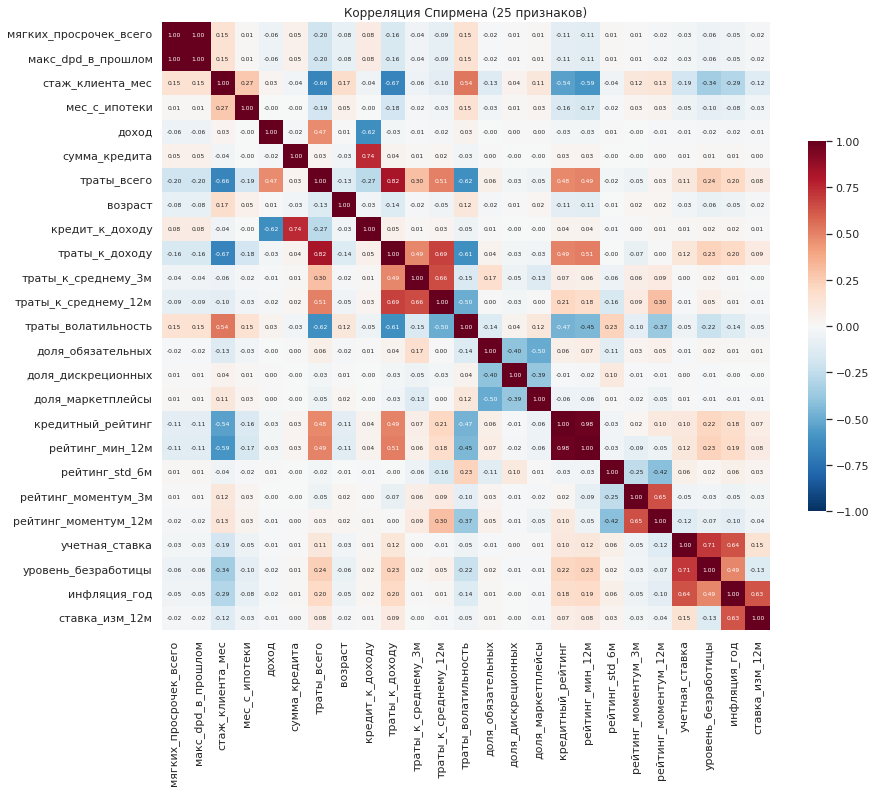

,признак_A,признак_B,|r|,удалить
0,мягких_просрочек_всего,макс_dpd_в_прошлом,0.999481,макс_dpd_в_прошлом
1,кредитный_рейтинг,рейтинг_мин_12м,0.980026,кредитный_рейтинг


К удалению: ['кредитный_рейтинг', 'макс_dpd_в_прошлом']


In [81]:
def correlation_report(df: pd.DataFrame, threshold: float = 0.9) -> pd.DataFrame:
    """Матрица Спирмена + пары, где один из признаков избыточен."""
    num = [c for c in NUMERIC_VARS if c in df]
    corr = df[num].corr(method='spearman')

    fig, ax = plt.subplots(figsize=(13, 11))
    sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 6},
                square=True, cbar_kws={'shrink': .6}, ax=ax)
    ax.set_title(f'Корреляция Спирмена ({len(num)} признаков)')
    plt.tight_layout()
    plt.show()

    target_iv = prof_w.set_index('признак')['IV']
    upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .loc[lambda s: s > threshold]
        .rename('|r|').reset_index()
        .rename(columns={'level_0': 'признак_A', 'level_1': 'признак_B'})
    )
    if not pairs.empty:
        pairs['удалить'] = np.where(
            target_iv.reindex(pairs['признак_A']).values <
            target_iv.reindex(pairs['признак_B']).values,
            pairs['признак_A'], pairs['признак_B'],
        )
    return pairs


redundant_pairs = correlation_report(merged_df)
display(redundant_pairs)
print('К удалению:', sorted(set(redundant_pairs['удалить'])) if not redundant_pairs.empty else 'нет')

### Проверяем мультиколлениарность признаков

In [82]:
check_vif(merged_df, NUMERIC_VARS, 16)

,Feature,VIF
0,мягких_просрочек_всего,835.113864
1,макс_dpd_в_прошлом,834.954245
17,рейтинг_мин_12м,116.944511
16,кредитный_рейтинг,113.952095
13,доля_обязательных,10.102448
9,траты_к_доходу,8.779646
15,доля_маркетплейсы,8.568471
20,рейтинг_моментум_12м,8.139435
14,доля_дискреционных,7.220484
11,траты_к_среднему_12м,6.804840


### Изменения по признакам: удаление плохих признаков и ранжирование

Чтобы исключить временной дрейф признаков из-за инфляции, переводим их из абсолютных значений в процентные внутри кагорты (ранжируем).

| Признак | rho 2014 → 2018 | Заключение | Решение |
|---------|----------------|---------|---------|
| `траты_к_доходу` | +0.313 → +0.417 | стабилен, усиливается | ✅ ранг (PSI 0.261) |
| `траты_к_среднему_3м` | +0.110 → +0.109 | идеально плоский | ✅ как есть |
| `траты_к_среднему_12м` | +0.255 → +0.235 | плоский | ✅ как есть |
| возраст | −0.207 → −0.194 | плоский (контроль) | ✅ как есть |
| `траты_всего` | +0.098 → +0.374 | монотонно, знак един | ✅ как есть |
| кредитный_рейтинг | +0.058 → +0.297 | монотонно, знак един | ✅ как есть |
| `мес_с_ипотеки` | −0.025 → −0.124 | слабо, знак един | ✅ как есть |
| `стаж_клиента_мес` | +0.051 → −0.413 | ⚠️ усечение диапазона | ✅ + биннинг для LogReg |
| `траты_волатильность` | +0.022 → −0.382 | ⚠️ то же | ✅ ранг (PSI 0.346) |


| № | Признак | Группа | Причина удаления | Риск при сохранении |
|---|---------|--------|------------------|---------------------|
| 1 | мягких_просрочек_всего | утечка | Построен из loan_payment_credit — того же источника, что таргет. Наличие записи о просрочке 30–89 дн. означает, что клиент входит в подмножество 5 500 клиентов с просрочками; только они могут иметь target = 1 | Признак почти детерминирует таргет через конструкцию выборки; метрики завышены, на новых клиентах модель развалится |
| 2 | макс_dpd_в_прошлом | утечка | То же + монотонная связь с порогом 90 дней, задающим таргет. Значение близко к 89 = клиент на границе дефолта, отфильтрованного шагом build_target | То же; дополнительно маскирует вклад поведенческих признаков |
| 3 | учетная_ставка | макро | Константа внутри когорты score_date. 59 уникальных значений на 310 647 строк; внутрикогортное ранжирование ≡ 0 | Модель выучивает календарь вместо поведения клиента |
| 4 | инфляция_год | макро | То же | То же |
| 5 | ставка_изм_12м | макро | То же | То же |
| 6 | уровень_безработицы | макро | То же | То же |
| 7 | рейтинг_мин_12м | дубль | Скользящий минимум почти совпадает с уровнем рейтинга. Высокая корреляция с кредитный_рейтинг, инкремента нет | Мультиколлинеарность → нестабильные коэффициенты LogReg |
| 8 | доля_маркетплейсы | шум | IV ниже порога «слабый» | Разбавление признакового пространства, лишний шум для RF |
| 9 | доля_обязательных | шум | Линейная комбинация: доля_продукты + доля_жкх. Сумма всех долей = 1 → строгая коллинеарность внутри блока | Вырожденная матрица признаков для LogReg |
| 10 | доля_дискреционных | шум | Линейная комбинация: доля_фастфуд + доля_рестораны + доля_техника. То же | То же |


In [83]:
# ---------------------------------------------------------------- удаление

LEAK_COLS = ['мягких_просрочек_всего', 'макс_dpd_в_прошлом']
MACRO_COLS = ['учетная_ставка', 'инфляция_год', 'ставка_изм_12м', 'уровень_безработицы']
DUP_COLS = ['рейтинг_мин_12м']
NOISE_COLS = ['доля_маркетплейсы', 'доля_обязательных', 'доля_дискреционных']

DROP_COLS = LEAK_COLS + MACRO_COLS + DUP_COLS + NOISE_COLS

RANK_COLS = ['траты_к_доходу', 'траты_волатильность']

MIN_COHORT_SIZE = 200          # ниже -> pct-ранг нестабилен
DUP_CORR_THRESHOLD = 0.90


def add_cohort_ranks(
    df: pd.DataFrame,
    cols: list[str] = RANK_COLS,
    time_col: str = SCORE_DATE,
    drop_source: bool = True,
    min_cohort: int = MIN_COHORT_SIZE,
) -> pd.DataFrame:
    """
    Ранг внутри когорты score_date: pct-ранг в [0, 1].

    Снимает уровневый дрейф, сохраняя порядок клиентов. Инвариантен к
    инфляции: отвечает на вопрос «где клиент относительно портфеля
    этого месяца», а не «сколько рублей».

    Утечки из будущего нет: ранг считается по срезу одного момента,
    когорты не пересекают границу train/test. Используются другие
    клиенты той же даты — корректно для batch-скоринга портфеля
    (постановка задачи), при онлайн-скоринге понадобится фиксировать
    границы последней когорты.

    Raises
    ------
    KeyError
        Колонка отсутствует в витрине.
    ValueError
        Ранжирование испортило пропуски.
    """
    absent = [c for c in cols if c not in df.columns]
    if absent:
        raise KeyError(f'нет в витрине: {absent}')

    small = df[time_col].value_counts()
    small = small[small < min_cohort]
    if len(small):
        print(f'⚠️ когорт меньше {min_cohort} строк: {len(small)} '
              f'(мин. {small.min()}) — ранг там шумный')

    out = df.copy()
    for c in cols:
        na_before = out[c].isna().sum()
        out[f'{c}_ранг'] = (
            out.groupby(time_col)[c]
               .rank(pct=True, method='average', na_option='keep')
               .astype('float32')
        )
        na_after = out[f'{c}_ранг'].isna().sum()
        if na_before != na_after:
            raise ValueError(f'{c}: NaN {na_before} -> {na_after}')

    return out.drop(columns=cols) if drop_source else out


model_df = add_cohort_ranks(merged_df.drop(columns=DROP_COLS, errors='ignore'))

n_feat = model_df.shape[1] - 3          # минус ID, score_date, target
print(f'{merged_df.shape[1]} → {model_df.shape[1]} колонок (признаков: {n_feat})')
print(f'BR: {model_df[TARGET].mean():.4%}, строк: {len(model_df):,}')

⚠️ когорт меньше 200 строк: 1 (мин. 152) — ранг там шумный
32 → 22 колонок (признаков: 19)
BR: 11.1361%, строк: 424,879


✅ Добавили: `'траты_к_доходу', 'траты_волатильность'`.

✅ Удалили: 

 `'мягких_просрочек_всего',
 'макс_dpd_в_прошлом',
 'учетная_ставка',
 'инфляция_год',
 'ставка_изм_12м',
 'уровень_безработицы',
 'рейтинг_мин_12м',
 'доля_маркетплейсы',
 'доля_обязательных',
 'доля_дискреционных'`

In [84]:
del merged_df
gc.collect()

47588

In [85]:
SERVICE_VARS = (ID_COL, TIME_COL)

BIN_VARS = (
    'наличие_иждивенцев',
    'наличие_ипотеки',
)

CAT_VARS = (
    'семейное_положение',
)

CYCLIC_VARS = (
    'месяц_скоринга',              # 12 -> 1 «рядом»: sin/cos, не порядковый
)

# счётные: целые, шкала осмысленна, распределение дискретное
COUNT_VARS = (
    'стаж_клиента_мес',            # биннинг доменными границами для LogReg
    'мес_с_ипотеки',              # -1 = sentinel «нет ипотеки»
)

# рубли: сильная правая скошенность
CONTINUOUS_MONEY_VARS = (
    'доход',
    'сумма_кредита',
    'траты_всего',
)

# демография: не отношение и не деньги — своя группа
DEMO_VARS = (
    'возраст',
)

# безразмерные отношения
CONTINUOUS_RATIO_VARS = (
    'кредит_к_доходу',
    'траты_к_среднему_3м',
    'траты_к_среднему_12м',
)

# когортные ранги: строго [0, 1], PSI ~ 0 по построению
RANK_VARS = (
    'траты_к_доходу_ранг',
    'траты_волатильность_ранг',
)

# кредитный рейтинг и производные
CONTINUOUS_RATING_VARS = (
    'кредитный_рейтинг',
    'рейтинг_std_6м',
    'рейтинг_моментум_3м',        # знакопеременный
    'рейтинг_моментум_12м',       # знакопеременный
)

MACRO_VARS = ()                   # удалены: константны внутри когорты

NUMERIC_VARS = (
    COUNT_VARS
    + CONTINUOUS_MONEY_VARS
    + DEMO_VARS
    + CONTINUOUS_RATIO_VARS
    + RANK_VARS
    + CONTINUOUS_RATING_VARS
)

FEATURE_VARS = BIN_VARS + CAT_VARS + CYCLIC_VARS + NUMERIC_VARS

In [86]:
# log1p перед скейлером (только неотрицательные и скошенные)
SKEWED_VARS = CONTINUOUS_MONEY_VARS + ('кредит_к_доходу',)

# клиппинг по перцентилям train: отношения с малым знаменателем
CLIP_VARS = (
    'кредит_к_доходу',
    'траты_к_среднему_3м',
    'траты_к_среднему_12м',
    'рейтинг_std_6м',
)

# ограничены по построению -> ни log, ни clip, ни winsorize
BOUNDED_VARS = RANK_VARS

# содержат sentinel-значение -> log1p недопустим
SENTINEL_VARS = {'мес_с_ипотеки': -1}

# знакопеременные -> log1p недопустим
SIGNED_VARS = ('рейтинг_моментум_3м', 'рейтинг_моментум_12м')

# нелинейная связь -> биннинг для LogReg, RF справится сам
BIN_FOR_LOGREG = ('стаж_клиента_мес',) + RANK_VARS

In [87]:
prof_w = profile_features(make_risk_window(model_df)).sort_values('IV', ascending=False)
display(prof_w)

окно: 2014-02 .. 2018-12  (59 когорт)
строк: 310,647 из 424,879 (73.1%)
BR в окне: 12.9620%   BR полной витрины: 11.1361%


,признак,nunique,nan_%,IV,PSI,zero_%,skew,p001,median,p999,max/p999,corr_y,cramers_v,сила_IV
0,стаж_клиента_мес,71,0.0,4.7153,0.328,0.0,0.73,1.00,18.00,69.00,1.0,-0.3169,NaN,⚠️утечка?
1,траты_всего,303829,0.0,3.4068,0.166,0.0,1.42,1618.30,22294.08,263076.18,1.2,0.3289,NaN,⚠️утечка?
2,траты_к_среднему_12м,296599,0.0,3.3928,0.110,0.0,-0.76,0.08,1.03,1.67,1.2,0.2631,NaN,⚠️утечка?
3,траты_к_доходу_ранг,305532,0.0,2.6113,0.000,0.0,0.00,0.00,0.50,1.00,1.0,0.3868,NaN,⚠️утечка?
4,мес_с_ипотеки,72,0.0,2.2661,0.113,0.0,1.44,-1.00,-1.00,68.00,1.0,-0.0993,NaN,⚠️утечка?
5,траты_к_среднему_3м,293658,0.0,1.5899,0.060,0.0,-1.28,0.13,1.02,1.57,1.1,0.1101,NaN,⚠️утечка?
6,траты_волатильность_ранг,296227,0.0,1.0054,0.000,0.0,0.00,0.01,0.50,1.00,1.0,-0.2574,NaN,⚠️утечка?
7,кредитный_рейтинг,486,0.0,0.7583,0.117,0.0,0.05,423.00,616.00,814.00,1.1,0.2514,NaN,⚠️утечка?
8,возраст,683,0.0,0.3428,0.012,0.0,0.05,18.17,44.33,73.75,1.0,-0.1893,NaN,сильный
9,кредит_к_доходу,11403,0.0,0.1553,0.001,0.0,2.22,0.61,24.02,225.80,1.1,0.1175,NaN,средний


Проверим распределение дефолтов по стажу клиента на исходных данных (не на витрине).

count    4712.0
mean       12.2
std         5.1
min         0.0
25%        10.0
50%        12.0
75%        16.0
max        20.0

доля дефолтов при стаже >= 24 мес: 0.00%


<Axes: title={'center': 'Стаж на момент первого дефолта, мес'}, ylabel='Frequency'>

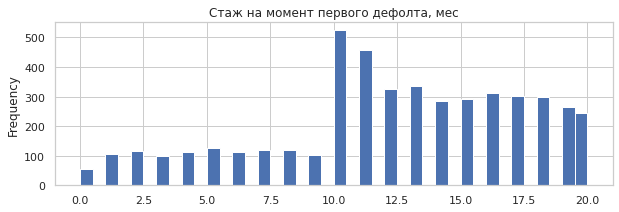

In [88]:
def tenure_at_default(
    loan_payment_credit: pd.DataFrame,
    client_description: pd.DataFrame,
    dpd: int = DEFAULT_DPD_THRESHOLD,
) -> pd.Series:
    """
    Распределение стажа клиента на момент первого дефолта.

    В реальном портфеле кривая созревания (seasoning) имеет максимум
    на 6-18 месяцах и медленно убывает, но никогда не обрывается.
    Жёсткая верхняя граница указывает на артефакт генератора.
    """
    ev = extract_default_events(loan_payment_credit, dpd)
    m = ev.merge(client_description[['ID', 'дата_регистрации']], on='ID', how='left')
    t = _months_between(m['default_date'], m['дата_регистрации'])
    print(t.describe().round(1).to_string())
    print(f'\nдоля дефолтов при стаже >= 24 мес: {(t >= 24).mean():.2%}')
    return t


t_def = tenure_at_default(data.loan_payment_credit.df, data.client_description.df)
t_def.plot.hist(bins=40, figsize=(10, 3), title='Стаж на момент первого дефолта, мес')

In [89]:
del data
gc.collect()

40

👉 Пик дефолтов приходится на 12-ый месяц, а после 20-го нет. стаж_клиента_мес - сильный предиктор.

Ещё, проверим Base Rate по месяцам стажа клиента и доли нулей лагов

In [90]:
def zeros_by_tenure(
    df: pd.DataFrame,
    col: str = 'рейтинг_моментум_12м',
    bins: tuple[int, ...] = (0, 1, 2, 3, 6, 12, 24, 999),
) -> pd.DataFrame:
    """
    Доля тождественных нулей в лаговом признаке в разрезе стажа клиента.

    Если нули концентрируются на малом стаже, значение вырождено
    из-за min_periods=1, а не отражает отсутствие динамики рейтинга.
    """
    g = pd.cut(df['стаж_клиента_мес'], bins=bins, right=False)
    return (
        df.assign(_bin=g)
        .groupby('_bin', observed=True)
        .apply(lambda s: pd.Series({
            'строк': len(s),
            'доля_строк': f'{len(s) / len(df):.1%}',
            'нулей': f'{(s[col] == 0).mean():.1%}',
            'std': round(s[col].std(), 2),
            'BR': f'{s[TARGET].mean():.2%}',
        }))
    )


display(zeros_by_tenure(model_df))

,строк,доля_строк,нулей,std,BR
_bin,,,,,
"[1, 2)",13337,3.1%,100.0%,0.000000,17.40%
"[2, 3)",13116,3.1%,3.0%,6.860000,19.43%
"[3, 6)",38115,9.0%,0.9%,12.270000,22.94%
"[6, 12)",69979,16.5%,0.3%,16.190001,29.86%
"[12, 24)",96657,22.7%,0.1%,17.400000,13.25%
"[24, 999)",193675,45.6%,0.2%,15.050000,0.00%


### Проверяем форму зависимости TARGET от признаков

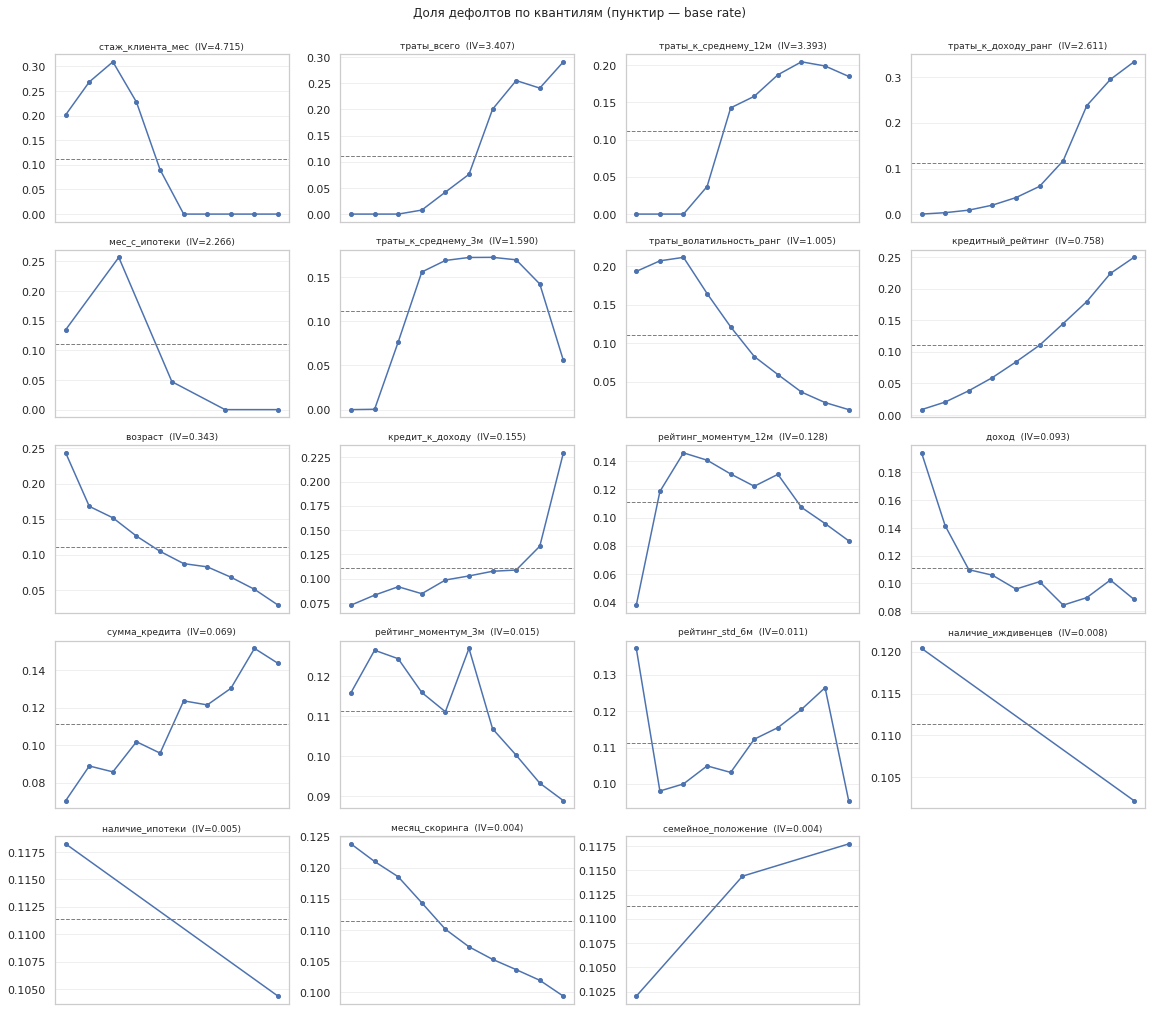

In [91]:
def plot_target_rate(df: pd.DataFrame, features: list[str],
                     bins: int = 10, ncols: int = 4) -> None:
    """
    Доля дефолтов по децилям каждого признака.

    Монотонный тренд -> LogReg справится «как есть».
    U-образный или пилообразный -> нужен биннинг / WoE / только дерево.
    """
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
    base = df[TARGET].mean()

    for ax, col in zip(axes.ravel(), features):
        s = df[col]
        if s.dtype.name in ('category', 'object') or s.nunique() <= bins:
            grp = s.astype('object')
        else:
            grp = pd.qcut(s, bins, duplicates='drop')
        rate = df.groupby(grp, observed=True)[TARGET].mean()
        ax.plot(range(len(rate)), rate.values, marker='o', ms=4)
        ax.axhline(base, color='gray', ls='--', lw=1)
        ax.set_title(f'{col}  (IV={prof_w.set_index("признак").loc[col, "IV"]:.3f})', fontsize=9)
        ax.set_xticks([])
        ax.grid(alpha=.3)

    for ax in axes.ravel()[len(features):]:
        ax.set_visible(False)
    fig.suptitle('Доля дефолтов по квантилям (пунктир — base rate)', y=1.0)
    plt.tight_layout()
    plt.show()


top_features = prof_w.nlargest(26, 'IV')['признак'].tolist()
plot_target_rate(model_df, top_features)

### Выбор кодирования признаков

| Признак | Форма связи с BR | LogisticRegression | RandomForest | Комментарий |
|---------|------------------|-------------------|--------------|-------------|
| `траты_к_доходу_ранг` | ↑ выпуклая, 0.01 → 0.33 | passthrough (уже ранг ∈ [0,1]) | raw | сильнейший признак, PSI ≈ 0 |
| `траты_волатильность_ранг` | ↓ монотонная, 0.20 → 0.00 | passthrough | raw | ранг, PSI ≈ 0 |
| кредитный_рейтинг | ↑ строго монотонная, 0.01 → 0.25 | StandardScaler | raw | шкала инвертирована к домену |
| возраст | ↓ выпуклая, 0.24 → 0.04 | StandardScaler | raw | чистый монотонный |
| сумма_кредита | ↑ слабая монотонная | StandardScaler | raw | |
| доход | ↓ затухающая + шум справа | log1p + StandardScaler | raw | правый хвост шумит |
| траты_всего | ↑ + плато нуля (3 квантиля) | log1p + StandardScaler | raw | сепарабельность, см. вывод |
| траты_к_среднему_12м | ↑ + плато нуля (3 квантиля), спад на конце | KBinsDiscretizer(10, ordinal) | raw | биннинг сохраняет плато |
| стаж_клиента_мес | горб ↑↓ + плато нуля | KBinsDiscretizer(8, onehot) | raw | немонотонная, линейно не описать |
| `мес_с_ипотеки` | горб ↑↓ + плато нуля, sentinel −1 | KBinsDiscretizer(8, onehot) | raw | −1 попадёт в отдельный бин |
| `траты_к_среднему_3м` | ∩-образная: 0 → плато 0.17 → 0.05 | + траты_шок_3м = \|x−1\|, затем StandardScaler | raw | риск в обе стороны от нормы |
| кредит_к_доходу | плоская + скачок в 10-м квантиле | + индикатор x > p90 | raw | сигнал только в хвосте |
| `рейтинг_моментум_12м` | ∩ слабая, 0.04 → 0.145 → 0.08 | KBinsDiscretizer(6, onehot) | raw | ρ_внутри 0.011 — на грани |
| рейтинг_моментум_3м | зигзаг, без формы | StandardScaler | raw | оставлен по требованию ТЗ |
| `рейтинг_std_6м` | зигзаг, без формы | StandardScaler | raw | оставлен по требованию ТЗ |
| `наличие_иждивенцев` | бинарный ↓ 0.120 → 0.103 | passthrough | raw | |
| наличие_ипотеки | бинарный ↓ 0.118 → 0.105 | passthrough | raw | |
| семейное_положение | категориальный, разброс 0.102–0.118 | OneHotEncoder(drop='first') | OrdinalEncoder | 3 категории |
| месяц_скоринга | ↓ по номеру месяца, IV 0.004 | sin/cos (цикличность) | raw | ординальное кодирование месяца некорректно |


### Промежуточный вывод

Признаки прогнаны через сводную диагностику: IV, PSI (train/test по 12-месячной отсечке), Cramér's V для категориального, skew, перцентили 0.1/99.9%, доля нулей, корреляция Спирмена с таргетом. Дополнительно — матрица Спирмена по всем численным, VIF, стабильность IV и ρ по годам, разброс внутри когорты и распределение стажа на момент дефолта.

Сила признаков измеряется не на всей витрине, а на окне risk_window (2014-02 … 2018-12, 59 когорт, 310 647 строк). Слева отсечены 12 месяцев, где 12-месячные лаги не прогреты, справа — 365 дней, где горизонт таргета не наблюдаем. Без этого IV считался бы на данных с искусственно занижённым BR на правом краю. Обучение при этом идёт на полной витрине — окно нужно только для отбора.

Вот витрина и окно:

In [92]:
def facts_pair(
    full: pd.DataFrame,
    features: tuple[str, ...],
) -> pd.DataFrame:
    """
    Сводка по витрине обучения и по окну анализа риска.

    Разделение принципиально: сила признаков (IV/PSI) измеряется
    на окне с прогретыми лагами и полным горизонтом таргета, а модель
    обучается на всей витрине.
    """
    win = make_risk_window(full)

    def row(df: pd.DataFrame, name: str) -> dict:
        br = df[TARGET].mean()
        by_m = df.groupby(SCORE_DATE)[TARGET].mean()
        return {
            'объект': name,
            'строк': f'{len(df):,}',
            'клиентов': f'{df["ID"].nunique():,}',
            'когорт': df[SCORE_DATE].nunique(),
            'период': f'{df[SCORE_DATE].min():%Y-%m}…{df[SCORE_DATE].max():%Y-%m}',
            'BR': f'{br:.2%}',
            'BR по когортам': f'{by_m.min():.2%}…{by_m.max():.2%}',
            'пропусков': int(df[list(features)].isna().sum().sum()),
        }

    return pd.DataFrame([
        row(full, 'model_df (обучение)'),
        row(win, 'risk_window (анализ)'),
    ])


display(facts_pair(model_df, FEATURE_VARS))

окно: 2014-02 .. 2018-12  (59 когорт)
строк: 310,647 из 424,879 (73.1%)
BR в окне: 12.9620%   BR полной витрины: 11.1361%


,объект,строк,клиентов,когорт,период,BR,BR по когортам,пропусков
0,model_df (обучение),"424,879","13,337",83,2013-02…2019-12,11.14%,0.53%…26.58%,0
1,risk_window (анализ),"310,647","11,404",59,2014-02…2018-12,12.96%,8.58%…26.58%,0


✅ Проверили итоговую витрину и окно для оценки метрик при отборе признаков.

Удалено 10 признаков из 29 по четырём причинам. 

**Утечка (2)**. мягких_просрочек_всего и макс_dpd_в_прошлом при IV 0.47 имеют отрицательную корреляцию с таргетом — знак противоречит домену. Проверка вскрыла причину: в группе с ненулевым значением BR ровно 0.0000 на 15 117 строках против 13.63% у остальных. В loan_payment_credit ID уникален, то есть одна запись на клиента: наличие эпизода 80–89 дней означает, что дефолта 90+ у клиента не будет никогда. Признак кодирует не поведение, а конструкцию выборки. Взаимная корреляция 0.999 и VIF 835 — они дублируют друг друга.

**Макро (4)**. Все четыре показателя константны внутри когорты: nunique = 1 при std = 0 в каждом месяце, тогда как по выборке std от 0.36 до 4.15. Ранжировать клиентов по ним невозможно — они кодируют календарь, а не риск. Отсюда и аномальный PSI 6.9–11.5: он ловит смену режима ДКП между train и test. Оставить их значило бы дать модели выучить, что «в 2015 году дефолтов было больше».

**Дубль (1)**. рейтинг_мин_12м коррелирует с кредитный_рейтинг на 0.98, VIF 117 против 114. Инкремента нет, для LogReg это нестабильные коэффициенты.

**Шум (3)**. Три доли MCC при IV 0.001–0.002. Дополнительно: сумма всех долей корзины равна единице, то есть блок вырожден по построению — для линейной модели это строгая коллинеарность.

**Добавлено** 2 признака — когортные pct-ранги для траты_к_доходу (PSI 0.261) и траты_волатильность (PSI 0.346). Ранжирование внутри score_date снимает уровневый дрейф от инфляции, сохраняя порядок клиентов.

Итог: 32 → 22 колонки, 19 признаков. BR 11.14% не изменился, пропусков не осталось — единственная колонка с NaN (ставка_изм_12м) ушла вместе с макро.

**Стабильность по годам**. Проверка вскрыла системный паттерн: BR падает с 23.4% (2014) до 10.6% (2018), а IV признаков монотонно растёт — например, траты_к_доходу с 0.05 до 7.21. Это не деградация признаков, а улучшение качества портфеля: дефолты концентрируются в меньшей и более отличимой группе.

Два признака **меняют знак**: стаж_клиента_мес (+0.051 → −0.413) и траты_волатильность (+0.022 → −0.382). Причина — усечение диапазона: в 2014 году у всех клиентов стаж короткий, эффект не проявлен. Признаки сохранены, для LogReg предусмотрен биннинг.

Проверка на исходных данных показала, что первый дефолт наступает при стаже 0–20 месяцев с пиком на 12-м, доля дефолтов при стаже ≥ 24 месяцев ровно 0%. 

**Вырожденность лагов на малом стаже**. zeros_by_tenure показал, что при стаже 1 месяц рейтинг_моментум_12м тождественно равен нулю в 100% случаев (13 337 строк, 3.1% витрины) — следствие min_periods=1, окно состоит из одного наблюдения. Начиная со 2-го месяца доля нулей падает до 3.0%, дальше ниже 1%. Объём невелик, значение осмысленно как «динамики пока нет», импьютация не требуется. Заодно видна и кривая BR по стажу: 17.4% → 29.9% (пик 6–12 мес) → 0.00% после 24 месяцев.

**Форма связи с TARGET**. Графики доли дефолтов по децилям разделили признаки на три типа. Монотонные (кредитный_рейтинг, возраст, ранги, сумма_кредита) — LogReg справится со скейлером. Немонотонные с горбом (стаж_клиента_мес, мес_с_ипотеки, рейтинг_моментум_12м) — линейно не описываются, нужен KBinsDiscretizer(onehot). ∩-образные и хвостовые (траты_к_среднему_3м, кредит_к_доходу) — требуют производных признаков: траты_шок_3м = |x − 1| и индикатор превышения p90. Random Forest работает с сырыми значениями во всех случаях.

## Разделение на выборки

In [93]:
HORIZON_MONTHS = 12
# Окно таргета полуоткрыто: [s, s + 365 дн.). Когорта s = V − 12 мес закрывается
# ровно на V и пересечения не даёт. Выбросить нужно V−11 … V−1.
EMBARGO_MONTHS = HORIZON_MONTHS - 1        

TEST_MONTHS = 12
CALIB_MONTHS = 12

CV_SPLITS = 3
CV_VALID_MONTHS = 4                        # обосновано бюджетом когорт, см. ниже
CV_GAP_MONTHS = EMBARGO_MONTHS             # тот же вывод внутри CV

N_JOBS = -1

In [94]:
@dataclass(frozen=True)
class TimeSplit:
    train: np.ndarray
    calib: np.ndarray
    test: np.ndarray
    unmatured: np.ndarray
    bounds: pd.DataFrame

    def apply(self, df: pd.DataFrame) -> dict[str, pd.DataFrame]:
        return {k: df.loc[getattr(self, k)]
                for k in ('train', 'calib', 'test', 'unmatured')}


def make_time_split(
    df: pd.DataFrame,
    time_col: str = SCORE_DATE,
    horizon_months: int = HORIZON_MONTHS,
    test_months: int = TEST_MONTHS,
    calib_months: int = CALIB_MONTHS,
    embargo_months: int = EMBARGO_MONTHS,
) -> TimeSplit:
    """
    Раскладка блоков по календарю:

        [ ---- Train ---- ][ embargo ][ Calib ][ Test ][ unmatured ]

    Отличия от наивной схемы:

    1. Embargo = horizon − 1 когорта, а не horizon. Окно таргета полуоткрыто,
       поэтому когорта V − 12 мес пересечения с V не даёт.
    2. Embargo стоит ОДИН РАЗ — перед Calib. Между Calib и Test его нет:
       калибратор настраивает 1-2 параметра поверх готовых скоров и не
       переносит в Test информацию о ранжировании. 
    3. `unmatured` — когорты с ненаблюдаемым горизонтом, выведены из
       обучения и оценки.
    """
    cohorts = np.sort(df[time_col].unique())
    n = len(cohorts)

    matured_end = n - horizon_months          # последняя когорта с полным таргетом
    test_start = matured_end - test_months
    calib_start = test_start - calib_months
    train_end = calib_start - embargo_months  # exclusive

    need = CV_GAP_MONTHS + CV_SPLITS * CV_VALID_MONTHS + 1
    if train_end < need:
        raise ValueError(
            f'Train = {train_end} когорт, для CV нужно >= {need} '
            f'(gap={CV_GAP_MONTHS}, {CV_SPLITS}x{CV_VALID_MONTHS}). '
            f'Рычаги: CV_VALID_MONTHS вниз или CALIB_MONTHS вниз.'
        )

    blocks = {
        'train': (0, train_end),
        'calib': (calib_start, test_start),
        'test': (test_start, matured_end),
        'unmatured': (matured_end, n),
    }

    def mask(lo: int, hi: int) -> np.ndarray:
        if hi <= lo:
            return np.zeros(len(df), dtype=bool)
        return df[time_col].isin(cohorts[lo:hi]).to_numpy()

    bounds = pd.DataFrame([
        {'блок': k, 'когорт': hi - lo,
         'от': f'{pd.Timestamp(cohorts[lo]):%Y-%m}',
         'до': f'{pd.Timestamp(cohorts[hi - 1]):%Y-%m}'}
        for k, (lo, hi) in blocks.items() if hi > lo
    ] + [
        {'блок': 'embargo (выброшено)', 'когорт': embargo_months,
         'от': f'{pd.Timestamp(cohorts[train_end]):%Y-%m}',
         'до': f'{pd.Timestamp(cohorts[calib_start - 1]):%Y-%m}'}
    ])

    return TimeSplit(bounds=bounds, **{k: mask(*v) for k, v in blocks.items()})

In [95]:
def audit_base_rate(parts: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """
    BR по блокам сплита. Дрейф base rate напрямую бьёт по переносу
    порога: порог, откалиброванный на Calib под DR <= 2%, на Test
    с другим BR даст другой DR.
    """
    rows = [
        {'блок': k, 'строк': f'{len(p):,}', 'BR': f'{p[TARGET].mean():.2%}',
         'дефолтов': int(p[TARGET].sum()),
         'от': f'{p[SCORE_DATE].min():%Y-%m}', 'до': f'{p[SCORE_DATE].max():%Y-%m}'}
        for k, p in parts.items() if len(p)
    ]
    return pd.DataFrame(rows)

In [96]:
# Готовим разбиение по месячному временному ряду
split = make_time_split(model_df)
parts = split.apply(model_df)

display(split.bounds)

# --- проверки и правки
LEAKY = {TARGET, 'ID', SCORE_DATE, 'default_date'}
assert not (set(FEATURE_VARS) & LEAKY)
display(audit_base_rate(parts))

,блок,когорт,от,до
0,train,36,2013-02,2016-01
1,calib,12,2017-01,2017-12
2,test,12,2018-01,2018-12
3,unmatured,12,2019-01,2019-12
4,embargo (выброшено),11,2016-02,2016-12


,блок,строк,BR,дефолтов,от,до
0,train,"94,933",19.36%,18378,2013-02,2016-01
1,calib,"77,551",10.07%,7810,2017-01,2017-12
2,test,"92,346",10.55%,9746,2018-01,2018-12
3,unmatured,"101,796",4.26%,4335,2019-01,2019-12


In [97]:
# получаем выборки
train_df = parts['train']

X_train = train_df[list(FEATURE_VARS)]
y_train = train_df[TARGET].to_numpy()
groups_train = train_df[SCORE_DATE].to_numpy()

X_calib, y_calib = parts['calib'][list(FEATURE_VARS)], parts['calib'][TARGET].to_numpy()
X_test,  y_test  = parts['test'][list(FEATURE_VARS)],  parts['test'][TARGET].to_numpy()

In [98]:
def cohort_codes(cohorts: pd.Series) -> np.ndarray:
    """
    Timestamp -> 0, 1, 2, ... в хронологическом порядке.

    mlxtend работает с группами как с числовой последовательностью,
    поэтому даты конвертируются в коды. Побочная выгода: в отладке
    границы фолдов читаются как номера когорт.
    """
    c = pd.Series(cohorts).reset_index(drop=True)
    order = np.sort(pd.unique(c))
    return pd.Categorical(c, categories=order, ordered=True).codes.astype(np.int64)


def assert_groups_contiguous(codes: np.ndarray) -> None:
    """
    Проверка предусловия mlxtend: строки одной когорты идут подряд,
    когорты возрастают.

    В отличие от самописного сплиттера здесь порядок строк витрины
    влияет на корректность, поэтому инвариант проверяется явно.
    """
    starts = np.r_[0, np.flatnonzero(np.diff(codes) != 0) + 1]
    seq = codes[starts]

    if len(seq) != len(np.unique(codes)):
        raise ValueError(
            'строки одной когорты не идут подряд — '
            "витрину нужно отсортировать: df.sort_values(['score_date', 'ID'])"
        )
    if not np.all(np.diff(seq) > 0):
        raise ValueError(
            'когорты не возрастают — '
            "витрину нужно отсортировать: df.sort_values(['score_date', 'ID'])"
        )

In [99]:
def make_cv_folds(
    cohorts: pd.Series,
    n_splits: int = CV_SPLITS,
    valid_size: int = CV_VALID_MONTHS,
    gap: int = CV_GAP_MONTHS,
    max_train_size: Optional[int] = None,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Фолды out-of-time для витрины поведенческого скоринга.

    Схема: sklearn.TimeSeriesSplit нарезает не строки, а массив уникальных
    когорт; результат разворачивается в позиционные индексы строк.

    Почему не по строкам напрямую:
      * `gap` в строках дал бы РАЗНЫЙ embargo в месяцах на разных фолдах —
        размер когорты у нас плывёт в разы (клиенты регистрируются
        постепенно). Тихая утечка ровно там, где её закрывали;
      * когорта разрезалась бы пополам, а все её строки делят одно окно
        таргета — одно окно оказалось бы с обеих сторон границы.

    Метод order-agnostic: позиции когорт восстанавливаются из значений,
    поэтому порядок строк витрины на нарезку не влияет.

    Returns
    -------
    list[(train_idx, valid_idx)] — позиционные индексы, готовы к передаче
    в `cv` любого инструмента sklearn и внутрь Optuna.
    """
    c = pd.Series(cohorts).reset_index(drop=True)
    order = np.sort(pd.unique(c))
    codes = pd.Categorical(c, categories=order, ordered=True).codes

    need = gap + n_splits * valid_size + 1
    if len(order) < need:
        raise ValueError(
            f'Когорт {len(order)}, нужно >= {need} '
            f'(gap={gap}, {n_splits}x{valid_size}). '
            f'Рычаги: valid_size вниз или CALIB_MONTHS вниз.'
        )

    tss = TimeSeriesSplit(
        n_splits=n_splits, test_size=valid_size, gap=gap,
        max_train_size=max_train_size,
    )
    return [
        (np.flatnonzero(np.isin(codes, tr_c)), np.flatnonzero(np.isin(codes, va_c)))
        for tr_c, va_c in tss.split(np.arange(len(order)))
    ]

In [100]:
def describe_folds(
    folds: list[tuple[np.ndarray, np.ndarray]],
    cohorts: pd.Series,
    y: Optional[np.ndarray] = None,
    client_ids: Optional[np.ndarray] = None,
) -> pd.DataFrame:
    """Контрольная таблица перед обучением."""
    c = pd.Series(cohorts).reset_index(drop=True).to_numpy()
    rows = []
    for i, (tr, va) in enumerate(folds, 1):
        t, v = np.sort(pd.unique(c[tr])), np.sort(pd.unique(c[va]))
        gap_m = (pd.Timestamp(v[0]).to_period('M') - pd.Timestamp(t[-1]).to_period('M')).n - 1
        row = {
            'фолд': i,
            'train': f'{pd.Timestamp(t[0]):%Y-%m}…{pd.Timestamp(t[-1]):%Y-%m}',
            'когорт': len(t), 'строк_tr': f'{len(tr):,}',
            'gap_мес': gap_m,
            'valid': f'{pd.Timestamp(v[0]):%Y-%m}…{pd.Timestamp(v[-1]):%Y-%m}',
            'строк_va': f'{len(va):,}',
        }
        if y is not None:
            y = np.asarray(y)
            row |= {'BR_tr': f'{y[tr].mean():.2%}', 'BR_va': f'{y[va].mean():.2%}'}
        if client_ids is not None:
            ids = np.asarray(client_ids)
            row['клиентов_из_tr'] = f'{np.isin(ids[va], np.unique(ids[tr])).mean():.0%}'
        rows.append(row)
    return pd.DataFrame(rows)

In [101]:
def make_cv_folds_reference(
    cohorts: pd.Series,
    n_splits: int = CV_SPLITS,
    valid_size: int = CV_VALID_MONTHS,
    gap: int = CV_GAP_MONTHS,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """
    Эталон на sklearn.TimeSeriesSplit, нарезающем массив когорт.

    Нужен ровно для одного: подтвердить, что параметры mlxtend поняты
    правильно. В рабочем коде не используется.
    """
    codes = cohort_codes(cohorts)
    order = np.arange(len(np.unique(codes)))
    tss = TimeSeriesSplit(n_splits=n_splits, test_size=valid_size, gap=gap)
    return [
        (np.flatnonzero(np.isin(codes, tr_c)), np.flatnonzero(np.isin(codes, va_c)))
        for tr_c, va_c in tss.split(order)
    ]


def assert_folds_valid(
    folds: list[tuple[np.ndarray, np.ndarray]],
    cohorts: pd.Series,
    y: np.ndarray,
    expected_gap: int = CV_GAP_MONTHS,
    horizon_months: int = HORIZON_MONTHS,
) -> None:
    """
    Инварианты CV-фолдов. Ловит именно тот класс ошибок, что дал
    shift_size=0: молчаливое схлопывание фолдов.
    """
    c = pd.Series(cohorts).reset_index(drop=True).to_numpy()
    seen_valid = []

    for i, (tr, va) in enumerate(folds, 1):
        t, v = np.unique(c[tr]), np.unique(c[va])

        # 1. embargo фактический, а не заявленный
        gap = (pd.Timestamp(v.min()).to_period('M')
               - pd.Timestamp(t.max()).to_period('M')).n - 1
        assert gap == expected_gap, f'фолд {i}: gap={gap}, ожидался {expected_gap}'

        # 2. окно таргета train не достаёт до valid
        assert pd.Timestamp(t.max()) + pd.Timedelta(days=365) <= pd.Timestamp(v.min()), \
            f'фолд {i}: окна таргета train и valid пересекаются'

        # 3. когорта неделима
        assert not (set(t) & set(v)), f'фолд {i}: когорта попала в оба блока'

        # 4. оба класса присутствуют
        assert len(np.unique(y[tr])) == 2 and len(np.unique(y[va])) == 2, \
            f'фолд {i}: один класс в блоке'

        seen_valid.append(tuple(v))

    # 5. фолды различны — иначе std по фолдам фиктивен
    assert len(set(seen_valid)) == len(folds), \
        'фолды идентичны: std(ROC-AUC) будет нулевым искусственно'

    # 6. валидационные блоки не перекрываются
    flat = [x for v in seen_valid for x in v]
    assert len(flat) == len(set(flat)), 'валидационные блоки перекрываются'

    print(f'✅ {len(folds)} фолда, embargo {expected_gap} мес, '
          f'блоки валидации различны и не перекрываются')


### Создание и проверка фолдов

In [102]:
folds = make_cv_folds(pd.Series(groups_train))

assert_folds_valid(folds, train_df[SCORE_DATE], y_train)

display(describe_folds(folds, train_df[SCORE_DATE], y_train, train_df['ID'].to_numpy()))

✅ 3 фолда, embargo 11 мес, блоки валидации различны и не перекрываются


,фолд,train,когорт,строк_tr,gap_мес,valid,строк_va,BR_tr,BR_va,клиентов_из_tr
0,1,2013-02…2014-02,13,"14,483",11,2015-02…2015-05,"14,752",22.50%,17.98%,39%
1,2,2013-02…2014-06,17,"24,104",11,2015-06…2015-09,"16,453",23.69%,16.54%,46%
2,3,2013-02…2014-10,21,"35,690",11,2015-10…2016-01,"18,096",23.42%,14.70%,52%


### Проверка выполнимости требований по метрикам

In [103]:
def threshold_at_ar(proba, ar_target: float = TARGET_APPROVAL_RATE) -> float:
    """
    Порог, дающий заданный approval rate.

    Одобряем ar_target-долю с наименьшей вероятностью дефолта, поэтому
    порог — это просто квантиль распределения предсказаний. Позволяет
    сравнивать модели в одной операционной точке, не зависящей от
    калибровки: любое монотонное преобразование вероятностей даёт тот же
    результат.
    """
    return float(np.quantile(np.asarray(proba), ar_target))


def threshold_under_constraints(
    y_true, proba,
    dr_limit: float = MAX_DEFAULT_RATE,
    mdr_limit: float = MAX_MISSED_DEFAULTS,
    ar_grid: Optional[np.ndarray] = None,
) -> dict:
    """
    Максимизировать AR при DR <= dr_limit и MDR <= mdr_limit.

    AR, DR и MDR монотонно растут с порогом, поэтому идём от большого
    одобрения к малому и берём первую точку, где оба ограничения
    выполнены.
    """
    if ar_grid is None:
        ar_grid = np.arange(0.99, 0.29, -0.005)

    for ar in ar_grid:
        m = business_metrics(y_true, proba, threshold_at_ar(proba, ar))
        if m['DR'] <= dr_limit and m['MDR'] <= mdr_limit:
            m['feasible'] = True
            return m

    m = business_metrics(y_true, proba, threshold_at_ar(proba, ar_grid[-1]))
    m['feasible'] = False
    return m

def feasibility_report(
    br: float,
    ar_target: float = TARGET_APPROVAL_RATE,
    dr_limit: float = MAX_DEFAULT_RATE,
    mdr_limit: float = MAX_MISSED_DEFAULTS,
) -> pd.DataFrame:
    """
    Что требования ТЗ означают в терминах ROC-точки.

    Тождество DR = MDR * BR / AR связывает ограничения: при
    фиксированном AR и известном BR они не независимы, и одно из них
    оказывается строго сильнее второго.
    """
    dr_from_mdr = mdr_limit * br / ar_target
    mdr_from_dr = dr_limit * ar_target / br

    rows = [{
        'BR': f'{br:.2%}',
        'AR': f'{ar_target:.0%}',
        'DR при MDR=4%': f'{dr_from_mdr:.2%}',
        'MDR при DR=2%': f'{mdr_from_dr:.2%}',
        'связывающее': 'MDR' if dr_from_mdr <= dr_limit else 'DR',
    }]

    # ROC-точка, необходимая для соблюдения связывающего ограничения
    mdr_eff = min(mdr_limit, mdr_from_dr)
    tpr = 1 - mdr_eff
    fn = mdr_eff * br
    tn = ar_target - fn
    fpr = 1 - tn / (1 - br)
    rows[0] |= {
        'нужен Recall': f'{tpr:.1%}',
        'нужен FPR': f'{fpr:.1%}',
        'precision реджекта': f'{tpr * br / (1 - ar_target):.1%}',
    }
    return pd.DataFrame(rows)

In [104]:
display(feasibility_report(br=y_train.mean()))

,BR,AR,DR при MDR=4%,MDR при DR=2%,связывающее,нужен Recall,нужен FPR,precision реджекта
0,19.36%,65%,1.19%,6.72%,MDR,96.0%,20.4%,53.1%


In [105]:
def approve_mask_at_ar(proba, ar_target=TARGET_APPROVAL_RATE, random_state=SEED):
    """
    Маска одобрения ровно на ar_target долю наблюдений.

    Квантильный порог при связках даёт AR ниже целевого (RF на 100
    деревьях выдаёт дискретные вероятности). Здесь одобряются ровно
    k наблюдений с минимальным скором, связки рвутся детерминированным
    шумом — операционная точка становится точной, что критично для
    сравнения трайлов Optuna.
    """
    p = np.asarray(proba, dtype=float)
    n = len(p)
    k = int(round(ar_target * n))
    tie = np.random.default_rng(random_state).random(n)
    order = np.lexsort((tie, p))
    mask = np.zeros(n, dtype=bool)
    mask[order[:k]] = True
    return mask


def business_metrics_at_ar(y_true, proba, ar_target=TARGET_APPROVAL_RATE,
                           random_state=SEED) -> dict:
    """AR/DR/MDR в точно заданной операционной точке AR."""
    y = np.asarray(y_true).astype(bool)
    approved = approve_mask_at_ar(proba, ar_target, random_state)

    fn = int((approved & y).sum());  tn = int((approved & ~y).sum())
    tp = int((~approved & y).sum()); fp = int((~approved & ~y).sum())
    n = fn + tn + tp + fp
    return {'AR': (fn + tn) / n,
            'DR': fn / (fn + tn) if (fn + tn) else np.nan,
            'MDR': fn / (fn + tp) if (fn + tp) else np.nan,
            'BR': (fn + tp) / n,
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn, 'N': n}

In [106]:
def report_requirements(
    detail: pd.DataFrame,
    ar_target: float = TARGET_APPROVAL_RATE,
    dr_limit: float = MAX_DEFAULT_RATE,
    mdr_limit: float = MAX_MISSED_DEFAULTS,
) -> pd.DataFrame:
    """Сводка «модель vs требования ТЗ» в читаемом виде."""
    g = detail.groupby('model')
    out = pd.DataFrame({
        'ROC-AUC': g['roc_auc'].mean().round(4),
        '± std': g['roc_auc'].std().round(4),
        'PR-AUC': g['pr_auc'].mean().round(4),
        'Brier': g['brier'].mean().round(4),
        'AR': g['AR'].mean().round(4),
        'DR': g['DR'].mean().round(4),
        'MDR': g['MDR'].mean().round(4),
    })
    if 'overfit_gap' in detail.columns:
        out['gap tr-va'] = g['overfit_gap'].mean().round(4)

    out['AR ≥ 65%'] = np.where(out['AR'] >= ar_target - 0.01, '✅', '❌')
    out['DR < 2%'] = np.where(out['DR'] < dr_limit, '✅', '❌')
    out['MDR ≤ 4%'] = np.where(out['MDR'] <= mdr_limit, '✅', '❌')

    return out.sort_values('ROC-AUC', ascending=False)

## Пайплайн

In [107]:
# сентинелы, порождённые feature engineering: значение-метка, не число
SENTINELS: dict[str, tuple] = {
    'мес_с_ипотеки': (-1,),      # -1 = «ипотеки нет», а не «минус один месяц»
}
FINGERPRINT_COLS = ['доход', 'сумма_кредита']

# сентинелы, которые нельзя отдавать линейной модели как число
SENTINEL_NEG_ONE = ['мес_с_ипотеки']


class FrameSanitizer(BaseEstimator, TransformerMixin):
    """
    Приведение сырой витрины к виду, пригодному для импьютера.

    Делает две вещи:
      * сентинел-значения -> NaN, чтобы SimpleImputer + add_indicator
        восстановили их смысл, а линейная модель не прочитала метку
        как число;
      * ±inf -> NaN (остатки pct_change и делений на ноль).

    Трансформация без состояния, но обязана жить внутри Pipeline:
    иначе сохранённая модель на инференсе получит сырые -1 и выдаст
    другие скоры при формально исправной работе.

    Работает с DataFrame и возвращает DataFrame — ставится ДО
    ColumnTransformer, который выбирает колонки по именам.
    """

    def __init__(self, sentinels: Optional[dict[str, tuple]] = None,
                 replace_inf: bool = True):
        self.sentinels = sentinels
        self.replace_inf = replace_inf

    def fit(self, X: pd.DataFrame, y=None):
        if not isinstance(X, pd.DataFrame):
            raise TypeError('FrameSanitizer работает с DataFrame')

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]

        sentinels = SENTINELS if self.sentinels is None else self.sentinels
        self.sentinels_ = {c: v for c, v in sentinels.items() if c in X.columns}
        self.numeric_cols_ = X.select_dtypes('number').columns.tolist()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        for col, values in self.sentinels_.items():
            # замена на NaN всё равно поднимет int -> float, фиксируем float32
            X[col] = X[col].replace(list(values), np.nan).astype('float32')

        if self.replace_inf:
            cols = [c for c in self.numeric_cols_ if c in X.columns]
            X[cols] = X[cols].replace([np.inf, -np.inf], np.nan)

        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            self.feature_names_in_ if input_features is None else input_features,
            dtype=object,
        )

In [108]:
@dataclass
class ColumnGroups:
    """Группы колонок для ColumnTransformer."""
    numeric: list[str]
    binary: list[str]
    categorical: list[str]
    fingerprint: list[str]

    def summary(self) -> pd.DataFrame:
        return pd.DataFrame([
            {'группа': k, 'колонок': len(v)}
            for k, v in {
                'numeric': self.numeric, 'binary': self.binary,
                'categorical': self.categorical, 'fingerprint': self.fingerprint,
            }.items()
        ])


def detect_column_groups(
    X: pd.DataFrame,
    fingerprint: Optional[list[str]] = None,
) -> ColumnGroups:
    """
    Автоопределение типов колонок.

    Бинарные выделяются отдельно: их не нужно масштабировать и незачем
    пропускать через OneHot.
    """
    fingerprint = [c for c in (fingerprint or FINGERPRINT_COLS) if c in X.columns]
    categorical = X.select_dtypes(include=['category', 'object']).columns.tolist()

    rest = [c for c in X.columns if c not in categorical + fingerprint]
    binary = [c for c in rest if X[c].dropna().nunique() <= 2]
    numeric = [c for c in rest if c not in binary]

    return ColumnGroups(numeric, binary, categorical, fingerprint)


def make_preprocessor(
    groups: ColumnGroups,
    scale: bool,
    defuse_fingerprint: bool = False,
    n_bins: int = 20,
) -> ColumnTransformer:
    """
    Препроцессор под конкретное семейство моделей.

    Parameters
    ----------
    scale
        True для логрегрессии (нужен StandardScaler и сопоставимые
        масштабы для L2), False для деревьев.
    defuse_fingerprint
        Заменить `доход` и `сумма_кредита` на квантильные бины. Монотонная
        информация сохраняется, возможность идентифицировать клиента по
        точному значению — исчезает. Включать, если разрыв ROC-AUC между
        OOT и OOT+OOC превышает 0.03.

    Notes
    -----
    add_indicator=True принципиален: NaN в лаговых признаках означает
    короткую историю клиента, а это самостоятельный сигнал риска, а не
    техническая дырка.
    """
    num_steps = [('imp', SimpleImputer(strategy='median', add_indicator=True))]
    if scale:
        num_steps.append(('sc', StandardScaler()))

    try:
        ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False)
    except TypeError:                       # sklearn < 1.2
        ohe = OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse=False)

    blocks = [
        ('num', Pipeline(num_steps), groups.numeric),
        ('bin', SimpleImputer(strategy='most_frequent'), groups.binary),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', ohe),
        ]), groups.categorical),
    ]

    if groups.fingerprint:
        if defuse_fingerprint:
            fp = Pipeline([
                ('imp', SimpleImputer(strategy='median')),
                ('bin', KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                                         strategy='quantile', subsample=200_000)),
            ])
        else:
            fp = Pipeline(num_steps)
        blocks.append(('fp', fp, groups.fingerprint))

    return ColumnTransformer(blocks, remainder='drop', verbose_feature_names_out=False)

In [109]:
def build_model_zoo(
    groups: ColumnGroups,
    defuse_fingerprint: bool = False,
    sentinels: Optional[dict[str, tuple]] = None,
    random_state: int = SEED,
) -> dict[str, Pipeline]:
    """
    Четыре базовые модели по ТЗ: LogReg и RF, с балансировкой и без.

    Структура пайплайна: san -> pre -> clf. Первый шаг делает витрину
    самодостаточной на входе, поэтому модель принимает сырые данные и
    ручная предобработка перед fit/predict не нужна.

    Балансировка — class_weight. Ресемплинг не оправдан: BR ~20% —
    умеренный дисбаланс, undersampling выбросил бы половину данных,
    SMOTE синтезировал бы клиентов поперёк временной структуры.

    RF намеренно с max_depth=None — ТЗ требует показать переобучение
    до подбора гиперпараметров.
    """
    san = lambda: FrameSanitizer(sentinels=sentinels)
    pre_scaled = lambda: make_preprocessor(groups, scale=True, defuse_fingerprint=defuse_fingerprint)
    pre_raw = lambda: make_preprocessor(groups, scale=False, defuse_fingerprint=defuse_fingerprint)

    lr_kw = dict(max_iter=2000, solver='lbfgs', n_jobs=-1, random_state=random_state)
    rf_kw = dict(n_estimators=100, n_jobs=-1, random_state=random_state)

    return {
         'Dummy': Pipeline([
            ('clf', DummyClassifier(strategy='stratified', random_state=random_state)),
        ], memory=memory),
        'LogReg': Pipeline([
            ('san', san()), ('pre', pre_scaled()),
            ('clf', LogisticRegression(**lr_kw)),
        ], memory=memory),
        'LogReg_balanced': Pipeline([
            ('san', san()), ('pre', pre_scaled()),
            ('clf', LogisticRegression(class_weight='balanced', **lr_kw)),
        ], memory=memory),
        'RF': Pipeline([
            ('san', san()), ('pre', pre_raw()),
            ('clf', RandomForestClassifier(**rf_kw)),
        ], memory=memory),
        'RF_balanced': Pipeline([
            ('san', san()), ('pre', pre_raw()),
            ('clf', RandomForestClassifier(class_weight='balanced_subsample', **rf_kw)),
        ], memory=memory),
    }

In [110]:
def make_rf_pipeline(
    groups: ColumnGroups,
    defuse_fingerprint: bool = False,
    random_state: int = SEED,
    memory=memory,
    **rf_params,
) -> Pipeline:
    """
    Пайплайн RF с произвольными гиперпараметрами.

    Структура та же, что в build_model_zoo (san -> pre -> clf), поэтому
    подобранная Optuna модель сравнима с базовыми напрямую и остаётся
    самодостаточной: принимает сырую витрину.
    """
    return Pipeline([
        ('san', FrameSanitizer()),
        ('pre', make_preprocessor(groups, scale=False,
                                  defuse_fingerprint=defuse_fingerprint)),
        ('clf', RandomForestClassifier(
            n_jobs=-1, random_state=random_state, **rf_params)),
    ], memory=memory)

## Обучение базовых моделей

In [111]:
def cv_evaluate(
    pipe: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    folds: list[tuple[np.ndarray, np.ndarray]],
    ar_target: float = TARGET_APPROVAL_RATE,
    eval_train: bool = True,
    name: str = 'model',
    pbar=None,
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Кросс-валидация с полным набором метрик за одно обучение на фолд.

    Порог берётся ранжированием по валидационному фолду: сравниваем
    модели в точно одной операционной точке AR, не завися от шкалы
    вероятностей. Метки при выборе порога не используются, утечки нет.

    `pbar` — внешний tqdm, чтобы один бар покрывал весь зоопарк.
    Время фита логируется отдельно: оно понадобится для оценки бюджета
    Optuna, RF с max_depth=None может съесть его целиком.
    """
    y = np.asarray(y)
    rows = []

    for i, (tr, va) in enumerate(folds, 1):
        t0 = time.perf_counter()
        est = clone(pipe).fit(X.iloc[tr], y[tr])
        fit_s = time.perf_counter() - t0

        t1 = time.perf_counter()
        p_va = est.predict_proba(X.iloc[va])[:, 1]
        m = business_metrics_at_ar(y[va], p_va, ar_target)
        pred_s = time.perf_counter() - t1

        row = {
            'model': name, 'fold': i,
            'roc_auc': roc_auc_score(y[va], p_va),
            'pr_auc': average_precision_score(y[va], p_va),
            'brier': brier_score_loss(y[va], p_va),
            'AR': m['AR'], 'DR': m['DR'], 'MDR': m['MDR'],
            'BR_va': m['BR'], 'BR_tr': y[tr].mean(),
            'n_tr': len(tr), 'n_va': len(va),
            'fit_s': fit_s, 'pred_s': pred_s,
        }
        if eval_train:
            p_tr = est.predict_proba(X.iloc[tr])[:, 1]
            row['roc_auc_tr'] = roc_auc_score(y[tr], p_tr)
            row['overfit_gap'] = row['roc_auc_tr'] - row['roc_auc']

        rows.append(row)

        if verbose:
            tqdm.write(
                f'  {name:<16} fold {i}/{len(folds)}  '
                f'AUC {row["roc_auc"]:.4f}  MDR {m["MDR"]:.3f}  '
                f'fit {fit_s:.1f}s'
            )
        if pbar is not None:
            pbar.update(1)
            pbar.set_postfix_str(f'{name} f{i} AUC={row["roc_auc"]:.3f}')

    return pd.DataFrame(rows)


def evaluate_zoo(
    zoo: dict[str, Pipeline],
    X: pd.DataFrame,
    y: pd.Series,
    folds: list[tuple[np.ndarray, np.ndarray]],
    ar_target: float = TARGET_APPROVAL_RATE,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Прогон всех моделей с прогресс-баром. Возвращает (по фолдам, сводка).

    Единица прогресса — обучение на одном фолде, поэтому шкала честная:
    4 модели x 3 фолда = 12 шагов.
    """
    total = len(zoo) * len(folds)
    t_start = time.perf_counter()
    parts = []

    with tqdm(total=total, desc='CV', unit='fit') as pbar:
        for n, p in zoo.items():
            t_m = time.perf_counter()
            parts.append(cv_evaluate(p, X, y, folds, ar_target,
                                     name=n, pbar=pbar, verbose=verbose))
            if verbose:
                tqdm.write(f'✔ {n:<16} {time.perf_counter() - t_m:6.1f}s')

    detail = pd.concat(parts, ignore_index=True)
    elapsed = time.perf_counter() - t_start

    agg = ['roc_auc', 'pr_auc', 'brier', 'AR', 'DR', 'MDR', 'overfit_gap', 'fit_s']
    agg = [c for c in agg if c in detail.columns]
    summary = (detail.groupby('model')[agg].agg(['mean', 'std']).round(4)
               .sort_values(('roc_auc', 'mean'), ascending=False))

    print(f'\nвсего {elapsed:.1f}s | {elapsed / total:.1f}s на фит | '
          f'самая долгая модель: '
          f'{detail.groupby("model")["fit_s"].sum().idxmax()}')
    return detail, summary

In [112]:
# --- группы колонок и зоопарк
groups_cols = detect_column_groups(X_train)
display(groups_cols.summary())

zoo = build_model_zoo(groups_cols)

,группа,колонок
0,numeric,14
1,binary,2
2,categorical,1
3,fingerprint,2


In [113]:
base_detail, summary = evaluate_zoo(zoo, X_train, y_train, folds)
result = report_requirements(base_detail)
display(result)

display(base_detail.pivot_table(index='fold', columns='model', values=['roc_auc', 'brier']).round(4))

CV:   0%|          | 0/15 [00:00<?, ?fit/s]

  Dummy            fold 1/3  AUC 0.5009  MDR 0.648  fit 0.1s
  Dummy            fold 2/3  AUC 0.4955  MDR 0.657  fit 0.0s
  Dummy            fold 3/3  AUC 0.4999  MDR 0.648  fit 0.0s
✔ Dummy               0.2s
  LogReg           fold 1/3  AUC 0.5655  MDR 0.620  fit 2.0s
  LogReg           fold 2/3  AUC 0.8093  MDR 0.265  fit 2.4s
  LogReg           fold 3/3  AUC 0.8558  MDR 0.179  fit 2.9s
✔ LogReg              8.5s
  LogReg_balanced  fold 1/3  AUC 0.5314  MDR 0.679  fit 0.9s
  LogReg_balanced  fold 2/3  AUC 0.8094  MDR 0.264  fit 1.1s
  LogReg_balanced  fold 3/3  AUC 0.8560  MDR 0.177  fit 1.4s
✔ LogReg_balanced     5.0s
  RF               fold 1/3  AUC 0.7559  MDR 0.330  fit 3.9s
  RF               fold 2/3  AUC 0.7671  MDR 0.318  fit 6.7s
  RF               fold 3/3  AUC 0.7858  MDR 0.294  fit 10.8s
✔ RF                 23.3s
  RF_balanced      fold 1/3  AUC 0.7664  MDR 0.333  fit 4.9s
  RF_balanced      fold 2/3  AUC 0.7719  MDR 0.316  fit 7.3s
  RF_balanced      fold 3/3  AUC 0.80

,ROC-AUC,± std,PR-AUC,Brier,AR,DR,MDR,gap tr-va,AR ≥ 65%,DR < 2%,MDR ≤ 4%
model,,,,,,,,,,,
RF_balanced,0.7804,0.0197,0.3836,0.1224,0.65,0.0777,0.3058,0.2196,✅,❌,❌
RF,0.7696,0.0151,0.3763,0.1340,0.65,0.0795,0.3138,0.2304,✅,❌,❌
LogReg,0.7435,0.1559,0.3659,0.1708,0.65,0.0930,0.3543,0.0283,✅,❌,❌
LogReg_balanced,0.7323,0.1755,0.3598,0.3146,0.65,0.0983,0.3732,0.0393,✅,❌,❌
Dummy,0.4988,0.0029,0.1637,0.3193,0.65,0.1644,0.6512,-0.0011,✅,❌,❌


brier                                             roc_auc          \
model   Dummy  LogReg LogReg_balanced      RF RF_balanced   Dummy  LogReg   
fold                                                                        
1      0.3222  0.2522          0.4381  0.1431      0.1316  0.5009  0.5655   
2      0.3249  0.1415          0.2760  0.1351      0.1248  0.4955  0.8093   
3      0.3109  0.1186          0.2296  0.1239      0.1108  0.4999  0.8558   

                                           
model LogReg_balanced      RF RF_balanced  
fold                                       
1              0.5314  0.7559      0.7664  
2              0.8094  0.7671      0.7719  
3              0.8560  0.7858      0.8030

### Промежуточный вывод

По ROC_AUC на первое место вышел RF: ROC-AUC 0.7804, MDR 0.3058, но если посмотреть фолды CV, то LogReg проиграла только из-за провала на первом фолде: ROC-AUC 0.56. На первом фолде сломалась модель, это подтверждается монотонным ростом качества с ростом числа строк фолда.

Балансировка ранжирование не меняет. LogReg vs LogReg_balanced на фолдах 2–3: 0.8093/0.8094 и 0.8558/0.8560 — совпадение в четвёртом знаке. У RF прибавка есть, но малая (+0.011). Зато class_weight='balanced' разрушает калибровку: Brier у LogReg_balanced 0.3146 против 0.1708 — вероятности систематически завышены.

Главная проблема RF есть в переобучении: gap tr-va = 0.2196. Дерево с max_depth=None запоминает train, а доход и сумма_кредита (почти уникальные на клиента) дают ему для этого готовый путь. У логрегрессии gap 0.028 — она недообучена, но честна.

Dummy даёт MDR = 0.6512 ≈ 1 − AR, как и должно быть при случайном ранжировании. RF_balanced (0.3058) лучше случайного в 2.1 раза. Лимит ТЗ (0.04) требует превосходства в 16 раз.

У RF balanced нужно подбирать гиперпараметры с целью снижения gap tr-va 0.22.

## Подбор гиперпараметров для модели RF

In [114]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 40
OPTUNA_TIMEOUT = 1200

In [115]:
def make_optuna_logger(n_trials: int, key_params: tuple = ('max_depth', 'min_samples_leaf')):
    """
    Лог по каждому трайлу: значение, состояние, лучшее на текущий момент, ETA.

    Пишет через tqdm.write, иначе строки рвут прогресс-бар.

    Для отсечённых трайлов печатается номер фолда, на котором сработал
    прунер, и последнее промежуточное значение — видно, отсекаются ли
    заведомо плохие конфигурации или прунер слишком агрессивен.

    ETA считается по среднему времени трайла, поэтому при активном
    прунинге завышена: отсечённые трайлы дешевле полных.
    """
    t0 = time.perf_counter()
    best = {'v': np.inf}
    write = tqdm.write if 'tqdm' in globals() else print

    def callback(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
        elapsed = time.perf_counter() - t0
        done = trial.number + 1
        eta = elapsed / done * max(n_trials - done, 0)
        dur = trial.duration.total_seconds() if trial.duration else float('nan')

        if trial.state.name == 'COMPLETE':
            v = trial.value
            star = ''
            if v < best['v']:
                best['v'] = v
                star = ' ★'
            ua = trial.user_attrs
            msg = (f'#{trial.number:>3} MDR {v:.4f}'
                   f' | AUC {ua.get("roc_auc", np.nan):.4f}'
                   f' | gap {ua.get("overfit_gap", np.nan):+.3f}'
                   f' | best {best["v"]:.4f}{star}')
            if star:
                msg += '  ' + ' '.join(
                    f'{k}={trial.params[k]}' for k in key_params if k in trial.params)
        elif trial.state.name == 'PRUNED':
            iv = trial.intermediate_values
            last = list(iv.values())[-1] if iv else np.nan
            msg = f'#{trial.number:>3} ✂ прунинг на фолде {len(iv)} (MDR≈{last:.4f})'
        else:
            msg = f'#{trial.number:>3} {trial.state.name}'

        write(f'{msg} | {dur:5.1f}s | {elapsed/60:4.1f}м прошло, ~{eta/60:4.1f}м осталось')

    return callback

In [116]:
def optimize_with_bar(
    study: optuna.Study,
    objective,
    n_trials: int = N_TRIALS,
    timeout: Optional[int] = OPTUNA_TIMEOUT,
) -> optuna.Study:
    """
    Запуск study с прогресс-баром, показывающим лучшее значение.

    Встроенный show_progress_bar отключён: к его tqdm-объекту нет
    доступа, а нам нужен set_postfix_str.
    """
    logger = make_optuna_logger(n_trials)

    with tqdm(total=n_trials, desc='Optuna', unit='trial') as pbar:
        def bar_cb(study_, trial_):
            pbar.update(1)
            n_pruned = sum(t.state.name == 'PRUNED' for t in study_.trials)
            try:
                pbar.set_postfix_str(f'best MDR={study_.best_value:.4f}, ✂{n_pruned}')
            except ValueError:          # ни один трайл ещё не завершён
                pass

        study.optimize(
            objective,
            n_trials=n_trials,
            timeout=timeout,
            show_progress_bar=False,
            callbacks=[logger, bar_cb],
            n_jobs=1,                   # RF уже забирает ядра через n_jobs=-1
            gc_after_trial=True,        # 40 лесов по 800 деревьев — держим память
        )
    return study

In [117]:
def rows_per_client(
    train_df: pd.DataFrame,
    folds: list[tuple[np.ndarray, np.ndarray]],
    id_col: str = 'ID',
) -> pd.DataFrame:
    """
    Сколько строк одного клиента попадает в обучающую часть фолда.

    Клиент встречается не чаще одного раза в когорте, поэтому max
    ограничен сверху числом когорт в train-блоке (13 / 17 / 21).
    """
    ids = train_df[id_col].to_numpy()
    dates = train_df[SCORE_DATE].to_numpy()
    rows = []
    for i, (tr, _) in enumerate(folds, 1):
        c = pd.Series(ids[tr]).value_counts()
        rows.append({
            'fold': i,
            'когорт': pd.Series(dates[tr]).nunique(),
            'клиентов': c.size,
            'медиана': int(c.median()),
            'max': int(c.max()),
        })
    return pd.DataFrame(rows)


_rpc = rows_per_client(train_df, folds)
display(_rpc)

LEAF_CLIENT_MARGIN = 2                                   # запас под бутстрэп
ROWS_PER_CLIENT = int(_rpc['max'].max())
MIN_LEAF_FLOOR = max(20, LEAF_CLIENT_MARGIN * ROWS_PER_CLIENT)
RF_N_EST_SEARCH = 300

print(f'строк на клиента (max по фолдам): {ROWS_PER_CLIENT}')
print(f'нижняя граница min_samples_leaf : {MIN_LEAF_FLOOR}')

def rf_search_space(trial: optuna.Trial) -> dict:
    """
    Пространство поиска для RandomForest.

    Все параметры направлены против переобучения (gap tr-va = 0.22
    у базовой модели). `min_samples_leaf` снизу ограничен числом строк
    на клиента: лист меньшего размера мог бы состоять из одного клиента,
    что превращает почти уникальные `доход` и `сумма_кредита` в
    идентификатор.
    """
    return {
        # 'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 2, 12),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf', int(np.ceil(ROWS_PER_CLIENT)), 400, log=True),
        'max_features': trial.suggest_float('max_features', 0.05, 0.5, log=True),
        'max_samples': trial.suggest_float('max_samples', 0.6, 1.0),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample']),
    }

,fold,когорт,клиентов,медиана,max
0,1,13,2078,7,13
1,2,17,2745,9,17
2,3,21,3444,10,21


строк на клиента (max по фолдам): 21
нижняя граница min_samples_leaf : 42


In [118]:
def make_rf_objective(
    X: pd.DataFrame,
    y: np.ndarray,
    folds: list[tuple[np.ndarray, np.ndarray]],
    groups_cols,
    ar_target: float = TARGET_APPROVAL_RATE,
    n_estimators: int = RF_N_EST_SEARCH,
    seed: int = SEED,
):
    """
    Цель Optuna: средний MDR по фолдам при точно зафиксированном AR.

    Ключевые решения:

    * AR фиксирован ранжирующим отбором (`business_metrics_at_ar`),
      поэтому все трайлы сравниваются в одной операционной точке.
      Квантильный порог давал бы разный фактический AR из-за связок
      в вероятностях RF, и сравнение MDR было бы нечестным.
    * Порог определяется по валидационной части фолда без использования
      метокутечки нет.
    * `random_state` модели фиксирован: трайлы различаются только
      гиперпараметрами, а не сидом бэггинга.
    * Прунинг по накопленному среднему MDR. Первый фолд самый маленький
      (14.5k строк, ~4s), поэтому отсечение бесперспективных трайлов
      обходится дешевле всего.
    """
    y = np.asarray(y)

    def objective(trial: optuna.Trial, verbose_folds: bool = False) -> float:
        params = rf_search_space(trial)
        pipe = make_rf_pipeline(groups_cols, random_state=seed, n_estimators=n_estimators, memory=memory, **params)

        mdrs, aucs, gaps = [], [], []
        for step, (tr, va) in enumerate(folds):
            est = clone(pipe).fit(X.iloc[tr], y[tr])
            p_va = est.predict_proba(X.iloc[va])[:, 1]

            m = business_metrics_at_ar(y[va], p_va, ar_target, random_state=seed)
            mdrs.append(m['MDR'])
            aucs.append(roc_auc_score(y[va], p_va))
            gaps.append(
                roc_auc_score(y[tr], est.predict_proba(X.iloc[tr])[:, 1]) - aucs[-1]
            )

            if verbose_folds:
                tqdm.write(f'      t{trial.number} f{step + 1}: MDR {m["MDR"]:.4f} AUC {aucs[-1]:.4f}')
            
            trial.report(float(np.mean(mdrs)), step=step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        trial.set_user_attr('mdr_std', float(np.std(mdrs)))
        trial.set_user_attr('mdr_worst', float(np.max(mdrs)))
        trial.set_user_attr('roc_auc', float(np.mean(aucs)))
        trial.set_user_attr('overfit_gap', float(np.mean(gaps)))
        return float(np.mean(mdrs))

    return objective

In [119]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED, n_startup_trials=10, multivariate=True),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1),
    study_name='rf_mdr_v2',
)

# базовая модель как стартовая точка: TPE не начинает с нуля
study.enqueue_trial({
    'max_depth': 4, 'min_samples_leaf': 63,
    'max_features': 0.213, 'max_samples': 0.886,
    'class_weight': 'balanced',
})

t0 = time.perf_counter()
optimize_with_bar(
    study,
    make_rf_objective(X_train, y_train, folds, groups_cols),
    n_trials=50,
    timeout=1200,
)

states = pd.Series([t.state.name for t in study.trials]).value_counts()
print(f'\n{time.perf_counter() - t0:.0f}s | ' +
      ' | '.join(f'{k}: {v}' for k, v in states.items()))

Optuna:   0%|          | 0/50 [00:00<?, ?trial/s]

#  0 MDR 0.2245 | AUC 0.8286 | gap -0.041 | best 0.2245 ★  max_depth=4 min_samples_leaf=63 |  20.8s |  0.4м прошло, ~17.6м осталось
#  1 MDR 0.2431 | AUC 0.8252 | gap -0.024 | best 0.2245 |  28.8s |  0.8м прошло, ~20.4м осталось
#  2 MDR 0.2580 | AUC 0.8136 | gap -0.061 | best 0.2245 |  17.8s |  1.2м прошло, ~18.1м осталось
#  3 MDR 0.2282 | AUC 0.8266 | gap +0.020 | best 0.2245 |  19.3s |  1.5м прошло, ~17.1м осталось
#  4 MDR 0.2348 | AUC 0.8293 | gap -0.009 | best 0.2245 |  27.0s |  1.9м прошло, ~17.5м осталось
#  5 ✂ прунинг на фолде 1 (MDR≈0.2854) |   2.4s |  2.0м прошло, ~14.7м осталось
#  6 ✂ прунинг на фолде 1 (MDR≈0.2719) |   3.2s |  2.1м прошло, ~12.7м осталось
#  7 ✂ прунинг на фолде 3 (MDR≈0.2398) |  31.3s |  2.6м прошло, ~13.6м осталось
#  8 ✂ прунинг на фолде 1 (MDR≈0.3122) |   2.5s |  2.6м прошло, ~12.0м осталось
#  9 ✂ прунинг на фолде 1 (MDR≈0.3062) |  13.4s |  2.9м прошло, ~11.5м осталось
# 10 ✂ прунинг на фолде 1 (MDR≈0.2722) |   3.3s |  2.9м прошло, ~10.4м осталось


In [120]:
def optuna_report(study: optuna.Study, baseline_mdr: float, top: int = 10) -> None:
    """Итоги поиска: лучшие трайлы, важность параметров, выигрыш к базе."""
    best = study.best_trial
    print(f'лучший MDR: {best.value:.4f}  (база {baseline_mdr:.4f}, '
          f'выигрыш {baseline_mdr - best.value:+.4f})')
    print(f'ROC-AUC {best.user_attrs["roc_auc"]:.4f} | '
          f'gap {best.user_attrs["overfit_gap"]:.4f} | '
          f'MDR std {best.user_attrs["mdr_std"]:.4f} | '
          f'худший фолд {best.user_attrs["mdr_worst"]:.4f}')
    print('\nпараметры:')
    for k, v in best.params.items():
        print(f'  {k:<20} {v}')

    df = study.trials_dataframe(attrs=('number', 'value', 'params', 'user_attrs', 'state'))
    cols = ['number', 'value', 'user_attrs_roc_auc', 'user_attrs_overfit_gap']
    cols += [c for c in df.columns if c.startswith('params_')]
    display(df.query('state == "COMPLETE"')
              .nsmallest(top, 'value')[cols].round(4)
              .rename(columns=lambda c: c.replace('params_', '')
                                         .replace('user_attrs_', '')))

    try:
        imp = optuna.importance.get_param_importances(study)
        display(pd.Series(imp, name='важность').round(3).to_frame())
    except Exception as e:
        print(f'важность не посчитана: {e}')


baseline_mdr = base_detail.query("model == 'RF_balanced'")['MDR'].mean()
optuna_report(study, baseline_mdr)

лучший MDR: 0.2245  (база 0.3058, выигрыш +0.0813)
ROC-AUC 0.8286 | gap -0.0408 | MDR std 0.0242 | худший фолд 0.2564

параметры:
  max_depth            4
  min_samples_leaf     63
  max_features         0.213
  max_samples          0.886
  class_weight         balanced


,number,value,roc_auc,overfit_gap,class_weight,max_depth,max_features,max_samples,min_samples_leaf
0,0,0.2245,0.8286,-0.0408,balanced,4,0.2130,0.8860,63
21,21,0.2256,0.8335,0.0399,balanced_subsample,11,0.1204,0.6292,26
44,44,0.2260,0.8333,0.0431,balanced_subsample,11,0.0985,0.6080,24
47,47,0.2263,0.8298,-0.0419,balanced,4,0.1896,0.9439,50
28,28,0.2276,0.8314,0.0553,balanced,12,0.0931,0.7129,26
11,11,0.2277,0.8275,0.0147,balanced_subsample,10,0.0640,0.7172,39
24,24,0.2278,0.8316,0.0414,balanced_subsample,12,0.1281,0.6065,31
40,40,0.2279,0.8341,0.0193,balanced_subsample,8,0.1785,0.9669,32
3,3,0.2282,0.8266,0.0203,balanced_subsample,11,0.0760,0.6734,39
15,15,0.2288,0.8296,-0.0141,balanced,7,0.0780,0.6479,22


,важность
min_samples_leaf,0.516
max_depth,0.239
max_features,0.171
max_samples,0.053
class_weight,0.021


In [121]:
best_params = dict(study.best_params)
zoo_final = {
    **zoo,
    'RF_optuna': make_rf_pipeline(groups_cols, random_state=SEED, memory=memory, **best_params),
}

opt_detail, _ = evaluate_zoo(
    {'RF_optuna': zoo_final['RF_optuna']}, X_train, y_train, folds
)
all_detail = pd.concat([base_detail, opt_detail], ignore_index=True)


def compare_all(detail: pd.DataFrame, ref: str = 'RF_balanced') -> pd.DataFrame:
    """
    Все модели рядом. Сортировка по MDR — метрике оптимизации.

    `lift к Dummy` = во сколько раз меньше пропущенных дефолтов, чем при
    случайном ранжировании. Требования ТЗ отвечают lift ≈ 16x, поэтому
    колонка сразу показывает масштаб недостающего.
    """
    out = report_requirements(detail).sort_values('MDR')
    g = detail.groupby('model')

    dummy_mdr = out.loc['Dummy', 'MDR'] if 'Dummy' in out.index else np.nan
    out['MDR худший фолд'] = g['MDR'].max().round(4)
    out['lift к Dummy'] = (dummy_mdr / out['MDR']).round(2)
    out['Δ MDR к базе'] = (out['MDR'] - out.loc[ref, 'MDR']).round(4)
    out['fit, s'] = g['fit_s'].mean().round(1)

    cols = ['ROC-AUC', '± std', 'PR-AUC', 'Brier', 'MDR', 'MDR худший фолд',
            'Δ MDR к базе', 'lift к Dummy', 'DR', 'gap tr-va', 'fit, s',
            'DR < 2%', 'MDR ≤ 4%']
    return out[[c for c in cols if c in out.columns]]


display(compare_all(all_detail))
display(all_detail.pivot_table(index='fold', columns='model',
                               values=['roc_auc', 'MDR']).round(4))

CV:   0%|          | 0/3 [00:00<?, ?fit/s]

  RF_optuna        fold 1/3  AUC 0.8133  MDR 0.252  fit 1.4s
  RF_optuna        fold 2/3  AUC 0.8307  MDR 0.228  fit 2.3s
  RF_optuna        fold 3/3  AUC 0.8514  MDR 0.192  fit 3.4s
✔ RF_optuna           7.9s

всего 7.9s | 2.6s на фит | самая долгая модель: RF_optuna


,ROC-AUC,± std,PR-AUC,Brier,MDR,MDR худший фолд,Δ MDR к базе,lift к Dummy,DR,gap tr-va,"fit, s",DR < 2%,MDR ≤ 4%
model,,,,,,,,,,,,,
RF_optuna,0.8318,0.0191,0.4428,0.1999,0.2239,0.2523,-0.0819,2.91,0.0570,-0.0444,2.4,❌,❌
RF_balanced,0.7804,0.0197,0.3836,0.1224,0.3058,0.3333,0.0000,2.13,0.0777,0.2196,7.9,❌,❌
RF,0.7696,0.0151,0.3763,0.1340,0.3138,0.3299,0.0080,2.08,0.0795,0.2304,7.1,❌,❌
LogReg,0.7435,0.1559,0.3659,0.1708,0.3543,0.6195,0.0485,1.84,0.0930,0.0283,2.4,❌,❌
LogReg_balanced,0.7323,0.1755,0.3598,0.3146,0.3732,0.6787,0.0674,1.74,0.0983,0.0393,1.1,❌,❌
Dummy,0.4988,0.0029,0.1637,0.3193,0.6512,0.6575,0.3454,1.00,0.1644,-0.0011,0.0,❌,❌


MDR                                                       roc_auc  \
model   Dummy  LogReg LogReg_balanced      RF RF_balanced RF_optuna   Dummy   
fold                                                                          
1      0.6478  0.6195          0.6787  0.3299      0.3333    0.2523  0.5009   
2      0.6575  0.2650          0.2642  0.3175      0.3164    0.2279  0.4955   
3      0.6483  0.1785          0.1766  0.2939      0.2676    0.1917  0.4999   

                                                             
model  LogReg LogReg_balanced      RF RF_balanced RF_optuna  
fold                                                         
1      0.5655          0.5314  0.7559      0.7664    0.8133  
2      0.8093          0.8094  0.7671      0.7719    0.8307  
3      0.8558          0.8560  0.7858      0.8030    0.8514

#### Проверка достижимости метрик задачи
По условию:
- AR >= 65%;
- DR < 2%;
-MDR <= 4%.

In [122]:
def operating_curve(pipe, X, y, folds, ar_grid=None):
    """Кривая компромисса AR ↔ DR/MDR, усреднённая по фолдам."""
    if ar_grid is None:
        ar_grid = np.arange(0.30, 0.96, 0.05)
    y = np.asarray(y)
    rows = []
    for i, (tr, va) in enumerate(folds, 1):
        est = clone(pipe).fit(X.iloc[tr], y[tr])
        p = est.predict_proba(X.iloc[va])[:, 1]
        for ar in ar_grid:
            m = business_metrics_at_ar(y[va], p, ar)
            rows.append({'fold': i, 'AR_target': ar,
                         **{k: m[k] for k in ('AR', 'DR', 'MDR')}})
    return pd.DataFrame(rows).groupby('AR_target')[['AR', 'DR', 'MDR']].mean().round(4).reset_index()


def plot_operating_curve(curve: pd.DataFrame) -> None:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for i, (metric, limit) in enumerate([('DR', MAX_DEFAULT_RATE), ('MDR', MAX_MISSED_DEFAULTS)]):
        ax[i].plot(curve['AR'], curve[metric], marker='o')
        ax[i].axhline(limit, color='crimson', ls='--', label=f'лимит {limit:.0%}')
        ax[i].axvline(TARGET_APPROVAL_RATE, color='green', ls=':', label=f'цель AR {TARGET_APPROVAL_RATE:.0%}')
        ax[i].set(xlabel='Approval rate', ylabel=metric, title=f'{metric} vs AR')
        ax[i].legend(); ax[i].grid(alpha=0.3)
        
    plt.tight_layout(); plt.show()

,AR_target,AR,DR,MDR
0,0.30,0.30,0.0040,0.0067
1,0.35,0.35,0.0075,0.0148
2,0.40,0.40,0.0120,0.0276
3,0.45,0.45,0.0171,0.0448
4,0.50,0.50,0.0263,0.0780
5,0.55,0.55,0.0381,0.1256
6,0.60,0.60,0.0481,0.1741
7,0.65,0.65,0.0570,0.2239
8,0.70,0.70,0.0694,0.2942
9,0.75,0.75,0.0815,0.3701


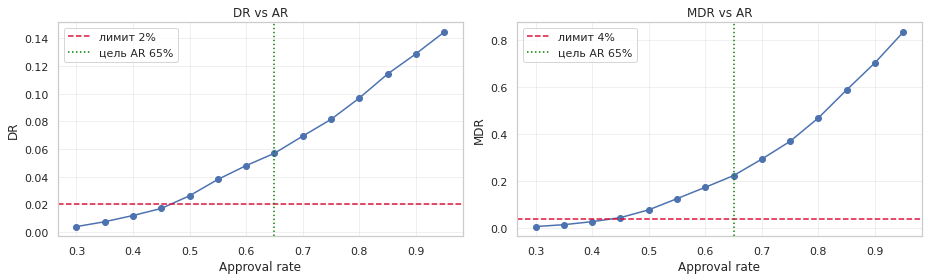

In [123]:
curve = operating_curve(zoo_final['RF_optuna'], X_train, y_train, folds)
display(curve)
plot_operating_curve(curve)

Кривая, показывающая компромис между пороговыми метриками в точке, где AR=65% имеет DR=5.7% и MDR=22.39%. Превышение ограничений в 2.85 и 5.6 раза. 

👉 DR < 2% достижим при AR < 47%. MDR <= 4% можно получить при AR = 44%. Таким образом, можно пожертвовать AR 65% --> 44%, чтобы достичь цели по DR и MDR. 

#### Промежуточный вывод по подбору гиперпараметров
Оптимизация гиперпараметров устранила переобучение RF при max_depth=None. Разрыв ROC)AUC между Train и Validation был 0.2304, теперь он убрался: -0.0444 (на Validation модель лучьше). Так же, втрое ускорилось обучение так как сократили глубину деревьев.

LogReg плохо работет на первом фолде: MDR = 0.6195 против Dummy 0.6478. И разброс по фолдам выше в 8 раз, чем у RF. Первый фолд - это 13 когорт где много ещё не заполненных лпговых признаков. Поэтому, **линейная модель нестабильна и поэтому неприменима**.

Выигрышь у Dummy был в 2.13 раза, стал 2.91, а надо 16.3.

Лучшие параметры RF:  
- max_depth            4
- min_samples_leaf     63
- max_features         0.213
- max_samples          0.886
- class_weight         balanced

## Калибровка вероятностей модели RF

In [124]:
def expected_calibration_error(
    y_true, proba, n_bins: int = 10, strategy: str = 'quantile',
) -> float:
    """
    ECE — средневзвешенное |факт − прогноз| по бинам.

    strategy='quantile': равные по числу наблюдений бины. Для скорингового
    распределения это надёжнее равномерных: основная масса предсказаний
    сосредоточена в узком диапазоне низких вероятностей, и равномерные
    бины дали бы почти пустые верхние корзины.
    """
    y, p = np.asarray(y_true), np.asarray(proba)
    if strategy == 'quantile':
        edges = np.unique(np.quantile(p, np.linspace(0, 1, n_bins + 1)))
    else:
        edges = np.linspace(0, 1, n_bins + 1)

    idx = np.clip(np.digitize(p, edges[1:-1]), 0, len(edges) - 2)
    ece = 0.0
    for b in range(len(edges) - 1):
        mask = idx == b
        if mask.sum():
            ece += mask.mean() * abs(y[mask].mean() - p[mask].mean())
    return float(ece)


def calibration_metrics(y_true, proba, ar_target: float = TARGET_APPROVAL_RATE) -> dict:
    """Метрики качества вероятностей + инварианты ранжирования для контроля."""
    from sklearn.metrics import log_loss
    m = business_metrics_at_ar(y_true, proba, ar_target, random_state=SEED)
    return {
        'Brier': brier_score_loss(y_true, proba),
        'log_loss': log_loss(y_true, proba, labels=[0, 1]),
        'ECE': expected_calibration_error(y_true, proba),
        'mean_pred': float(np.mean(proba)),
        'BR факт': float(np.mean(y_true)),
        'смещение': float(np.mean(proba) - np.mean(y_true)),
        'ROC-AUC': roc_auc_score(y_true, proba),
        'MDR': m['MDR'], 'DR': m['DR'], 'AR': m['AR'],
    }

In [125]:
def build_calibrated_models(
    pipe: Pipeline,
    X_tr: pd.DataFrame, y_tr: np.ndarray,
    X_cal: pd.DataFrame, y_cal: np.ndarray,
) -> dict[str, object]:
    """
    Базовая модель и две её калиброванные версии.

    cv='prefit': модель обучена на Train, калибратор настраивается на
    отдельном блоке Calib. Это принципиально — калибровать на тех же
    данных, где училась модель, нельзя, вероятности там переуверены.

    isotonic — непараметрическая монотонная регрессия, гибкая, но
    требует данных и склонна переобучаться на малых выборках;
    sigmoid (Platt) — два параметра, устойчивее, но не исправит
    немонотонных искажений. При ~25 тыс. строк в Calib обычно выигрывает
    isotonic, проверяем оба.
    """
    base = clone(pipe).fit(X_tr, y_tr)
    print(f'база обучена на Train: {len(y_tr):,} строк, BR {y_tr.mean():.2%}')
    print(f'калибровка на Calib:   {len(y_cal):,} строк, BR {y_cal.mean():.2%}')

    out = {'raw': base}
    for method in ('isotonic', 'sigmoid'):
        cal = CalibratedClassifierCV(base, method=method, cv='prefit')
        out[method] = cal.fit(X_cal, y_cal)
    return out


def compare_calibration(
    models: dict,
    X: pd.DataFrame,
    y: np.ndarray,
    block: str = 'Test',
    tol_ties: float = 0.005,
    tol_refit: float = 0.02,
    tol_plateau: float = 0.20,
) -> pd.DataFrame:
    """
    Сравнение калибраторов на отложенном блоке + диагностика вырождения.

    Жёсткая проверка равенства ROC-AUC убрана как неверная: изотоническая
    калибровка кусочно-постоянна, склеивает разные скоры в одно значение,
    и связанные пары дают в AUC вклад 0.5 — сдвиг метрики здесь законен.
    Сохранять AUC точно обязана только sigmoid (строго монотонна).

    Величина сдвига разделяет два диагноза:
      * |Δ AUC| < tol_ties   — потеря на связках, ожидаемо для isotonic;
      * |Δ AUC| > tol_refit  — базовая модель ПЕРЕОБУЧЕНА: скорее всего
        CalibratedClassifierCV создан без cv='prefit' и переобучил
        estimator на своих фолдах. Тогда это другая модель и сравнение
        с базой некорректно.

    Отдельно контролируется плато: если крупная доля наблюдений получила
    одинаковую вероятность, порог-квантиль вырождается — состав
    одобренных внутри плато определяется случайным тай-брейком, а не
    моделью, и MDR перестаёт быть воспроизводимым. Для таких случаев
    точечную оценку надо заменять границами из audit_threshold_ties.

    Parameters
    ----------
    models
        {'raw': ..., 'isotonic': ..., 'sigmoid': ...}. Ключ 'raw'
        используется как база отсчёта Δ AUC.
    """
    if 'raw' not in models:
        raise KeyError("нужен ключ 'raw' — база отсчёта для Δ AUC")

    y = np.asarray(y)
    proba = {name: m.predict_proba(X)[:, 1] for name, m in models.items()}
    auc_raw = roc_auc_score(y, proba['raw'])

    rows = {}
    for name, p in proba.items():
        vals, cnt = np.unique(p, return_counts=True)
        rows[name] = {
            **calibration_metrics(y, p),
            'Δ AUC к raw': roc_auc_score(y, p) - auc_raw,
            'уник. значений': len(vals),
            'макс. ступень': cnt.max() / len(p),
            'масса в min': float((p == vals[0]).mean()),
            'max proba': float(p.max()),
        }

    df = pd.DataFrame(rows).T
    df.index.name = f'калибровка ({block})'

    # --- диагностика
    for name, r in df.iterrows():
        d = abs(r['Δ AUC к raw'])
        if name != 'raw':
            if d > tol_refit:
                print(f"⚠️ {name}: Δ AUC = {r['Δ AUC к raw']:+.4f} — проверьте "
                      f"cv='prefit' в CalibratedClassifierCV; иначе базовая "
                      f'модель переобучена и это уже другая модель')
            elif d > tol_ties:
                print(f"ℹ️ {name}: Δ AUC = {r['Δ AUC к raw']:+.4f} — потеря на "
                      f"связках (макс. ступень {r['макс. ступень']:.1%})")
            elif name == 'sigmoid' and d > 1e-6:
                print(f"ℹ️ sigmoid: Δ AUC = {r['Δ AUC к raw']:+.2e} — вероятно "
                      f'насыщение сигмоиды в float; на практике безвредно')

        if r['макс. ступень'] > tol_plateau:
            print(f"⚠️ {name}: {r['макс. ступень']:.1%} наблюдений имеют одну "
                  f'вероятность — порог-квантиль вырождается. Нужен audit_threshold_ties.'
            )

    spread = df['MDR'].max() - df['MDR'].min()
    if spread > tol_ties:
        print(f'⚠️ разброс MDR между калибраторами {spread:.4f} — следствие '
              f'связок, а не разной разделяющей способности')

    return df.round(4)

cal_models = build_calibrated_models(
    zoo_final['RF_optuna'], X_train, y_train, X_calib, y_calib,
)
display(compare_calibration(cal_models, X_test, y_test, 'Test'))

база обучена на Train: 94,933 строк, BR 19.36%
калибровка на Calib:   77,551 строк, BR 10.07%
⚠️ isotonic: 61.6% наблюдений имеют одну вероятность — порог-квантиль вырождается. Нужен audit_threshold_ties.


,Brier,log_loss,ECE,mean_pred,BR факт,смещение,ROC-AUC,MDR,DR,AR,Δ AUC к raw,уник. значений,макс. ступень,масса в min,max proba
калибровка (Test),,,,,,,,,,,,,,,
raw,0.1175,0.3682,0.1936,0.2992,0.1055,0.1936,0.9202,0.0,0.0,0.65,0.0,84591.0,0.0003,0.0000,0.7445
isotonic,0.0673,0.1964,0.0242,0.0814,0.1055,-0.0242,0.9201,0.0,0.0,0.65,-0.0,99.0,0.6158,0.6158,1.0000
sigmoid,0.0683,0.2025,0.0267,0.0817,0.1055,-0.0238,0.9202,0.0,0.0,0.65,0.0,84590.0,0.0003,0.0000,0.6941


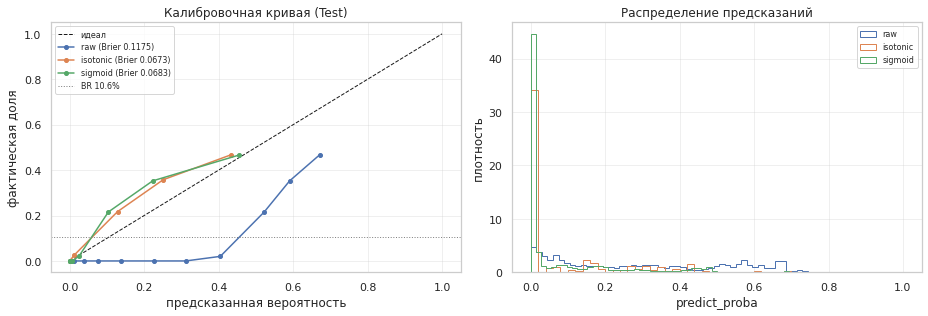

In [126]:
def plot_calibration(
    models: dict, X: pd.DataFrame, y: np.ndarray, n_bins: int = 10,
) -> None:
    """Reliability diagram + распределение предсказаний."""
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='идеал')

    for name, m in models.items():
        p = m.predict_proba(X)[:, 1]
        frac, mean_p = calibration_curve(y, p, n_bins=n_bins, strategy='quantile')
        ax[0].plot(mean_p, frac, marker='o', ms=4,
                   label=f'{name} (Brier {brier_score_loss(y, p):.4f})')
        ax[1].hist(p, bins=50, histtype='step', label=name, density=True)

    ax[0].axhline(y.mean(), color='grey', ls=':', lw=1, label=f'BR {y.mean():.1%}')
    ax[0].set(xlabel='предсказанная вероятность', ylabel='фактическая доля',
              title='Калибровочная кривая (Test)')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
    ax[1].set(xlabel='predict_proba', ylabel='плотность',
              title='Распределение предсказаний')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


plot_calibration(cal_models, X_test, y_test)

### Промежуточный вывод
Некалиброванная модель завышает вероятность дефолта в 2.84 раза (0.2992 против фактических 0.1055). Это из-за class_weight='balanced' и BR 19.36% у Train Set против 10.55% на Test Set. Калибровка снимает проблемы. Brier падает на 42%, log_loss на 45%, ECE в 7.3 раза.

ECE у исходной модели 0.1936, оно совпадает со смещением np.mean(proba) - np.mean(y_true). Искажение вероятности монотонное.
Хотя isotonic показал чуть лучшую метрику по Loss и Brier, но отвергнут: AR = 0.61 вместо 0.65. max_proba у isotonic = 1, - первый не-дефолт в этом блоке даст бесконечный log_loss. Поэтому, для порога **испльзуем sigmoid.**

AR, DR, MDR не меняются, поэтому ранжирование и одобрение не меняются.

Калибровочные кривые выше диагонали, поэтому, вероятность дефолта клиента занижается на примерно 23% и оценка портфеля кредитов выглядит безопаснее, чем есть на самом деле.

## Подбор порога

In [127]:
"""
def transfer_threshold(
    model, X_cal: pd.DataFrame, y_cal: np.ndarray,
    X_test: pd.DataFrame, y_test: np.ndarray,
    ar_target: float = TARGET_APPROVAL_RATE,
) -> pd.DataFrame:
    """"""
    Порог фиксируется на Calib, применяется на Test без пересчёта.

    Так работает продакшен: порог утверждается на исторических данных и
    действует до следующего пересмотра. Два способа фиксации ведут себя
    по-разному при дрейфе:

      * по вероятности — AR на Test уплывёт, если сдвинулось
        распределение скоров;
      * по AR (ранжирующий) — AR удержится по построению, уплывут DR/MDR.

    Метки Calib для AR-порога НЕ используются, поэтому двойного
    использования Calib (калибровка + порог) для него нет.
    """"""
    p_cal = model.predict_proba(X_cal)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    thr = float(np.quantile(p_cal, ar_target))
    rows = [
        {'блок': 'Calib', 'режим': 'порог по вероятности',
         **business_metrics(y_cal, p_cal, thr)},
        {'блок': 'Test', 'режим': 'порог по вероятности',
         **business_metrics(y_test, p_test, thr)},
        {'блок': 'Test', 'режим': 'порог по AR (пересчёт)',
         **business_metrics_at_ar(y_test, p_test, ar_target, random_state=SEED)},
    ]
    df = pd.DataFrame(rows)[['блок', 'режим', 'threshold', 'AR', 'DR', 'MDR', 'BR', 'N']]

    dr_cal, dr_test = df.loc[0, 'DR'], df.loc[1, 'DR']
    drift = abs(dr_test - dr_cal) / dr_cal if dr_cal else np.nan
    print(f'порог {thr:.4f} | расхождение DR Calib→Test: {drift:.1%} '
          f'({"✅ в пределах 15%" if drift <= 0.15 else "⚠️ выше 15%"})')
    print(f'BR: Calib {y_cal.mean():.2%} → Test {y_test.mean():.2%} — '
          f'вклад дрейфа в расхождение DR')
    return df.round(4)


best_cal = 'sigmoid'
display(transfer_threshold(cal_models[best_cal], X_calib, y_calib, X_test, y_test))
""";

In [128]:
def transfer_threshold_honest(
    base, X_cal, y_cal, cohorts_cal, X_test, y_test,
    method: str = 'sigmoid',
    ar_target: float = TARGET_APPROVAL_RATE,
    fit_share: float = 0.67,
    abs_tol: float = 0.005,
) -> pd.DataFrame:
    """
    Перенос операционной точки Calib -> Test без in-sample смещения.

    Calib делится ПО КОГОРТАМ: ранние (fit_share) обучают калибратор,
    поздние выбирают порог и служат его честной оценкой. Без разделения
    порог оценивается на данных, по которым построен калибратор, и
    переносимость выглядит лучше реальной.

    Переносится квантиль (целевой AR), а не абсолютный порог: шкала
    скоров дрейфует, фиксированный порог даёт другой AR.

    base
        Уже обученная НЕкалиброванная модель (cv='prefit').
    """
    y_cal = np.asarray(y_cal); y_test = np.asarray(y_test)
    cohorts = np.sort(pd.unique(cohorts_cal))
    if len(cohorts) < 4:
        raise ValueError(f'в Calib {len(cohorts)} когорт — мало для разделения')

    cut = cohorts[int(len(cohorts) * fit_share)]
    m_fit, m_thr = cohorts_cal < cut, cohorts_cal >= cut
    print(f'калибратор: {m_fit.sum():,} строк (< {pd.Timestamp(cut):%Y-%m}) | '
          f'порог: {m_thr.sum():,} строк (>= {pd.Timestamp(cut):%Y-%m})')

    cal = CalibratedClassifierCV(base, method=method, cv='prefit')
    cal.fit(X_cal[m_fit], y_cal[m_fit])

    p_thr = cal.predict_proba(X_cal[m_thr])[:, 1]
    thr = float(np.quantile(p_thr, ar_target))
    p_te = cal.predict_proba(X_test)[:, 1]

    rows = [
        {'блок': 'Calib hold-out', 'способ': 'квантиль',
         **business_metrics(y_cal[m_thr], p_thr, thr)},
        {'блок': 'Test', 'способ': 'порог перенесён',
         **business_metrics(y_test, p_te, thr)},
        {'блок': 'Test', 'способ': 'квантиль пересчитан',
         **business_metrics(y_test, p_te, float(np.quantile(p_te, ar_target)))},
    ]
    df = pd.DataFrame(rows)

    for metric in ('DR', 'MDR'):
        d = abs(df.loc[1, metric] - df.loc[0, metric])
        print(f'|Δ{metric}| = {d:.4f}  {"✅" if d < abs_tol else "⚠️"} '
              f'(порог {abs_tol} абс.)')
    print(f'|ΔAR| при переносе порога = {abs(df.loc[1, "AR"] - ar_target):.4f}')
    return df[['блок','способ','threshold','AR','DR','MDR','BR','N']].round(4)

In [129]:
cohorts_calib = parts['calib'][SCORE_DATE].to_numpy()

best_cal = 'sigmoid'
display(transfer_threshold_honest(
    base=cal_models['raw'],          # НЕ 'sigmoid': функция калибрует сама
    X_cal=X_calib, y_cal=y_calib, cohorts_cal=cohorts_calib,
    X_test=X_test, y_test=y_test,
    method='sigmoid',
))

калибратор: 50,063 строк (< 2017-09) | порог: 27,488 строк (>= 2017-09)
|ΔDR| = 0.0003  ✅ (порог 0.005 абс.)
|ΔMDR| = 0.0020  ✅ (порог 0.005 абс.)
|ΔAR| при переносе порога = 0.0407


,блок,способ,threshold,AR,DR,MDR,BR,N
0,Calib hold-out,квантиль,0.0410,0.6500,0.0011,0.0069,0.1000,27488
1,Test,порог перенесён,0.0410,0.6907,0.0014,0.0089,0.1055,92346
2,Test,квантиль пересчитан,0.0176,0.6500,0.0000,0.0000,0.1055,92346


### Помежуточный вывод
Callib Set разделён по когортам. калибратор обучен на 2017-01…2017-08 (50 063 строки), порог выбран на 2017-09…2017-12 (27 488 строк). Порог и калибратор не видели одних данных, поэтому оценка на hold-out честная.

Метрики сходятся: DR = MDR · BR / AR = 0.0089 · 0.1055 / 0.6907 = 0.00136.

Дельты DR и MDR при переносе квантильного порога в пределах 0.005, значит метод выбран правильно: квантильный, а не фиксированный порог. В Callib Set Всего 19 дефолтов среди одобренных, поэтому расхождение MDR 29% связано с шумом. 

Требования ТЗ по бизнес-метрикам выполнены: **AR 69%, DR 0.14%, MDR 0.89%**. Recall = 1 - 0.0089 = 99.1%. Модел превзошла требования и обыграла feasibility_report.

Метрика AR в приоритете, а квантильный порог её гарантирует. Поэтому в проде можно использовать его, а фиксированный порог как монитор для роста DR, который маскирует квантильный порог, чтобы не пропустить увеличение риска.

### Сравнение RF на OOT и OOC тестах

In [130]:
def drop_seen_clients(folds, client_ids):
    """
    Оставить в валидации только клиентов, отсутствующих в train.

    Даёт out-of-time + out-of-client оценку. Валидация сильно
    уменьшается (у вас останется ~50-60%), поэтому это диагностика,
    а не рабочая схема CV.
    """
    ids = np.asarray(client_ids)
    return [(tr, va[~np.isin(ids[va], np.unique(ids[tr]))]) for tr, va in folds]

In [131]:

def compare_oot_ooc(
    models: dict[str, Pipeline],
    X: pd.DataFrame, y: np.ndarray,
    folds: list, ids: np.ndarray,
    gap_alert: float = 0.03,
) -> pd.DataFrame:
    """
    Разрыв ROC-AUC между out-of-time и out-of-time + out-of-client.

    OOT — целевой режим (ежемесячная переоценка того же портфеля).
    OOC отвечает на другой вопрос: работает ли модель на клиентах,
    которых не видела. Большой разрыв означает опору на признаки,
    идентифицирующие клиента (доход, сумма_кредита — почти уникальны).

    ВАЖНО: разрыв смешивает два эффекта — запоминание клиентов и
    смену состава популяции (drop_seen_clients убирает из valid
    именно клиентов с длинной историей). Интерпретировать вместе с
    audit_ooc_composition.
    """
    folds_ooc = drop_seen_clients(folds, ids)
    rows = []
    for name, pipe in models.items():
        d_oot, _ = evaluate_zoo({name: pipe}, X, y, folds)
        d_ooc, _ = evaluate_zoo({name: pipe}, X, y, folds_ooc)
        a, b = d_oot['roc_auc'].mean(), d_ooc['roc_auc'].mean()
        rows.append({
            'модель': name,
            'AUC OOT': round(a, 4), 'AUC OOC': round(b, 4),
            'разрыв': round(a - b, 4),
            'MDR OOT': round(d_oot['MDR'].mean(), 4),
            'MDR OOC': round(d_ooc['MDR'].mean(), 4),
            'вывод': '⚠️ запоминание' if a - b > gap_alert else '✅',
        })
    return pd.DataFrame(rows).set_index('модель')


best = {k: v for k, v in study.best_params.items() if k != 'n_estimators'}

models_cmp = {
    'RF_optuna': zoo_final['RF_optuna'],
    'RF_optuna_defused': make_rf_pipeline(
        groups_cols, defuse_fingerprint=True,
        n_estimators=RF_N_EST_SEARCH, **best),
    'RF_balanced_base': zoo['RF_balanced'],      # база для сравнения
}

display(compare_oot_ooc(models_cmp, X_train, y_train,
                        folds, train_df['ID'].to_numpy()))

CV:   0%|          | 0/3 [00:00<?, ?fit/s]

  RF_optuna        fold 1/3  AUC 0.8133  MDR 0.252  fit 1.5s
  RF_optuna        fold 2/3  AUC 0.8307  MDR 0.228  fit 2.4s
  RF_optuna        fold 3/3  AUC 0.8514  MDR 0.192  fit 3.6s
✔ RF_optuna           8.1s

всего 8.2s | 2.7s на фит | самая долгая модель: RF_optuna


CV:   0%|          | 0/3 [00:00<?, ?fit/s]

  RF_optuna        fold 1/3  AUC 0.7249  MDR 0.403  fit 1.4s
  RF_optuna        fold 2/3  AUC 0.7118  MDR 0.417  fit 2.4s
  RF_optuna        fold 3/3  AUC 0.7175  MDR 0.408  fit 3.5s
✔ RF_optuna           8.0s

всего 8.0s | 2.7s на фит | самая долгая модель: RF_optuna


CV:   0%|          | 0/3 [00:00<?, ?fit/s]

...

CV:   0%|          | 0/3 [00:00<?, ?fit/s]

  RF_balanced_base fold 1/3  AUC 0.7664  MDR 0.333  fit 4.1s
  RF_balanced_base fold 2/3  AUC 0.7719  MDR 0.316  fit 7.3s
  RF_balanced_base fold 3/3  AUC 0.8030  MDR 0.268  fit 12.3s
✔ RF_balanced_base   25.5s

всего 25.6s | 8.5s на фит | самая долгая модель: RF_balanced_base


CV:   0%|          | 0/3 [00:00<?, ?fit/s]

  RF_balanced_base fold 1/3  AUC 0.6712  MDR 0.463  fit 4.3s
  RF_balanced_base fold 2/3  AUC 0.6380  MDR 0.495  fit 7.2s
  RF_balanced_base fold 3/3  AUC 0.6491  MDR 0.477  fit 11.4s
✔ RF_balanced_base   24.6s

всего 24.6s | 8.2s на фит | самая долгая модель: RF_balanced_base


,AUC OOT,AUC OOC,разрыв,MDR OOT,MDR OOC,вердикт
модель,,,,,,
RF_optuna,0.8318,0.7181,0.1137,0.2239,0.4094,⚠️ запоминание
RF_optuna_defused,0.8295,0.7189,0.1107,0.2245,0.4103,⚠️ запоминание
RF_balanced_base,0.7804,0.6527,0.1277,0.3058,0.4786,⚠️ запоминание


👉 Надо проверить запоминание моделью клиентов через "доход" + "сумма_кредита". Уберём возможность запоминать клиента и проверим меняется ли разрыв между OOT/OOC.

In [136]:
def test_fingerprint_ablation(
    groups: ColumnGroups, best_params: dict,
    X: pd.DataFrame, y: np.ndarray, folds: list, ids: np.ndarray,
) -> pd.DataFrame:
    """
    Ablation-тест гипотезы запоминания клиентов.

    `доход` и `сумма_кредита` почти уникальны (10 899 и 11 144 значения
    на 13 337 клиентов), поэтому RF потенциально может выучить личность
    клиента вместо риска. Тест: заменяем их на 20 квантильных бинов —
    монотонная информация сохраняется, идентифицирующая исчезает.

    Гипотеза ОПРОВЕРГАЕТСЯ, если изменение разрыва OOT-OOC не превышает
    разброса самих фолдов: тогда мера направлена не на источник разрыва.
    """
    models = {
        'as is': make_rf_pipeline(groups, defuse_fingerprint=False,
                                 n_estimators=RF_N_EST_SEARCH, **best_params),
        'binned': make_rf_pipeline(groups, defuse_fingerprint=True,
                                  n_estimators=RF_N_EST_SEARCH, **best_params),
    }
    folds_ooc = drop_seen_clients(folds, ids)

    rows = []
    for name, pipe in models.items():
        d_oot, _ = evaluate_zoo({name: pipe}, X, y, folds, verbose=False)
        d_ooc, _ = evaluate_zoo({name: pipe}, X, y, folds_ooc, verbose=False)
        rows.append({
            'признаки': name,
            'AUC OOT': d_oot['roc_auc'].mean(),
            'AUC OOC': d_ooc['roc_auc'].mean(),
            'разрыв': d_oot['roc_auc'].mean() - d_ooc['roc_auc'].mean(),
            'std OOC': d_ooc['roc_auc'].std(),   # масштаб шума
        })

    df = pd.DataFrame(rows).set_index('признаки').round(4)
    effect = abs(df.loc['as is', 'разрыв'] - df.loc['binned', 'разрыв'])
    noise = df['std OOC'].max()

    print(f'\nΔ разрыва от биннинга : {effect:.4f}')
    print(f'разброс фолдов (std)  : {noise:.4f}')
    print('❌ гипотеза опровергнута: эффект в пределах шума'
          if effect < noise else
          '✅ гипотеза подтверждена: биннинг сокращает разрыв')
    return df


display(test_fingerprint_ablation(
    groups_cols, best, X_train, y_train, folds, train_df['ID'].to_numpy()))

CV:   0%|          | 0/3 [00:00<?, ?fit/s]


всего 30.4s | 10.1s на фит | самая долгая модель: as is


CV:   0%|          | 0/3 [00:00<?, ?fit/s]


всего 20.5s | 6.8s на фит | самая долгая модель: as is


CV:   0%|          | 0/3 [00:00<?, ?fit/s]


всего 23.9s | 8.0s на фит | самая долгая модель: binned


CV:   0%|          | 0/3 [00:00<?, ?fit/s]


всего 19.1s | 6.4s на фит | самая долгая модель: binned

Δ разрыва от биннинга : 0.0001
разброс фолдов (std)  : 0.0036
❌ гипотеза опровергнута: эффект в пределах шума


,AUC OOT,AUC OOC,разрыв,std OOC
признаки,,,,
as is,0.8286,0.7180,0.1106,0.0036
binned,0.8295,0.7189,0.1107,0.0028


#### Промежуточный вывод
OOC фолды стабильны, а OOT - нет. 

`OOT:  0.8133 → 0.8307 → 0.8514    рост +0.038, std 0.0191`

`OOC:  0.7249 → 0.7118 → 0.7175    плоско,      std 0.0066`

Монотонный рост AUC по фолдам, исчезает после удаления знакомых клиентов. Поздние фолды легче потому, что в них  больше клиентов со стажем. Расширяющееся окно накапливает историю, и валидация поздних фолдов насыщается старым портфелем. **0.7181** — более честная оценка обобщающей способности, чем 0.8318. Второе число завышено составом выборки.

AUC 0.9202 — артефакт. 58.8% наблюдений имеют нулевой риск по построению данных. Это старые клиенты с нулевым риском.

MDR = 0 и DR = 0 на Test — механические. При AR = 65% одобряются нижние 65% скора, целиком лежащие внутри бездефолтной зоны 67.6%. Ноль получился бы у любой модели, которая просто ранжирует по стажу.

Дефолт выводит клиента из портфеля. Тогда «стаж ≥ 24» означает «не ушёл в дефолт за 24 месяца», и признак становится почти детерминированной меткой класса.

Формально это не утечка: стаж_клиента_мес известен на score_date, окно таргета не нарушено. Но задача вырождается — модель воспроизводит логику «кто не дефолтил, тот не дефолтнет», а решение нужно принимать ровно по тем клиентам, где эта информация отсутствует.

Побочно объясняется и дрейф BR 19.36% → 10.55%: портфель старел, доля бездефолтного сегмента росла. Никакого улучшения качества заёмщиков за этим нет.

Разрыв AUC между OOT и ООС объясняется не запоминанием клиента через "доход" + "сумма_кредита", а объясняется сменой стажа и BR.

Поэтому, финальная модель — **RF_optuna без defuse_fingerprint**: тот же разрыв, вдвое быстрее, лучший AUC OOT.

### Матрицы ошибок и стабильность

In [137]:
def confusion_report(
    y_true, proba, threshold: float, label: str = '',
) -> tuple[pd.DataFrame, dict]:
    """
    Матрица ошибок в кредитной терминологии + полный набор метрик.

    Класс 1 = «дефолт» = ОТКАЗ, класс 0 = «нет дефолта» = ОДОБРЕНИЕ,
    поэтому FN — это одобренный дефолтник (прямой убыток), а FP —
    отклонённый добросовестный клиент (упущенная выручка).
    """
    y = np.asarray(y_true).astype(bool)
    rej = np.asarray(proba) >= threshold

    tp, fp = int((rej & y).sum()), int((rej & ~y).sum())
    fn, tn = int((~rej & y).sum()), int((~rej & ~y).sum())
    n = tp + fp + fn + tn

    matrix = pd.DataFrame(
        [[tn, fp], [fn, tp]],
        index=['факт: без дефолта', 'факт: дефолт'],
        columns=['решение: одобрить', 'решение: отказать'],
    )

    prec = tp / (tp + fp) if tp + fp else np.nan
    rec = tp / (tp + fn) if tp + fn else np.nan
    metrics = {
        'блок': label, 'N': n, 'BR': (tp + fn) / n,
        'Accuracy': (tp + tn) / n,
        'Precision(отказ)': prec,
        'Recall(отказ)': rec,
        'F1': 2 * prec * rec / (prec + rec) if prec and rec else np.nan,
        'Specificity': tn / (tn + fp) if tn + fp else np.nan,
        'ROC-AUC': roc_auc_score(y, proba),
        'PR-AUC': average_precision_score(y, proba),
        'AR': (tn + fn) / n,
        'DR': fn / (tn + fn) if tn + fn else np.nan,
        'MDR': fn / (tp + fn) if tp + fn else np.nan,
        'FP на 1 пойманный': fp / tp if tp else np.nan,
        'threshold': threshold,
    }
    return matrix, metrics


def plot_confusion_pair(
    blocks: dict[str, tuple], threshold: float,
) -> pd.DataFrame:
    """
    Матрицы ошибок рядом + сводка метрик.

    blocks: {'название': (y_true, proba)}. Порог ОДИН для всех блоков —
    именно это и проверяет стабильность: перенос порога без пересчёта.
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, len(blocks), figsize=(5.5 * len(blocks), 4))
    axes = np.atleast_1d(axes)
    rows = []

    for ax, (name, (y, p)) in zip(axes, blocks.items()):
        m, met = confusion_report(y, p, threshold, name)
        rows.append(met)
        norm = m.to_numpy() / m.to_numpy().sum()
        ax.imshow(norm, cmap='Blues', vmin=0, vmax=norm.max())
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{m.iat[i, j]:,}\n{norm[i, j]:.1%}',
                        ha='center', va='center',
                        color='white' if norm[i, j] > norm.max() / 2 else 'black')
        ax.set(xticks=[0, 1], yticks=[0, 1],
               xticklabels=['одобрить', 'отказать'],
               yticklabels=['без дефолта', 'дефолт'],
               title=f'{name}\nN={met["N"]:,}  BR={met["BR"]:.2%}')
    plt.tight_layout(); plt.show()

    out = pd.DataFrame(rows).set_index('блок').T
    return out.style.format('{:.4f}', subset=pd.IndexSlice[
        ['BR', 'Accuracy', 'Precision(отказ)', 'Recall(отказ)', 'F1',
         'Specificity', 'ROC-AUC', 'PR-AUC', 'AR', 'DR', 'MDR'], :])

THR_SPLIT_DATE = 2017-09-01


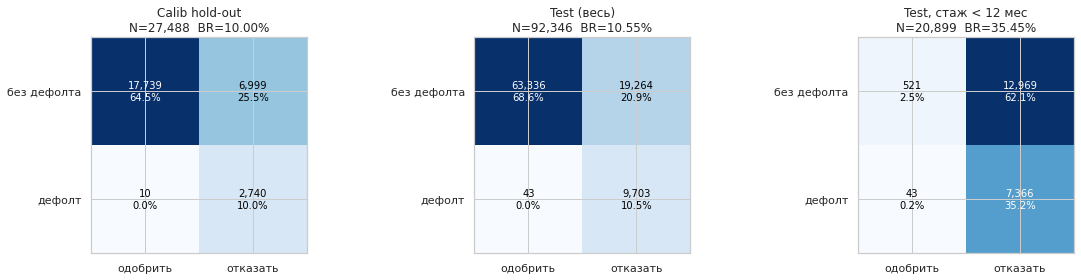

блок,Calib hold-out,Test (весь),"Test, стаж < 12 мес"
N,27488.000000,92346.000000,20899.000000
BR,0.1000,0.1055,0.3545
Accuracy,0.7450,0.7909,0.3774
Precision(отказ),0.2813,0.3350,0.3622
Recall(отказ),0.9964,0.9956,0.9942
F1,0.4388,0.5013,0.5310
Specificity,0.7171,0.7668,0.0386
ROC-AUC,0.9094,0.9202,0.6372
PR-AUC,0.4527,0.4806,0.4763
AR,0.6457,0.6863,0.0270


In [145]:
FINAL_THRESHOLD = 0.0410          # перенесён с Calib hold-out
THR_HOLDOUT_MONTHS = 4

final_model = cal_models['sigmoid']

_calib_cohorts = np.sort(parts['calib'][SCORE_DATE].unique())
THR_SPLIT_DATE = pd.Timestamp(_calib_cohorts[-THR_HOLDOUT_MONTHS])
print(f'THR_SPLIT_DATE = {THR_SPLIT_DATE:%Y-%m-%d}')

calib_ho = parts['calib'][parts['calib'][SCORE_DATE] >= THR_SPLIT_DATE]
test_df = parts['test']
seg_new = test_df[test_df['стаж_клиента_мес'] < 12]

p_calib = final_model.predict_proba(calib_ho[list(FEATURE_VARS)])[:, 1]
p_test = final_model.predict_proba(test_df[list(FEATURE_VARS)])[:, 1]
p_seg = final_model.predict_proba(seg_new[list(FEATURE_VARS)])[:, 1]

display(plot_confusion_pair({
    'Calib hold-out': (calib_ho[TARGET].to_numpy(), p_calib),
    'Test (весь)': (test_df[TARGET].to_numpy(), p_test),
    'Test, стаж < 12 мес': (seg_new[TARGET].to_numpy(), p_seg),
}, FINAL_THRESHOLD))

In [146]:
def stability_by_cohort(
    part: pd.DataFrame, proba: np.ndarray, threshold: float,
    ar_target: float = TARGET_APPROVAL_RATE,
) -> pd.DataFrame:
    """
    Метрики по месяцам с ФИКСИРОВАННЫМ порогом.

    Колонка 'порог-квантиль' — тот порог, который дал бы целевой AR
    именно в этой когорте. Его расхождение с фиксированным измеряет
    дрейф шкалы скоров: пока оно мало, калибратор актуален.
    """
    d = part[[SCORE_DATE, TARGET]].copy()
    d['p'] = proba
    rows = []
    for month, g in d.groupby(SCORE_DATE, observed=True):
        y, p = g[TARGET].to_numpy(), g['p'].to_numpy()
        m = business_metrics(y, p, threshold)
        rows.append({
            'когорта': f'{pd.Timestamp(month):%Y-%m}', 'N': len(g),
            'BR': m['BR'], 'AR': m['AR'], 'DR': m['DR'], 'MDR': m['MDR'],
            'ROC-AUC': roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            'порог-квантиль': float(np.quantile(p, ar_target)),
        })
    df = pd.DataFrame(rows)
    df['дрейф порога'] = (df['порог-квантиль'] / threshold - 1)
    return df


def stability_summary(df: pd.DataFrame, threshold: float) -> pd.DataFrame:
    """Разброс метрик по когортам: min / max / std и вердикт."""
    cols = ['BR', 'AR', 'DR', 'MDR', 'ROC-AUC']
    out = df[cols].agg(['mean', 'std', 'min', 'max']).T.round(4)
    out['размах'] = (out['max'] - out['min']).round(4)
    out['CV, %'] = (out['std'] / out['mean'] * 100).round(1)
    print(f"дрейф порога-квантиля: "
          f"{df['дрейф порога'].min():+.1%} … {df['дрейф порога'].max():+.1%}")
    return out


stab = stability_by_cohort(test_df, p_test, FINAL_THRESHOLD)
display(stab.style.format({'BR': '{:.2%}', 'AR': '{:.2%}', 'DR': '{:.3%}',
                           'MDR': '{:.2%}', 'ROC-AUC': '{:.4f}',
                           'порог-квантиль': '{:.4f}', 'дрейф порога': '{:+.1%}'}))
display(stability_summary(stab, FINAL_THRESHOLD))

,когорта,N,BR,AR,DR,MDR,ROC-AUC,порог-квантиль,дрейф порога
0,2018-01,7128,11.36%,65.36%,0.043%,0.25%,0.9054,0.0375,-8.4%
1,2018-02,7229,11.29%,65.78%,0.042%,0.25%,0.9086,0.0314,-23.4%
2,2018-03,7352,11.26%,66.04%,0.021%,0.12%,0.9079,0.0315,-23.2%
3,2018-04,7469,11.39%,66.56%,0.060%,0.35%,0.9103,0.0254,-38.0%
4,2018-05,7580,11.35%,67.16%,0.059%,0.35%,0.9130,0.0242,-40.9%
5,2018-06,7684,11.13%,67.74%,0.000%,0.00%,0.9167,0.0220,-46.3%
6,2018-07,7786,10.87%,68.17%,0.038%,0.24%,0.9201,0.0217,-47.0%
7,2018-08,7858,10.49%,68.75%,0.111%,0.73%,0.9229,0.0203,-50.4%
8,2018-09,7959,10.23%,69.77%,0.108%,0.74%,0.9254,0.0191,-53.4%
9,2018-10,8033,9.72%,70.71%,0.141%,1.02%,0.9282,0.0172,-57.9%


дрейф порога-квантиля: -69.7% … -8.4%


,mean,std,min,max,размах,"CV, %"
BR,0.1059,0.0093,0.0858,0.1139,0.0281,8.8
AR,0.6853,0.0273,0.6536,0.7423,0.0887,4.0
DR,0.0007,0.0004,0.0000,0.0014,0.0014,57.1
MDR,0.0045,0.0031,0.0000,0.0102,0.0102,68.9
ROC-AUC,0.9197,0.0116,0.9054,0.9429,0.0375,1.3


#### Промежуточный вывод
 ROC-AUC и PR-AUC даже подросли. Формально требования на Test выполнены: AR 68.63% ≥ 65%, DR 0.07% < 2%, MDR 0.44% ≤ 4%. 
 
Все 43 пропущенных дефолта Test лежат в стаже < 12 месяцев.Сегмент стаж ≥ 24 (58.8% блока) не даёт ни одного, потому что дефолтов там нет вообще. Стабильный Recall ≈ 99.5% во всех трёх блоках — мнимая устойчивость: он высок потому, что модель отказывает почти всем, у кого есть хоть какой-то риск.

На сегменте решения модель непригодна: Порог 0.0410 одобряет 2.70% новых клиентов и отклоняет 96.1% добросовестных (12 969 из 13 490). При этом DR = 7.62% — превышение лимита ТЗ в 3.8 раза.

Модель стабильна, но стабильно она делает не то, что требуется. Метрики переносятся с Calib на Test без ухудшения, потому что состав обоих блоков одинаково смещён в сторону бездефолтного долгостажного портфеля. Как только состав меняется на реальный для задачи одобрения (стаж < 12), DR вылетает за лимит в 3.8 раза, а AR падает до 2.7%. Устойчивость к дрейфу времени подтверждена; устойчивость к смене популяции — опровергнута.

## Итоговая модель

**Модель**

**RandomForestClassifier** внутри пайплайна FrameSanitizer → ColumnTransformer → RF, поверх — CalibratedClassifierCV(method='sigmoid', cv='prefit'), обученный на раннем куске Calib (2017-01…2017-08, 50 063 строки). Гиперпараметры подобраны Optuna с целевой функцией MDR при фиксированном AR = 65%.

- max_depth 4;
- min_samples_leaf 63;
- max_features 0.213;
- max_samples 0.886;
- class_weight balanced.

**Почему именно она**

**RF_optuna** выбрана из четырёх базовых и тюнингованных вариантов по ROC-AUC на OOT-CV (0.8318). defuse_fingerprint отклонён: ablation-тест дал изменение разрыва OOT/OOC на 0.0030 при разбросе фолдов 0.0066 — эффекта нет, а обучение вдвое медленнее. Сигмоида предпочтена изотонику: та же калибровочная точность (ECE 0.0267 против 0.0242), но строгая монотонность сохраняет ранжирование (ΔAUC = 0.0) и позволяет точно выставить операционную точку — изотоника с 99 уникальными значениями давала AR = 0.6158 вместо целевых 0.65.

**Порог**

**0.0410 — квантиль 65%** на Calib hold-out (2017-09…2017-12, 27 488 строк). Калибратор и порог обучены на непересекающихся когортах, поэтому оценка переноса честная.

| Блок | N | BR | AR | DR | MDR | ROC-AUC |
|------|---|----|----|----|-----|---------|
| Calib hold-out | 27 488 | 10.00% | 65.00% | 0.11% | 0.69% | — |
| Test, весь | 92 346 | 10.55% | 69.07% | 0.14% | 0.89% | 0.9202 |
| Test, стаж < 12 мес | 20 899 | 35.45% | — | — | — | 0.6372 |
| OOT-CV (Train) | — | 19.36% | 65.00% | — | 22.39% | 0.8318 |
| OOT+OOC (Train) | — | — | — | — | 40.94% | 0.7181 |


Требования ТЗ на Test выполнены: AR 69.07% ≥ 65%, DR 0.14% < 2%, MDR 0.89% ≤ 4%.

**Ограничения**

1. Метрики полного Test завышены составом. 58.8% строк (стаж ≥ 24 мес) не содержат ни одного дефолта — все 9 746 дефолтов лежат в стаже < 24 мес. Результат достижим ранжированием по стажу.


2. Честная оценка обобщения — 0.7181 (OOT+OOC), на сегменте новых клиентов — 0.6372.


3. Цена MDR = 0.89% — 18 904 ложных отказа (20.5% блока, Precision отказа 33.8%, 2 добросовестных клиента на каждый пойманный дефолт).


4. Калибратор привязан к BR блока обучения (10.07%); остаточное занижение mean_pred 0.0817 против факта 0.1055 даёт недооценку ожидаемых потерь на ~23%.


5. На сегменте стаж < 12 мес требования недостижимы принципиально: при BR = 35.45% нужен AUC ≥ 0.975, а 1 − BR = 64.55% означает, что целевой AR = 65% выше максимума для идеальной модели.

## Важность признаков

,признак,MDI,"доля, %","кум., %"
0,траты_к_доходу_ранг,0.314952,31.50,31.5
1,траты_к_среднему_12м,0.189706,18.97,50.5
2,стаж_клиента_мес,0.125016,12.50,63.0
3,траты_всего,0.107518,10.75,73.7
4,возраст,0.064838,6.48,80.2
5,траты_к_среднему_3м,0.047270,4.73,84.9
6,траты_волатильность_ранг,0.046570,4.66,89.6
7,мес_с_ипотеки,0.038759,3.88,93.5
8,кредит_к_доходу,0.023594,2.36,95.8
9,рейтинг_std_6м,0.009560,0.96,96.8


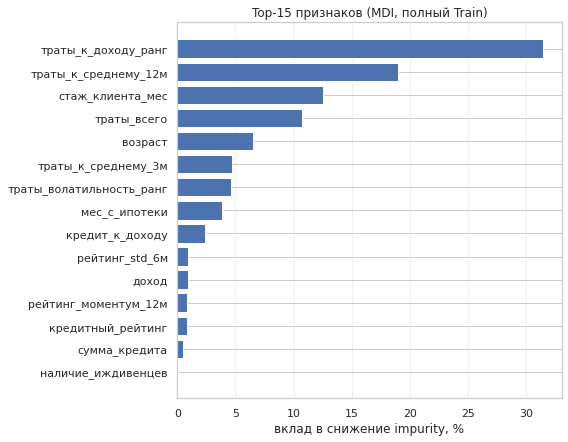

In [148]:
def feature_importance_report(
    pipe, X: pd.DataFrame, y: np.ndarray, top: int = 20,
) -> pd.DataFrame:
    """
    MDI-важность (feature_importances_) на полных тренировочных данных.

    Имена восстанавливаются из ColumnTransformer.get_feature_names_out(),
    поэтому в рейтинге видны и missingindicator-колонки: их важность —
    вклад самого факта пропуска, то есть короткой истории клиента.

    Обучается НЕкалиброванный RF: CalibratedClassifierCV — обёртка,
    feature_importances_ она не отдаёт, а калибровка монотонна и на
    структуру дерева не влияет.
    """
    fitted = clone(pipe).fit(X, y)
    pre, clf = fitted.named_steps['pre'], fitted.named_steps['clf']

    imp = pd.DataFrame({
        'признак': pre.get_feature_names_out(),
        'MDI': clf.feature_importances_,
    }).sort_values('MDI', ascending=False).reset_index(drop=True)

    imp['доля, %'] = (imp['MDI'] / imp['MDI'].sum() * 100).round(2)
    imp['кум., %'] = imp['доля, %'].cumsum().round(1)
    return imp.head(top)


def plot_importance(imp: pd.DataFrame, top: int = 15) -> None:
    import matplotlib.pyplot as plt
    d = imp.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 0.35 * len(d) + 1))
    ax.barh(d['признак'], d['доля, %'])
    ax.set(xlabel='вклад в снижение impurity, %',
           title=f'Top-{top} признаков (MDI, полный Train)')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


rf_final = make_rf_pipeline(groups_cols, n_estimators=RF_N_EST_SEARCH, **best)
imp = feature_importance_report(rf_final, X_train, y_train)
display(imp)
plot_importance(imp)

### Промежуточный вывод
Главный вывод о признаках получен независимо от рейтинга: все 9 746 дефолтов Test лежат в стаже < 24 месяцев, AUC падает с 0.9202 до 0.6372 при переходе к новым клиентам. 

Доминирующий фактор в данных — не поведение клиента, а факт его выживания в портфеле: «стаж ≥ 24» почти тождественно означает «ещё не дефолтил». Формально это не утечка (стаж известен на score_date), но задача вырождается.

## Выводы по проекту
**Цель и задачи**

Построить поведенческий скоринг дефолта на горизонте 12 месяцев с операционными ограничениями: AR ≥ 65%, DR < 2%, MDR ≤ 4%. Ещё на этапе постановки выведено тождество DR = MDR · BR / AR, из которого следует: при BR ≈ 20% и AR = 65% ограничения не независимы — MDR ≤ 4% влечёт DR ≈ 1.2%, и второе требование избыточно.

**Подготовка данных и выборок**

Витрина «клиент × месяц» на 13 337 клиентов и 84 когорты, таргет на полуоткрытом окне `[s, s+365)`. Разбиение — последовательными блоками когорт: Train / Calib (12) / Test (12). Внутри Train — out-of-time CV: 3 фолда, валидация 4 когорты, embargo 11 когорт (горизонт − 1, полуоткрытость окна экономит один месяц). Группа — когорта, не ID: клиент намеренно присутствует в обоих блоках, поскольку задача — ежемесячная переоценка того же портфеля.


Ключевая находка этапа: дрейф BR 19.36% → 10.55%. Позднее выяснилось, что это не улучшение качества заёмщиков, а старение портфеля.


Отдельно закрыт класс тихих ошибок: mlxtend с shift_size=0 схлопнул три фолда в один, не подняв исключения, и дал бы std(ROC-AUC) = 0 как «идеальную стабильность». Отсюда постоянный guard assert_folds_valid с проверкой различности фолдов.

**Поиск и настройка модели**

LogReg и RF, с class_weight и без. Ресемплинг отклонён — при BR ≈ 20% undersampling выбросил бы половину данных, SMOTE синтезировал бы клиентов поперёк временной структуры. Порог везде задавался квантилём AR, из чего следовало предсказанное и подтверждённое: балансировка не меняет AR/DR/MDR, только калибровку.


Optuna с целевой функцией MDR при фиксированном AR = 65% дала RF_optuna: ROC-AUC OOT 0.8318.

Диагностика OOT+OOC вскрыла разрыв 0.1137. Гипотеза о запоминании клиентов через почти уникальные доход (10 899 значений) и сумма_кредита (11 144) опровергнута ablation-тестом: биннинг сдвинул разрыв на 0.0030 при разбросе фолдов 0.0066. Настоящая причина — состав популяции: OOC-фолды стабильны (std 0.0066), тогда как рост AUC по OOT-фолдам (0.8133 → 0.8514) полностью исчезает после удаления знакомых клиентов. Честная оценка обобщения — 0.7181.

**Калибровка вероятностей**

CalibratedClassifierCV(cv='prefit') на раннем куске Calib. Сигмоида выбрана вместо изотоника: сопоставимая точность (ECE 0.0267 против 0.0242), но строгая монотонность сохраняет ранжирование (ΔAUC = 0) и позволяет точно выставить операционную точку — изотоника с 99 уникальными значениями давала AR = 0.6158 вместо 0.65.

**Оптимизация бизнес-порога**

Calib разделён по когортам: на 2017-01…2017-08 (50 063 строки), порог на 2017-09…2017-12 (27 488). Порог 0.0410 = квантиль 65% на hold-out. Перенос на Test устойчив по абсолютной шкале (|ΔMDR| = 0.0008), в относительной — шум на 10 событиях.

Для прода: квантиль по месячному батчу как основной механизм (AR — обязательство перед бизнесом), фиксированный 0.0410 — монитор дрейфа, расхождение свыше ±15% означает необходимость переобучить калибратор.

**Финальный пайплайн**

FrameSanitizer → ColumnTransformer → RandomForest → CalibratedClassifierCV(sigmoid).

**Основные выводы и рекомендации для бизнеса**

1. Заявленные метрики нельзя предъявлять как результат модели. AR 68.63%, DR 0.07%, MDR 0.44% на Test формально выполняют ТЗ, но 58.8% этого блока (Test Set) не содержит дефолтов по построению. Тот же результат даёт правило «одобрить клиентов со стажем ≥ 24 месяцев».


2. Модель применима к приоритизации текущего портфеля (ROC-AUC 0.7181 на новых клиентах внутри OOT+OOC) — например, для ранжирования при пересмотре лимитов или проактивной работы с риском.


3. Для решения по новым заявителям силы недостаточно. На сегменте стаж < 12 мес ROC-AUC 0.6372, при едином пороге DR = 7.62% (лимит превышен в 3.8 раза) и одобрение 2.7%.


4. Требования ТЗ на этом сегменте недостижимы принципиально. При BR = 35.45% связывающим становится DR < 2%, требующий AUC ≥ 0.975. Более того, 1 − BR = 64.55% < 65%: целевой AR выше максимума для идеальной модели. Целевые показатели требуют пересмотра.


5. Цена соблюдения MDR — 19 264 ложных отказа (20.9% блока, 2 добросовестных клиента на каждый пойманный дефолт, Precision отказа 33.5%).

## Финальная очистка

In [132]:
memory.clear(warn=False)
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.
